# Exploration des données foudre — Meteorage
Analyse du fichier `segment_alerts_all_airports_train.csv`

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Import des données

In [3]:
FILE_PATH = "segment_alerts_all_airports_train.csv"

df = pd.read_csv(FILE_PATH)
print("Fichier chargé avec succès")

Fichier chargé avec succès


## 2. Aperçu général

In [4]:
print(f"Nombre de lignes    : {len(df):,}")
print(f"Nombre de colonnes  : {df.shape[1]}")
print(f"\nColonnes : {list(df.columns)}")

Nombre de lignes    : 507,071
Nombre de colonnes  : 13

Colonnes : ['lightning_id', 'lightning_airport_id', 'date', 'lon', 'lat', 'amplitude', 'maxis', 'icloud', 'dist', 'azimuth', 'airport', 'airport_alert_id', 'is_last_lightning_cloud_ground']


In [5]:
# type des colonnes

df.dtypes

lightning_id                        int64
lightning_airport_id                int64
date                               object
lon                               float64
lat                               float64
amplitude                         float64
maxis                             float64
icloud                               bool
dist                              float64
azimuth                           float64
airport                            object
airport_alert_id                  float64
is_last_lightning_cloud_ground     object
dtype: object

In [6]:
# conversion de "date" en type "datetime"
df['date'] = pd.to_datetime(df['date'], utc=True)

In [7]:
# les 5 premières valeurs

df.head()

,lightning_id,lightning_airport_id,date,lon,lat,amplitude,maxis,icloud,dist,azimuth,airport,airport_alert_id,is_last_lightning_cloud_ground
0,1,1,2016-01-02 14:53:36+00:00,9.0559,42.0826,-9.90,0.3,False,27.360653,57.852343,Ajaccio,NaN,NaN
1,2,2,2016-01-02 14:53:36+00:00,9.0236,42.0953,-3.33,0.2,True,26.383167,52.117828,Ajaccio,NaN,NaN
2,3,3,2016-01-02 21:22:53+00:00,8.8585,42.0456,-18.68,0.4,True,14.313391,24.500543,Ajaccio,NaN,NaN
3,4,4,2016-01-02 21:22:53+00:00,8.8517,42.0517,-7.51,0.2,False,14.794117,20.854458,Ajaccio,1.0,False
4,5,5,2016-01-02 21:24:46+00:00,8.8728,42.0494,-6.01,0.2,False,15.124224,29.058471,Ajaccio,1.0,False


## 3. Valeurs manquantes

In [8]:
missing = pd.DataFrame({
    'nb_manquants': df.isnull().sum(),
    'pct_manquants (%)': (df.isnull().sum() / len(df) * 100).round(2)
})

missing = missing.sort_values('pct_manquants (%)', ascending=False)
print(missing.to_string())

                                nb_manquants  pct_manquants (%)
airport_alert_id                      450472              88.84
is_last_lightning_cloud_ground        450472              88.84
date                                       0               0.00
lightning_airport_id                       0               0.00
lightning_id                               0               0.00
lat                                        0               0.00
lon                                        0               0.00
amplitude                                  0               0.00
maxis                                      0               0.00
dist                                       0               0.00
icloud                                     0               0.00
airport                                    0               0.00
azimuth                                    0               0.00


## 4. Statistiques descriptives

In [9]:
df.describe(include='all')

,lightning_id,lightning_airport_id,date,lon,lat,amplitude,maxis,icloud,dist,azimuth,airport,airport_alert_id,is_last_lightning_cloud_ground
count,507071.000000,507071.000000,507071,507071.000000,507071.000000,507071.000000,507071.000000,507071,507071.000000,507071.000000,507071,56599.000000,56599
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,5,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,Pise,NaN,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,378079,NaN,NaN,156718,NaN,53972
mean,319152.873651,59451.210188,2019-03-27 03:35:05.546737920+00:00,6.385887,43.345451,-2.254868,1.025518,NaN,20.243757,168.806028,NaN,316.932720,NaN
min,1.000000,1.000000,2016-01-02 01:10:41+00:00,-2.006800,41.654300,-429.500000,0.016000,NaN,0.037212,0.000000,NaN,1.000000,NaN
25%,148099.500000,25354.000000,2017-06-28 16:02:00+00:00,-1.295800,42.471800,-5.610000,0.107000,NaN,15.412370,85.240722,NaN,170.000000,NaN
50%,317158.000000,54199.000000,2018-08-22 13:07:13+00:00,9.339100,43.445100,-1.560000,0.245000,NaN,21.442300,156.717299,NaN,282.000000,NaN
75%,501958.500000,90354.000000,2020-09-20 05:30:42+00:00,10.220500,43.666200,4.620000,1.538000,NaN,26.112228,251.482192,NaN,446.000000,NaN
max,628726.000000,156718.000000,2022-12-21 11:20:11+00:00,10.771700,47.422600,497.000000,6.900000,NaN,29.999996,359.978549,NaN,769.000000,NaN


In [28]:
# nombre d'éclairs en terme de distance

bins = [0, 20, 30, float('inf')]
labels = ['< 20 km', '20-30 km', '> 30 km']

dist_cat = pd.cut(df['dist'], bins=bins, labels=labels)

result = dist_cat.value_counts().sort_index().to_frame(name='nb_eclairs')
result['pct (%)'] = (result['nb_eclairs'] / len(df) * 100).round(2)

result

,nb_eclairs,pct (%)
dist,,
< 20 km,220498,43.48
20-30 km,286573,56.52
> 30 km,0,0.00


In [29]:
# Pourcentage par type d'éclair
print("=== Type d'éclair ===")
type_result = df['icloud'].value_counts().to_frame(name='nb_eclairs')
type_result.index = ['Intra-nuage (True)', 'Nuage-sol (False)']
type_result['pct (%)'] = (type_result['nb_eclairs'] / len(df) * 100).round(2)
print(type_result)

=== Type d'éclair ===
                    nb_eclairs  pct (%)
Intra-nuage (True)      378079    74.56
Nuage-sol (False)       128992    25.44


In [30]:
# Croisement distance x type
print("\n=== Croisement distance x type ===")
bins = [0, 20, 30, float('inf')]
labels = ['< 20 km', '20-30 km', '> 30 km']

dist_cat = pd.cut(df['dist'], bins=bins, labels=labels)

cross = pd.crosstab(dist_cat, df['icloud'], margins=True)
cross.columns = ['Nuage-sol', 'Intra-nuage', 'Total']
cross['pct_nuage_sol (%)'] = (cross['Nuage-sol'] / cross['Total'] * 100).round(2)
cross['pct_intra_nuage (%)'] = (cross['Intra-nuage'] / cross['Total'] * 100).round(2)

cross


=== Croisement distance x type ===


,Nuage-sol,Intra-nuage,Total,pct_nuage_sol (%),pct_intra_nuage (%)
dist,,,,,
< 20 km,56599,163899,220498,25.67,74.33
20-30 km,72393,214180,286573,25.26,74.74
All,128992,378079,507071,25.44,74.56


In [31]:
# stats sur la durée d'une alerte en minutes

# Filtrer les éclairs avec un alert_airport_id
alerts = df[df['airport_alert_id'].notna()].copy()

# Durée de chaque alerte = max(date) - min(date) par alerte
duree = alerts.groupby(['airport', 'airport_alert_id'])['date'].agg(
    debut='min',
    fin='max'
)

duree['duree_minutes'] = (duree['fin'] - duree['debut']).dt.total_seconds() / 60


print(f"Durée médiane d'une alerte : {duree['duree_minutes'].median():.2f} minutes")
print(f"Durée moyenne              : {duree['duree_minutes'].mean():.2f} minutes")
print(f"Durée min                  : {duree['duree_minutes'].min():.2f} minutes")
print(f"Durée max                  : {duree['duree_minutes'].max():.2f} minutes")

Durée médiane d'une alerte : 8.92 minutes
Durée moyenne              : 29.90 minutes
Durée min                  : 0.00 minutes
Durée max                  : 578.72 minutes


In [32]:
# Nombre d'alertes orageuses

nb_alertes = df.groupby(['airport', 'airport_alert_id']).ngroups
print(f"Nombre d'alertes orageuses : {nb_alertes}")
print(df.groupby("airport")["airport_alert_id"].nunique())

Nombre d'alertes orageuses : 2627
airport
Ajaccio     530
Bastia      532
Biarritz    590
Nantes      206
Pise        769
Name: airport_alert_id, dtype: int64


In [33]:
print(f"Lignes totales       : {len(df)}")
print(f"Colonnes             : {list(df.columns)}")
print(f"\nValeurs 'icloud' :")
print(df["icloud"].value_counts(dropna=False).to_string())
print(f"\nProportion IC (True) : {df['icloud'].astype(str).str.lower().eq('true').mean():.1%}")
 

Lignes totales       : 507071
Colonnes             : ['lightning_id', 'lightning_airport_id', 'date', 'lon', 'lat', 'amplitude', 'maxis', 'icloud', 'dist', 'azimuth', 'airport', 'airport_alert_id', 'is_last_lightning_cloud_ground']

Valeurs 'icloud' :
icloud
True     378079
False    128992

Proportion IC (True) : 74.6%


In [34]:
df_feat = pd.read_parquet("features.parquet")

# Récupérer la date du premier éclair CG de chaque alerte
first_cg = (
    df[df["icloud"] == False]
    .groupby(["airport", "airport_alert_id"])["date"]
    .min()
    .reset_index()
    .rename(columns={"date": "t_start"})
)

df = df_feat.merge(first_cg, on=["airport", "airport_alert_id"], how="left")
df["hour"] = df["t_start"].dt.hour
df["month"] = df["t_start"].dt.month
df["season"] = df["month"].map({
    12: "Hiver", 1: "Hiver", 2: "Hiver",
    3: "Printemps", 4: "Printemps", 5: "Printemps",
    6: "Été", 7: "Été", 8: "Été",
    9: "Automne", 10: "Automne", 11: "Automne"
})

FileNotFoundError: [Errno 2] No such file or directory: 'features.parquet'

In [35]:

# ── 1. Durée moyenne par heure ───────────────────────────────────────
plt.figure(figsize=(12, 4))
df.groupby("hour")["duration"].mean().plot(kind="bar", color="steelblue", alpha=0.8)
plt.axhline(df["duration"].mean(), color="red", linestyle="--", label="Moyenne globale")
plt.title("Durée moyenne des alertes par heure de la journée")
plt.xlabel("Heure (UTC)")
plt.ylabel("Durée moyenne (min)")
plt.legend()
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# ── 2. Durée moyenne par mois ────────────────────────────────────────
plt.figure(figsize=(10, 4))
df.groupby("month")["duration"].mean().plot(kind="bar", color="steelblue", alpha=0.8)
plt.axhline(df["duration"].mean(), color="red", linestyle="--", label="Moyenne globale")
plt.title("Durée moyenne des alertes par mois")
plt.xlabel("Mois")
plt.ylabel("Durée moyenne (min)")
plt.legend()
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# ── 3. Distribution des durées par saison ────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, saison in zip(axes, ["Hiver", "Printemps", "Été", "Automne"]):
    data = df[df["season"] == saison]["duration"]
    ax.hist(data, bins=30, color="steelblue", alpha=0.8)
    ax.axvline(data.mean(), color="red", linestyle="--", label=f"Moy: {data.mean():.1f} min")
    ax.set_title(saison)
    ax.set_xlabel("Durée (min)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.suptitle("Distribution des durées par saison")
plt.tight_layout()
plt.show()

# ── 4. Stats résumées ────────────────────────────────────────────────
print("Durée moyenne par saison :")
print(df.groupby("season")["duration"].agg(["mean", "median", "count"]).round(1))

print("\nDurée moyenne par heure (top 5 heures les plus longues) :")
print(df.groupby("hour")["duration"].mean().sort_values(ascending=False).head(5).round(1))

print("\nCorrelation heure/durée :", df["hour"].corr(df["duration"]).round(3))
print("Correlation mois/durée  :", df["month"].corr(df["duration"]).round(3))

KeyError: 'hour'

<Figure size 1200x400 with 0 Axes>

In [36]:
df_alerts = df.copy()
import pandas as pd
import matplotlib.pyplot as plt

# df_alerts : une ligne par alerte
# colonnes attendues : airport, airport_alert_id, duration

airport_stats = (
    df_alerts.groupby("airport")
    .agg(
        n_alerts=("airport_alert_id", "nunique"),
        mean_duration=("duration", "mean"),
        median_duration=("duration", "median"),
        std_duration=("duration", "std"),
    )
    .sort_values("mean_duration", ascending=False)
)

print(airport_stats.round(2))

airport_stats["mean_duration"].plot(kind="bar", figsize=(12, 4))
plt.title("Durée moyenne des alertes par aéroport")
plt.ylabel("Durée moyenne (min)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

KeyError: "Column(s) ['duration'] do not exist"

KeyError: 'duration'

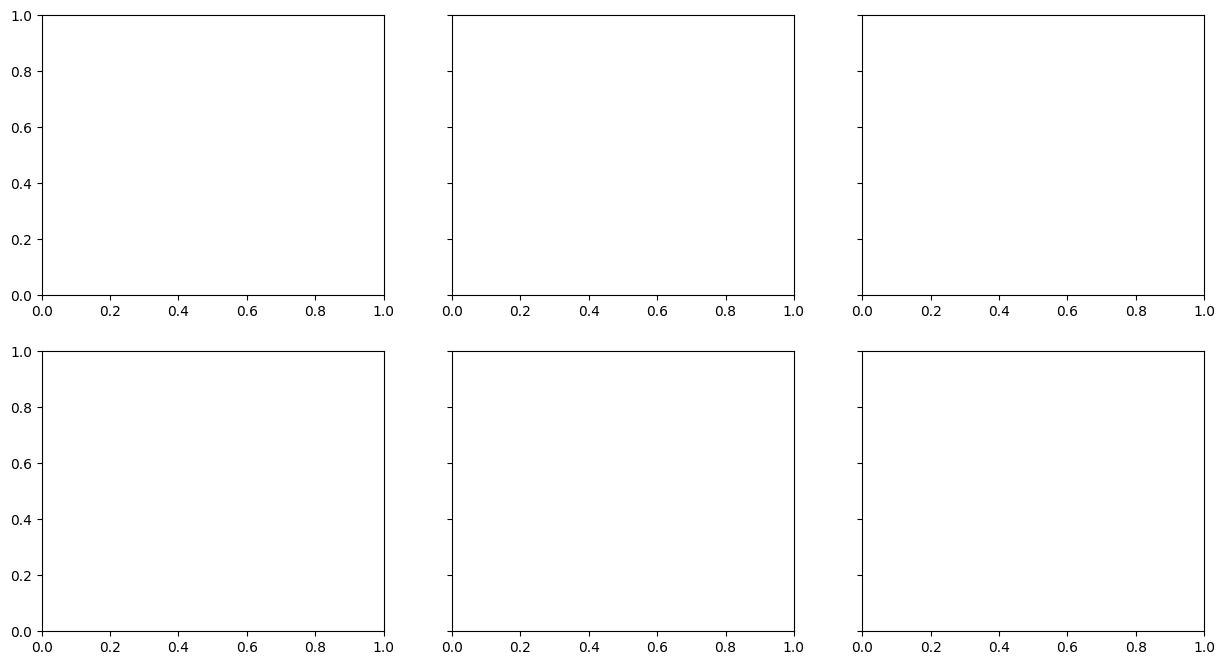

In [37]:
import matplotlib.pyplot as plt

top_airports = df_alerts["airport"].value_counts().head(6).index

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=False, sharey=True)
axes = axes.ravel()

for ax, airport in zip(axes, top_airports):
    data = df_alerts.loc[df_alerts["airport"] == airport, "duration"]
    ax.hist(data, bins=30, alpha=0.8)
    ax.axvline(data.mean(), color="red", linestyle="--", label=f"Moy: {data.mean():.1f}")
    ax.set_title(airport)
    ax.set_xlabel("Durée (min)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Distribution des durées d’alerte par aéroport")
plt.tight_layout()
plt.show()

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FILE_PATH = "segment_alerts_all_airports_train.csv"

df = pd.read_csv(FILE_PATH)
print("Fichier chargé avec succès")
print(df.columns.tolist())
df.head()

Fichier chargé avec succès
['lightning_id', 'lightning_airport_id', 'date', 'lon', 'lat', 'amplitude', 'maxis', 'icloud', 'dist', 'azimuth', 'airport', 'airport_alert_id', 'is_last_lightning_cloud_ground']


,lightning_id,lightning_airport_id,date,lon,lat,amplitude,maxis,icloud,dist,azimuth,airport,airport_alert_id,is_last_lightning_cloud_ground
0,1,1,2016-01-02 14:53:36+00:00,9.0559,42.0826,-9.90,0.3,False,27.360653,57.852343,Ajaccio,NaN,NaN
1,2,2,2016-01-02 14:53:36+00:00,9.0236,42.0953,-3.33,0.2,True,26.383167,52.117828,Ajaccio,NaN,NaN
2,3,3,2016-01-02 21:22:53+00:00,8.8585,42.0456,-18.68,0.4,True,14.313391,24.500543,Ajaccio,NaN,NaN
3,4,4,2016-01-02 21:22:53+00:00,8.8517,42.0517,-7.51,0.2,False,14.794117,20.854458,Ajaccio,1.0,False
4,5,5,2016-01-02 21:24:46+00:00,8.8728,42.0494,-6.01,0.2,False,15.124224,29.058471,Ajaccio,1.0,False


In [39]:
# À lancer une seule fois avant les analyses ci-dessous

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- brut événementiel ---
FILE_PATH = "segment_alerts_all_airports_train.csv"
df_raw = pd.read_csv(FILE_PATH)
df_raw["date"] = pd.to_datetime(df_raw["date"], utc=True)
df_raw["type"] = np.where(df_raw["icloud"].fillna(False), "IC", "CG")
df_raw["zone"] = np.where(df_raw["dist"] < 20, "inner", "outer")

# --- niveau alerte ---
df_feat = pd.read_parquet("features.parquet")

first_cg = (
    df_raw[(df_raw["type"] == "CG") & (df_raw["airport_alert_id"].notna())]
    .groupby(["airport", "airport_alert_id"])["date"]
    .min()
    .reset_index()
    .rename(columns={"date": "t_start"})
)

df_alerts = df_feat.merge(first_cg, on=["airport", "airport_alert_id"], how="left")
df_alerts["hour"] = df_alerts["t_start"].dt.hour
df_alerts["month"] = df_alerts["t_start"].dt.month
df_alerts["season"] = df_alerts["month"].map({
    12: "Hiver", 1: "Hiver", 2: "Hiver",
    3: "Printemps", 4: "Printemps", 5: "Printemps",
    6: "Été", 7: "Été", 8: "Été",
    9: "Automne", 10: "Automne", 11: "Automne"
})

print("df_raw :", df_raw.shape)
print("df_alerts :", df_alerts.shape)
print(df_alerts[["airport", "airport_alert_id", "duration", "hour", "month", "season"]].head())


FileNotFoundError: [Errno 2] No such file or directory: 'features.parquet'

count    1682.00
mean        6.97
std         6.99
min         0.00
25%         2.00
50%         4.18
75%         9.80
max        29.65
Name: gap_before_last_cg_inner_min, dtype: float64


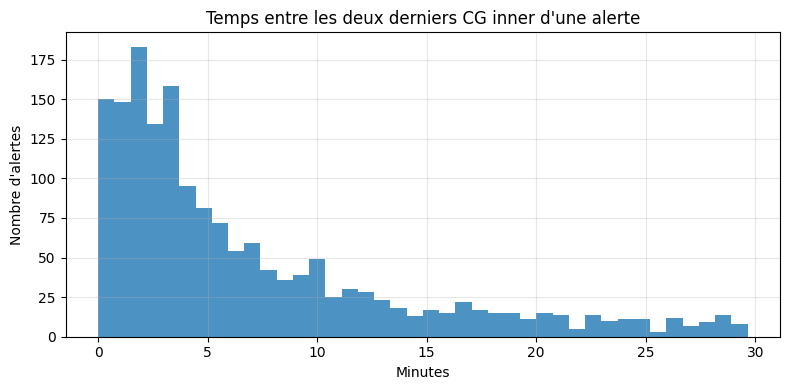

In [40]:
cg_inner = df_raw[
    (df_raw["type"] == "CG") &
    (df_raw["dist"] < 20) &
    (df_raw["airport_alert_id"].notna())
].copy()

last_two = (
    cg_inner.sort_values(["airport", "airport_alert_id", "date"])
    .groupby(["airport", "airport_alert_id"])["date"]
    .apply(lambda s: s.tail(2).tolist())
    .reset_index(name="last_two_dates")
)

def gap_last_two(x):
    if len(x) < 2:
        return np.nan
    return (x[-1] - x[-2]).total_seconds() / 60

last_two["gap_before_last_cg_inner_min"] = last_two["last_two_dates"].apply(gap_last_two)

print(last_two["gap_before_last_cg_inner_min"].describe().round(2))

plt.figure(figsize=(8, 4))
plt.hist(last_two["gap_before_last_cg_inner_min"].dropna(), bins=40, alpha=0.8)
plt.title("Temps entre les deux derniers CG inner d'une alerte")
plt.xlabel("Minutes")
plt.ylabel("Nombre d'alertes")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [41]:
# Q1.3 — contexte des 10 min avant le dernier CG inner (version rapide)

last_cg = (
    df_raw[
        (df_raw["type"] == "CG") &
        (df_raw["dist"] < 20) &
        (df_raw["airport_alert_id"].notna())
    ]
    .groupby(["airport", "airport_alert_id"], as_index=False)["date"]
    .max()
    .rename(columns={"date": "last_cg_time"})
)

ctx = (
    df_raw[df_raw["airport_alert_id"].notna()][["airport", "airport_alert_id", "date", "dist", "type"]]
    .merge(last_cg, on=["airport", "airport_alert_id"], how="inner")
)

ctx = ctx[
    (ctx["date"] <= ctx["last_cg_time"]) &
    (ctx["date"] > ctx["last_cg_time"] - pd.Timedelta(minutes=10))
].copy()

ctx["is_outer_20_30"] = (ctx["dist"] >= 20) & (ctx["dist"] < 30)
ctx["is_cg_outer_20_30"] = (ctx["type"] == "CG") & ctx["is_outer_20_30"]

df_lastcg_context = (
    ctx.groupby(["airport", "airport_alert_id", "last_cg_time"], as_index=False)
    .agg(
        n_total_last_10m_before_last_cg=("date", "size"),
        n_outer_last_10m_before_last_cg=("is_outer_20_30", "sum"),
        n_cg_outer_last_10m_before_last_cg=("is_cg_outer_20_30", "sum"),
        dist_min_last_10m_before_last_cg=("dist", "min"),
        dist_mean_last_10m_before_last_cg=("dist", "mean"),
    )
)

print(df_lastcg_context.head())
print(df_lastcg_context.describe(include="all"))

   airport  airport_alert_id              last_cg_time  \
0  Ajaccio               1.0 2016-01-02 21:28:54+00:00   
1  Ajaccio               2.0 2016-01-12 06:37:45+00:00   
2  Ajaccio               3.0 2016-01-12 07:25:37+00:00   
3  Ajaccio               4.0 2016-02-07 14:05:14+00:00   
4  Ajaccio               5.0 2016-02-07 14:35:39+00:00   

   n_total_last_10m_before_last_cg  n_outer_last_10m_before_last_cg  \
0                                5                                0   
1                                1                                0   
2                                1                                0   
3                                1                                0   
4                                1                                0   

   n_cg_outer_last_10m_before_last_cg  dist_min_last_10m_before_last_cg  \
0                                   0                         14.794117   
1                                   0                         12.875968   

In [42]:
alert_summary = (
    df_raw[df_raw["airport_alert_id"].notna()]
    .groupby(["airport", "airport_alert_id"])
    .agg(
        n_events=("date", "size"),
        n_cg_inner=("dist", lambda s: ((df_raw.loc[s.index, "type"] == "CG") & (df_raw.loc[s.index, "dist"] < 20)).sum()),
        min_dist=("dist", "min"),
    )
    .reset_index()
)

alert_summary = alert_summary.merge(
    df_alerts[["airport", "airport_alert_id", "duration"]],
    on=["airport", "airport_alert_id"],
    how="left"
)

print(alert_summary[["duration", "n_events", "n_cg_inner", "min_dist"]].corr().round(3))

KeyError: "['duration'] not in index"

In [43]:
CLOSE_RADIUS_KM = 3.0

close_per_alert = (
    df_raw[df_raw["airport_alert_id"].notna()]
    .assign(is_cg_close=lambda x: (x["type"] == "CG") & (x["dist"] < CLOSE_RADIUS_KM))
    .groupby(["airport", "airport_alert_id"])["is_cg_close"]
    .max()
    .reset_index(name="has_close_cg")
)

print("Part globale d'alertes avec au moins un CG < 3 km :")
print(f"{100 * close_per_alert['has_close_cg'].mean():.2f}%")

print("\nPar aéroport :")
print((100 * close_per_alert.groupby('airport')["has_close_cg"].mean()).round(2).sort_values(ascending=False))

Part globale d'alertes avec au moins un CG < 3 km :
13.67%

Par aéroport :
airport
Nantes      17.48
Biarritz    14.07
Ajaccio     13.96
Pise        13.52
Bastia      11.65
Name: has_close_cg, dtype: float64


In [44]:
alert_close = df_alerts.merge(
    close_per_alert,
    on=["airport", "airport_alert_id"],
    how="left"
).fillna({"has_close_cg": 0})

print(
    alert_close.groupby("has_close_cg")["duration"]
    .agg(["mean", "median", "count"])
    .round(2)
)

plt.figure(figsize=(8, 4))
for label, val in [("Sans CG < 3 km", 0), ("Avec CG < 3 km", 1)]:
    data = alert_close.loc[alert_close["has_close_cg"] == val, "duration"].dropna()
    plt.hist(data, bins=30, alpha=0.5, label=label)

plt.title("Distribution des durées selon présence d'un CG < 3 km")
plt.xlabel("Durée (min)")
plt.ylabel("Nombre d'alertes")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

KeyError: 'Column not found: duration'

count    2627.00
mean       10.89
std         5.95
min         0.04
25%         5.73
50%        11.51
75%        16.28
max        19.99
Name: min_dist, dtype: float64


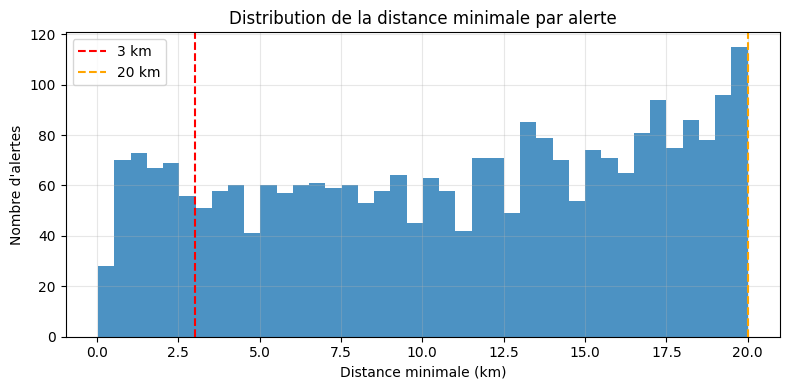

In [ ]:
min_dist_per_alert = (
    df_raw[df_raw["airport_alert_id"].notna()]
    .groupby(["airport", "airport_alert_id"])["dist"]
    .min()
    .reset_index(name="min_dist")
)

print(min_dist_per_alert["min_dist"].describe().round(2))

plt.figure(figsize=(8, 4))
plt.hist(min_dist_per_alert["min_dist"], bins=40, alpha=0.8)
plt.axvline(3, color="red", linestyle="--", label="3 km")
plt.axvline(20, color="orange", linestyle="--", label="20 km")
plt.title("Distribution de la distance minimale par alerte")
plt.xlabel("Distance minimale (km)")
plt.ylabel("Nombre d'alertes")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [45]:
cg_inner_counts = (
    df_raw[df_raw["airport_alert_id"].notna()]
    .assign(is_cg_inner=lambda x: (x["type"] == "CG") & (x["dist"] < 20))
    .groupby(["airport", "airport_alert_id"])["is_cg_inner"]
    .sum()
    .reset_index(name="n_cg_inner")
)

close_profile = (
    close_per_alert
    .merge(cg_inner_counts, on=["airport", "airport_alert_id"], how="left")
    .merge(df_alerts[["airport", "airport_alert_id", "duration"]], on=["airport", "airport_alert_id"], how="left")
)

print(close_profile.groupby("has_close_cg")[["n_cg_inner", "duration"]].agg(["mean", "median"]).round(2))

KeyError: "['duration'] not in index"

In [46]:
airport_summary = (
    df_alerts.groupby("airport")
    .agg(
        n_alerts=("airport_alert_id", "nunique"),
        mean_duration=("duration", "mean"),
        median_duration=("duration", "median"),
        std_duration=("duration", "std"),
    )
    .reset_index()
)

cg_inner_per_alert = (
    df_raw[df_raw["airport_alert_id"].notna()]
    .assign(is_cg_inner=lambda x: (x["type"] == "CG") & (x["dist"] < 20))
    .groupby(["airport", "airport_alert_id"])["is_cg_inner"]
    .sum()
    .reset_index(name="n_cg_inner")
)

airport_cg = (
    cg_inner_per_alert.groupby("airport")["n_cg_inner"]
    .agg(mean_cg_inner="mean", median_cg_inner="median")
    .reset_index()
)

airport_min_dist = (
    min_dist_per_alert.groupby("airport")["min_dist"]
    .agg(mean_min_dist="mean", median_min_dist="median")
    .reset_index()
)

airport_close = (
    close_per_alert.groupby("airport")["has_close_cg"]
    .mean()
    .reset_index(name="rate_close_cg")
)

airport_full = (
    airport_summary
    .merge(airport_cg, on="airport", how="left")
    .merge(airport_min_dist, on="airport", how="left")
    .merge(airport_close, on="airport", how="left")
)

airport_full["rate_close_cg"] = 100 * airport_full["rate_close_cg"]

print(airport_full.round(2).sort_values("mean_duration", ascending=False))

KeyError: "Column(s) ['duration'] do not exist"

NameError: name 'airport_full' is not defined

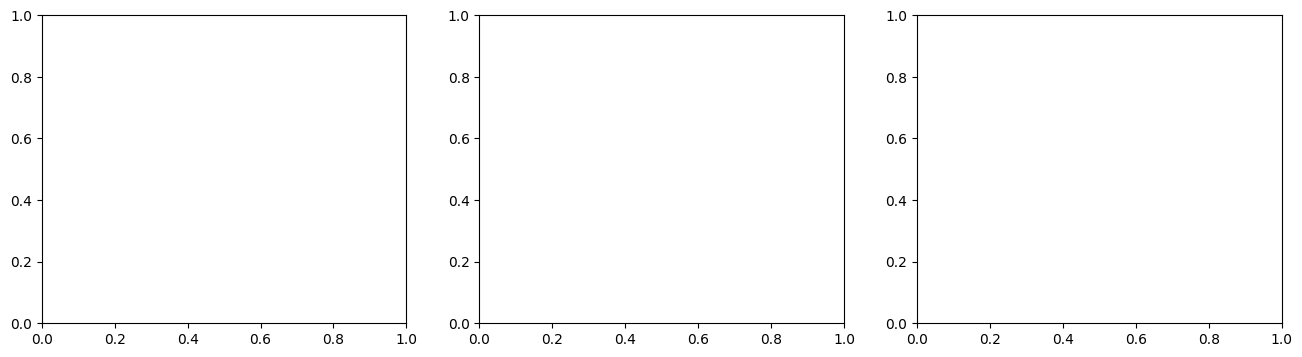

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

airport_full.sort_values("mean_duration", ascending=False).plot(
    x="airport", y="mean_duration", kind="bar", ax=axes[0], legend=False
)
axes[0].set_title("Durée moyenne par aéroport")
axes[0].set_ylabel("Minutes")
axes[0].grid(axis="y", alpha=0.3)

airport_full.sort_values("mean_cg_inner", ascending=False).plot(
    x="airport", y="mean_cg_inner", kind="bar", ax=axes[1], legend=False
)
axes[1].set_title("Nombre moyen de CG inner par alerte")
axes[1].set_ylabel("CG inner")
axes[1].grid(axis="y", alpha=0.3)

airport_full.sort_values("rate_close_cg", ascending=False).plot(
    x="airport", y="rate_close_cg", kind="bar", ax=axes[2], legend=False
)
axes[2].set_title("Taux d'alertes avec CG < 3 km")
axes[2].set_ylabel("%")
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [48]:
alert_type_df = (
    df_alerts[["airport", "airport_alert_id", "duration"]]
    .merge(cg_inner_counts, on=["airport", "airport_alert_id"], how="left")
    .merge(min_dist_per_alert, on=["airport", "airport_alert_id"], how="left")
    .merge(close_per_alert, on=["airport", "airport_alert_id"], how="left")
)

# qcut robuste aux ex aequo
alert_type_df["duration_bin"] = pd.qcut(
    alert_type_df["duration"].rank(method="first"),
    q=3,
    labels=["courte", "moyenne", "longue"]
)

alert_type_df["cg_inner_bin"] = pd.qcut(
    alert_type_df["n_cg_inner"].rank(method="first"),
    q=3,
    labels=["faible", "moyen", "fort"]
)

alert_type_df["proximity_bin"] = pd.cut(
    alert_type_df["min_dist"],
    bins=[0, 3, 10, 20, np.inf],
    labels=["<3 km", "3-10 km", "10-20 km", ">20 km"],
    include_lowest=True
)

print(alert_type_df.head())

print("\nTypologie durée x intensité :")
print(pd.crosstab(alert_type_df["duration_bin"], alert_type_df["cg_inner_bin"]))

print("\nTypologie durée x proximité :")
print(pd.crosstab(alert_type_df["duration_bin"], alert_type_df["proximity_bin"]))

KeyError: "['duration'] not in index"

In [49]:
type_by_airport = pd.crosstab(
    alert_type_df["airport"],
    alert_type_df["proximity_bin"],
    normalize="index"
) * 100

print(type_by_airport.round(1))

NameError: name 'alert_type_df' is not defined

In [50]:
alert_local = alert_type_df.merge(
    df_alerts[["airport", "airport_alert_id", "hour", "month"]],
    on=["airport", "airport_alert_id"],
    how="left"
)

for airport, sub in alert_local.groupby("airport"):
    print(f"\n--- {airport} ---")
    print(sub[["duration", "n_cg_inner", "min_dist", "hour", "month"]].corr().round(2))

NameError: name 'alert_type_df' is not defined

In [51]:
# %%
# Setup — à lancer en premier (recharge tout si kernel redémarré)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FILE_PATH = "segment_alerts_all_airports_train.csv"

df_raw = pd.read_csv(FILE_PATH)
df_raw["date"] = pd.to_datetime(df_raw["date"], utc=True)
df_raw["type"] = np.where(df_raw["icloud"].fillna(False), "IC", "CG")
df_raw["zone"] = np.where(df_raw["dist"] < 20, "inner", "outer")

df_feat = pd.read_parquet("features.parquet")

first_cg = (
    df_raw[(df_raw["type"] == "CG") & (df_raw["airport_alert_id"].notna())]
    .groupby(["airport", "airport_alert_id"])["date"]
    .min()
    .reset_index()
    .rename(columns={"date": "t_start"})
)

df_alerts = df_feat.merge(first_cg, on=["airport", "airport_alert_id"], how="left")

print(f"df_raw   : {df_raw.shape}")
print(f"df_alerts: {df_alerts.shape}")

FileNotFoundError: [Errno 2] No such file or directory: 'features.parquet'

In [ ]:
# %%
# Chunk 1 corrigé — coordonnées officielles ICAO des 5 aéroports

airport_coords = {
    "Ajaccio":  {"lat": 41.9236, "lon":  8.8029},  # LFKJ
    "Bastia":   {"lat": 42.5527, "lon":  9.4837},  # LFKB
    "Biarritz": {"lat": 43.4684, "lon": -1.5232},  # LFBZ
    "Nantes":   {"lat": 47.1532, "lon": -1.6107},  # LFRS
    "Pise":     {"lat": 43.6839, "lon": 10.3927},  # LIRP
}

def compute_azimuth_from_coords(lat_e, lon_e, lat_ap, lon_ap):
    dlat = lat_e - lat_ap
    dlon = lon_e - lon_ap
    return np.degrees(np.arctan2(dlon, dlat)) % 360

sample = df_raw.dropna(subset=["airport_alert_id"]).head(5000).copy()
sample["lat_ap"] = sample["airport"].map(lambda a: airport_coords[a]["lat"])
sample["lon_ap"] = sample["airport"].map(lambda a: airport_coords[a]["lon"])
sample["azimuth_computed"] = compute_azimuth_from_coords(
    sample["lat"], sample["lon"],
    sample["lat_ap"], sample["lon_ap"]
)

corr = sample[["azimuth", "azimuth_computed"]].corr().iloc[0, 1]
print(f"Corrélation azimuth brut vs azimuth recalculé (coords exactes) : {corr:.4f}")
print("→ Avec les coords approx (moyenne des éclairs) : 0.7535")
print("→ Écart résiduel = convention de calcul différente (géodésique vs plan)")

NameError: name 'df_raw' is not defined

NameError: name 'df_raw' is not defined

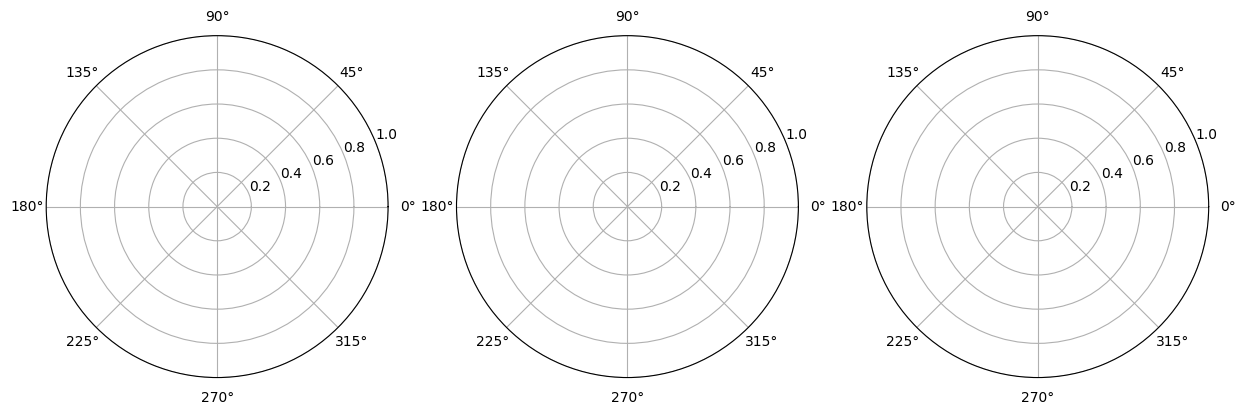

In [ ]:
# %%
# Chunk 2 — Distribution angulaire par catégorie (rose des vents)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), subplot_kw=dict(projection='polar'))

configs = [
    ("CG inner", (df_raw["type"] == "CG") & (df_raw["zone"] == "inner"), "#e74c3c"),
    ("CG outer", (df_raw["type"] == "CG") & (df_raw["zone"] == "outer"), "#f39c12"),
    ("IC outer", (df_raw["type"] == "IC") & (df_raw["zone"] == "outer"), "#3498db"),
]

for ax, (label, mask, color) in zip(axes, configs):
    az_rad = np.radians(df_raw.loc[mask, "azimuth"].dropna())
    ax.hist(az_rad, bins=36, color=color, alpha=0.75)
    ax.set_title(label, pad=14, fontsize=11)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

plt.suptitle("Distribution angulaire des éclairs (rose des vents)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
# → Si uniforme : pas de secteur privilégié globalement
# → Si concentré dans un secteur : les orages arrivent souvent d'une direction

In [ ]:
# %%
# Chunk 3 — Dispersion angulaire par alerte : lien avec la durée ?

def circular_std(azimuths_deg):
    """Écart-type circulaire (en degrés). Varie entre 0° (concentré) et ~81° (uniforme)."""
    if len(azimuths_deg) < 2:
        return np.nan
    rad = np.radians(azimuths_deg)
    R = np.sqrt(np.mean(np.cos(rad))**2 + np.mean(np.sin(rad))**2)
    return np.degrees(np.sqrt(-2 * np.log(np.clip(R, 1e-10, 1))))

az_disp = (
    df_raw[df_raw["airport_alert_id"].notna()]
    .groupby(["airport", "airport_alert_id"])["azimuth"]
    .apply(circular_std)
    .reset_index(name="az_circ_std_alert")
)

az_disp = az_disp.merge(
    df_alerts[["airport", "airport_alert_id", "duration"]],
    on=["airport", "airport_alert_id"], how="left"
)

corr_disp = az_disp["az_circ_std_alert"].corr(az_disp["duration"])
print(f"Corrélation dispersion angulaire ↔ durée alerte : {corr_disp:.3f}")
print(az_disp["az_circ_std_alert"].describe().round(1))

plt.figure(figsize=(8, 4))
plt.scatter(az_disp["az_circ_std_alert"], az_disp["duration"],
            alpha=0.25, s=8, color="#3078c8")
plt.xlabel("Dispersion angulaire de l'alerte (°)")
plt.ylabel("Durée (min)")
plt.title("Alerte qui encercle l'aéroport → dure-t-elle plus longtemps ?")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'df_raw' is not defined

In [52]:
# %%
# Chunk 4 — L'orage se déplace-t-il au cours de l'alerte ?
# Compare l'azimuth moyen 1ère moitié vs 2ème moitié des CG inner

def mean_circular_angle(azimuths_deg):
    rad = np.radians(azimuths_deg)
    return np.degrees(np.arctan2(np.mean(np.sin(rad)), np.mean(np.cos(rad)))) % 360

def angular_diff(a1, a2):
    return abs((a2 - a1 + 180) % 360 - 180)

cg_inner_raw = df_raw[
    (df_raw["type"] == "CG") &
    (df_raw["zone"] == "inner") &
    (df_raw["airport_alert_id"].notna())
].copy()

def directional_shift(group):
    group = group.sort_values("date")
    n = len(group)
    if n < 4:
        return np.nan
    mid = n // 2
    az1 = mean_circular_angle(group.iloc[:mid]["azimuth"].values)
    az2 = mean_circular_angle(group.iloc[mid:]["azimuth"].values)
    return angular_diff(az1, az2)

shift = (
    cg_inner_raw.groupby(["airport", "airport_alert_id"])
    .apply(directional_shift, include_groups=False)
    .reset_index(name="az_shift_deg")
)

shift = shift.merge(
    df_alerts[["airport", "airport_alert_id", "duration"]],
    on=["airport", "airport_alert_id"], how="left"
)

corr_shift = shift["az_shift_deg"].corr(shift["duration"])
print(f"Corrélation déplacement angulaire ↔ durée : {corr_shift:.3f}")
print(shift["az_shift_deg"].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(shift["az_shift_deg"].dropna(), bins=36, alpha=0.8, color="#3078c8")
axes[0].set_xlabel("Déplacement angulaire 1ère→2ème moitié (°)")
axes[0].set_ylabel("Nombre d'alertes")
axes[0].set_title("L'orage tourne-t-il au cours de l'alerte ?")
axes[0].grid(alpha=0.3)

axes[1].scatter(shift["az_shift_deg"], shift["duration"],
                alpha=0.25, s=8, color="#e74c3c")
axes[1].set_xlabel("Déplacement angulaire (°)")
axes[1].set_ylabel("Durée (min)")
axes[1].set_title("Déplacement angulaire vs durée")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

KeyError: "['duration'] not in index"

In [53]:
# %%
# Chunk 5 — Test rapide : azimuth apporte-t-il de l'info au-delà de dist_min ?

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

merged = (
    az_disp.dropna()
    .merge(
        df_raw[df_raw["airport_alert_id"].notna()]
        .groupby(["airport", "airport_alert_id"])["dist"]
        .min()
        .reset_index(name="min_dist"),
        on=["airport", "airport_alert_id"], how="left"
    )
    .dropna(subset=["min_dist", "az_circ_std_alert", "duration"])
)

# Proxy label : alerte longue (> médiane) = 1
med = merged["duration"].median()
merged["y"] = (merged["duration"] > med).astype(int)

sc = StandardScaler()
X1 = sc.fit_transform(merged[["min_dist"]])
X2 = sc.fit_transform(merged[["min_dist", "az_circ_std_alert"]])

auc1 = roc_auc_score(merged["y"],
    LogisticRegression().fit(X1, merged["y"]).predict_proba(X1)[:, 1])
auc2 = roc_auc_score(merged["y"],
    LogisticRegression().fit(X2, merged["y"]).predict_proba(X2)[:, 1])

print(f"AUC dist_min seul                    : {auc1:.4f}")
print(f"AUC dist_min + az_circ_std_alert     : {auc2:.4f}")
print(f"Gain                                 : {auc2 - auc1:+.4f}")
print()
print("Interprétation :")
print("  gain > 0.01  → azimuth porte de l'info non redondante, vaut la peine d'être dans le modèle")
print("  gain ≈ 0     → dist_min capture déjà tout, azimuth redondant au niveau alerte")
print("  (Note : le test ici est au niveau alerte ; l'azimuth peut quand même aider")
print("   au niveau instant de décision via des features de tendance angulaire)")

NameError: name 'az_disp' is not defined

In [54]:
df = pd.read_csv("/home/onyxia/work/Dataverse/Dataverse/output/silence_dataset.csv")

    min_since_cg      p_y1      n
0              1  0.140159  18743
1              2  0.220349  11922
2              3  0.294177   8930
3              4  0.361696   7263
4              5  0.422959   6211
5              6  0.474017   5542
6              7  0.519478   5057
7              8  0.561205   4681
8              9  0.595557   4411
9             10  0.632403   4154
10            11  0.663216   3961
11            12  0.690045   3807
12            13  0.717564   3661
13            14  0.741462   3543
14            15  0.766560   3427

P(y=1) à 1 min  : 0.140
P(y=1) à 5 min  : 0.423
P(y=1) à 10 min : 0.632
P(y=1) à 20 min : 0.857


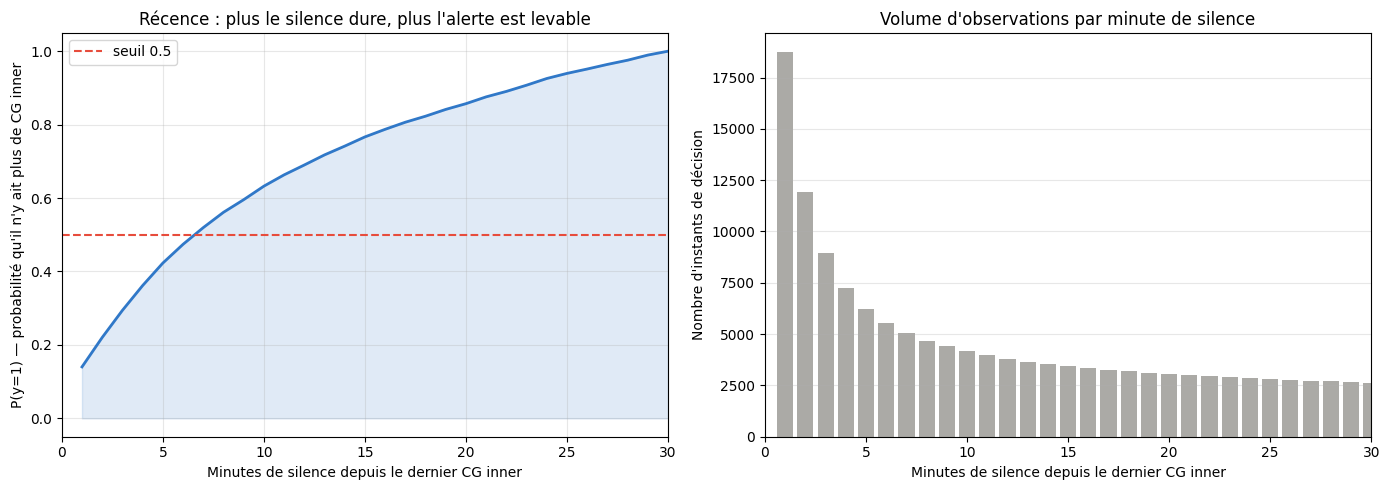

In [55]:
# %%
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

SILENCE_PATH = "/home/onyxia/work/Dataverse/Dataverse/output/silence_dataset.csv"
OUTPUT_PATH = "/home/onyxia/work/Dataverse/Dataverse/output"

df = pd.read_csv(SILENCE_PATH)

# Arrondir à la minute entière pour grouper
df["min_since_cg"] = df["minutes_since_reference_cg"].round(0).astype(int)

# Probabilité de y=1 par minute de silence
curve = (
    df.groupby("min_since_cg")["y"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "p_y1", "count": "n"})
)

# Garder seulement les minutes avec assez d'observations
curve = curve[curve["n"] >= 50]

print(curve.head(15).to_string())
print(f"\nP(y=1) à 1 min  : {curve[curve['min_since_cg']==1]['p_y1'].values[0]:.3f}")
print(f"P(y=1) à 5 min  : {curve[curve['min_since_cg']==5]['p_y1'].values[0]:.3f}")
print(f"P(y=1) à 10 min : {curve[curve['min_since_cg']==10]['p_y1'].values[0]:.3f}")
print(f"P(y=1) à 20 min : {curve[curve['min_since_cg']==20]['p_y1'].values[0]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe principale
axes[0].plot(curve["min_since_cg"], curve["p_y1"], color="#3078c8", linewidth=2)
axes[0].axhline(0.5, color="#e74c3c", linestyle="--", label="seuil 0.5")
axes[0].fill_between(curve["min_since_cg"], curve["p_y1"], alpha=0.15, color="#3078c8")
axes[0].set_xlabel("Minutes de silence depuis le dernier CG inner")
axes[0].set_ylabel("P(y=1) — probabilité qu'il n'y ait plus de CG inner")
axes[0].set_title("Récence : plus le silence dure, plus l'alerte est levable")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xlim(0, 30)

# Volume d'observations par minute
axes[1].bar(curve["min_since_cg"], curve["n"], color="#888780", alpha=0.7)
axes[1].set_xlabel("Minutes de silence depuis le dernier CG inner")
axes[1].set_ylabel("Nombre d'instants de décision")
axes[1].set_title("Volume d'observations par minute de silence")
axes[1].grid(alpha=0.3, axis="y")
axes[1].set_xlim(0, 30)

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/recence_y1_vs_silence.png", dpi=130, bbox_inches="tight")
plt.show()

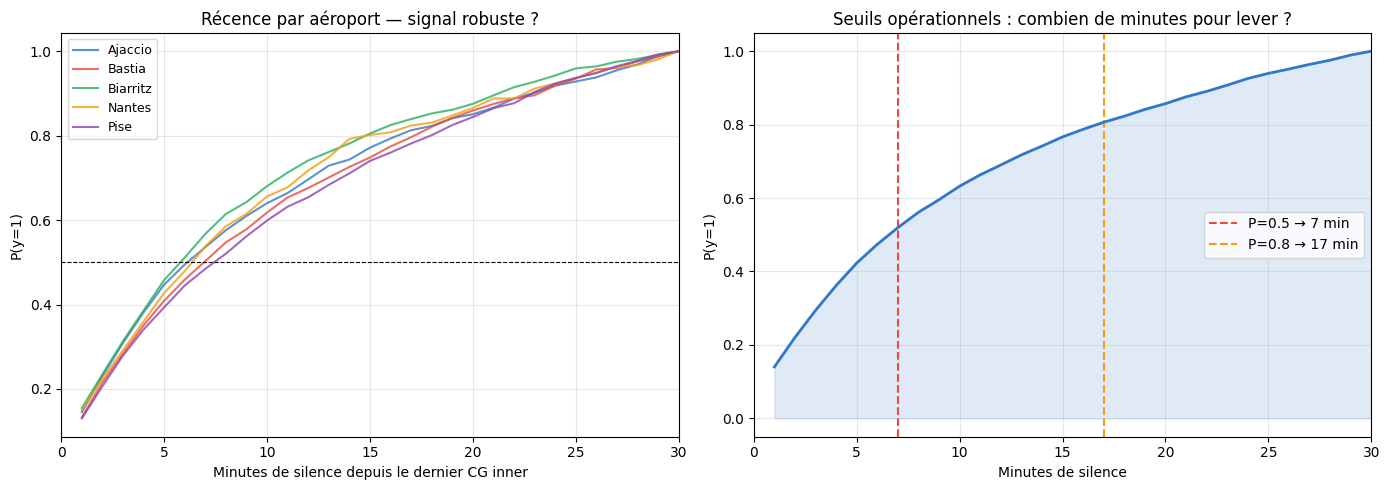

In [56]:
# %%
# Par aéroport — robustesse du signal

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {
    "Ajaccio": "#3078c8", "Bastia": "#e74c3c",
    "Biarritz": "#27ae60", "Nantes": "#f39c12", "Pise": "#8e44ad"
}

for airport, g in df.groupby("airport"):
    c = (
        g.assign(min_since_cg=g["minutes_since_reference_cg"].round(0).astype(int))
        .groupby("min_since_cg")["y"]
        .agg(["mean", "count"])
        .reset_index()
    )
    c = c[c["count"] >= 20]
    axes[0].plot(c["min_since_cg"], c["mean"],
                 label=airport, color=colors[airport], linewidth=1.5, alpha=0.8)

axes[0].axhline(0.5, color="black", linestyle="--", linewidth=0.8)
axes[0].set_xlim(0, 30)
axes[0].set_xlabel("Minutes de silence depuis le dernier CG inner")
axes[0].set_ylabel("P(y=1)")
axes[0].set_title("Récence par aéroport — signal robuste ?")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Seuils opérationnels
for seuil, color, label in [(0.5, "#e74c3c", "P=0.5"), (0.8, "#f39c12", "P=0.8")]:
    above = curve[curve["p_y1"] >= seuil]
    if len(above) > 0:
        t_cross = above["min_since_cg"].iloc[0]
        axes[1].axvline(t_cross, color=color, linestyle="--",
                        label=f"{label} → {t_cross} min")

axes[1].plot(curve["min_since_cg"], curve["p_y1"], color="#3078c8", linewidth=2)
axes[1].fill_between(curve["min_since_cg"], curve["p_y1"], alpha=0.15, color="#3078c8")
axes[1].set_xlim(0, 30)
axes[1].set_xlabel("Minutes de silence")
axes[1].set_ylabel("P(y=1)")
axes[1].set_title("Seuils opérationnels : combien de minutes pour lever ?")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/recence_par_airport.png", dpi=130, bbox_inches="tight")
plt.show()

In [57]:
# %%
# Analyse : les alertes avec CG très proches (<3km) sont-elles plus dures à lever ?

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/home/onyxia/work/Dataverse/Dataverse/output/silence_dataset.csv")
df["min_since_cg"] = df["minutes_since_reference_cg"].round(0).astype(int)

# Identifier les alertes qui ont eu au moins un CG < 3km
# dist_min = distance minimale observée sur tout l'historique jusqu'à t
CLOSE_KM = 3.0

df["had_close_cg"] = df["dist_min"] < CLOSE_KM

print("Répartition alertes avec/sans CG < 3km :")
print(df.groupby("had_close_cg")["alert_group"].nunique())
print(f"\nSoit {100*df['had_close_cg'].mean():.1f}% des instants de décision"
      f" proviennent d'alertes avec au moins un CG < {CLOSE_KM}km")

Répartition alertes avec/sans CG < 3km :
had_close_cg
False    2553
True      520
Name: alert_group, dtype: int64

Soit 24.7% des instants de décision proviennent d'alertes avec au moins un CG < 3.0km


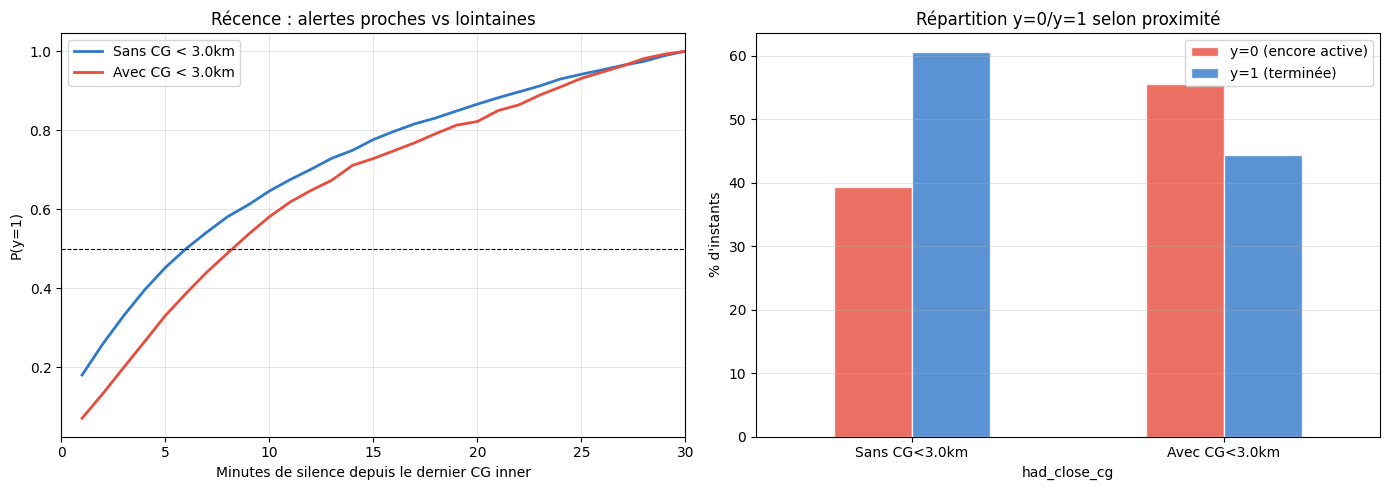

In [58]:
# %%
# Courbe P(y=1) vs silence — comparaison alertes proches vs lointaines

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for had_close, label, color in [
    (False, f"Sans CG < {CLOSE_KM}km", "#3078c8"),
    (True,  f"Avec CG < {CLOSE_KM}km", "#e74c3c"),
]:
    sub = df[df["had_close_cg"] == had_close]
    curve = (
        sub.groupby("min_since_cg")["y"]
        .agg(["mean", "count"])
        .reset_index()
        .rename(columns={"mean": "p_y1", "count": "n"})
    )
    curve = curve[curve["n"] >= 30]
    axes[0].plot(curve["min_since_cg"], curve["p_y1"],
                 label=label, color=color, linewidth=2)

axes[0].axhline(0.5, color="black", linestyle="--", linewidth=0.8)
axes[0].set_xlim(0, 30)
axes[0].set_xlabel("Minutes de silence depuis le dernier CG inner")
axes[0].set_ylabel("P(y=1)")
axes[0].set_title("Récence : alertes proches vs lointaines")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Distribution de y selon la proximité
counts = df.groupby(["had_close_cg", "y"]).size().unstack(fill_value=0)
counts_pct = counts.div(counts.sum(axis=1), axis=0) * 100
counts_pct.plot(kind="bar", ax=axes[1], color=["#e74c3c", "#3078c8"],
                alpha=0.8, edgecolor="white")
axes[1].set_xticklabels([f"Sans CG<{CLOSE_KM}km", f"Avec CG<{CLOSE_KM}km"],
                          rotation=0)
axes[1].set_ylabel("% d'instants")
axes[1].set_title("Répartition y=0/y=1 selon proximité")
axes[1].legend(["y=0 (encore active)", "y=1 (terminée)"])
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("/home/onyxia/work/Dataverse/Dataverse/output/close_cg_analysis.png",
            dpi=130, bbox_inches="tight")
plt.show()

In [59]:
# %%
# Combien de minutes faut-il pour dépasser P(y=1) > 0.8
# selon que l'alerte a eu des CG proches ou non ?

print("=== Seuils opérationnels selon la dangerosité ===\n")

for had_close, label in [(False, f"Sans CG < {CLOSE_KM}km"),
                          (True,  f"Avec CG < {CLOSE_KM}km")]:
    sub = df[df["had_close_cg"] == had_close]
    curve = (
        sub.groupby("min_since_cg")["y"]
        .agg(["mean", "count"])
        .reset_index()
        .rename(columns={"mean": "p_y1", "count": "n"})
    )
    curve = curve[curve["n"] >= 30]

    for seuil in [0.5, 0.8]:
        above = curve[curve["p_y1"] >= seuil]
        if len(above) > 0:
            t = above["min_since_cg"].iloc[0]
            print(f"{label} — P(y=1) > {seuil} atteint à : {t} min de silence")
        else:
            print(f"{label} — P(y=1) > {seuil} : jamais atteint sur 30 min")
    print()

=== Seuils opérationnels selon la dangerosité ===

Sans CG < 3.0km — P(y=1) > 0.5 atteint à : 6 min de silence
Sans CG < 3.0km — P(y=1) > 0.8 atteint à : 17 min de silence

Avec CG < 3.0km — P(y=1) > 0.5 atteint à : 9 min de silence
Avec CG < 3.0km — P(y=1) > 0.8 atteint à : 19 min de silence



In [60]:
# %%
# Direction de l'orage pendant le silence — est-ce que l'azimuth aide ?
# On regarde si la direction/dispersion angulaire des éclairs pendant le silence
# est liée à y (fin d'alerte ou non)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/home/onyxia/work/Dataverse/Dataverse/output/silence_dataset.csv")
df_raw = pd.read_csv("/home/onyxia/work/Dataverse/Dataverse/data/segment_alerts_all_airports_train.csv")
df_raw["date"] = pd.to_datetime(df_raw["date"], utc=True)
df_raw["type"] = np.where(df_raw["icloud"].fillna(False), "IC", "CG")
df_raw["zone"] = np.where(df_raw["dist"] < 20, "inner", "outer")

print(f"Silence dataset : {df.shape}")

Silence dataset : (139226, 63)


In [61]:
# %%
# Courbe ROC + enveloppe convexe + interprétation test_metrics

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull

BASE = "/home/onyxia/work/Dataverse/Dataverse"
ROC_DIR = f"{BASE}/output/baseline_results_A"

# Chargement
roc_df = pd.read_csv(f"{ROC_DIR}/roc_points.csv")
metrics_df = pd.read_csv(f"{ROC_DIR}/test_metrics.csv")

print("Modèles disponibles dans roc_points :", roc_df["model"].unique().tolist())
print("Shape roc_df :", roc_df.shape)

Modèles disponibles dans roc_points : ['logistic', 'knn', 'cart', 'random_forest', 'bagging_tree', 'adaboost_tree', 'xgboost']
Shape roc_df : (40223, 4)


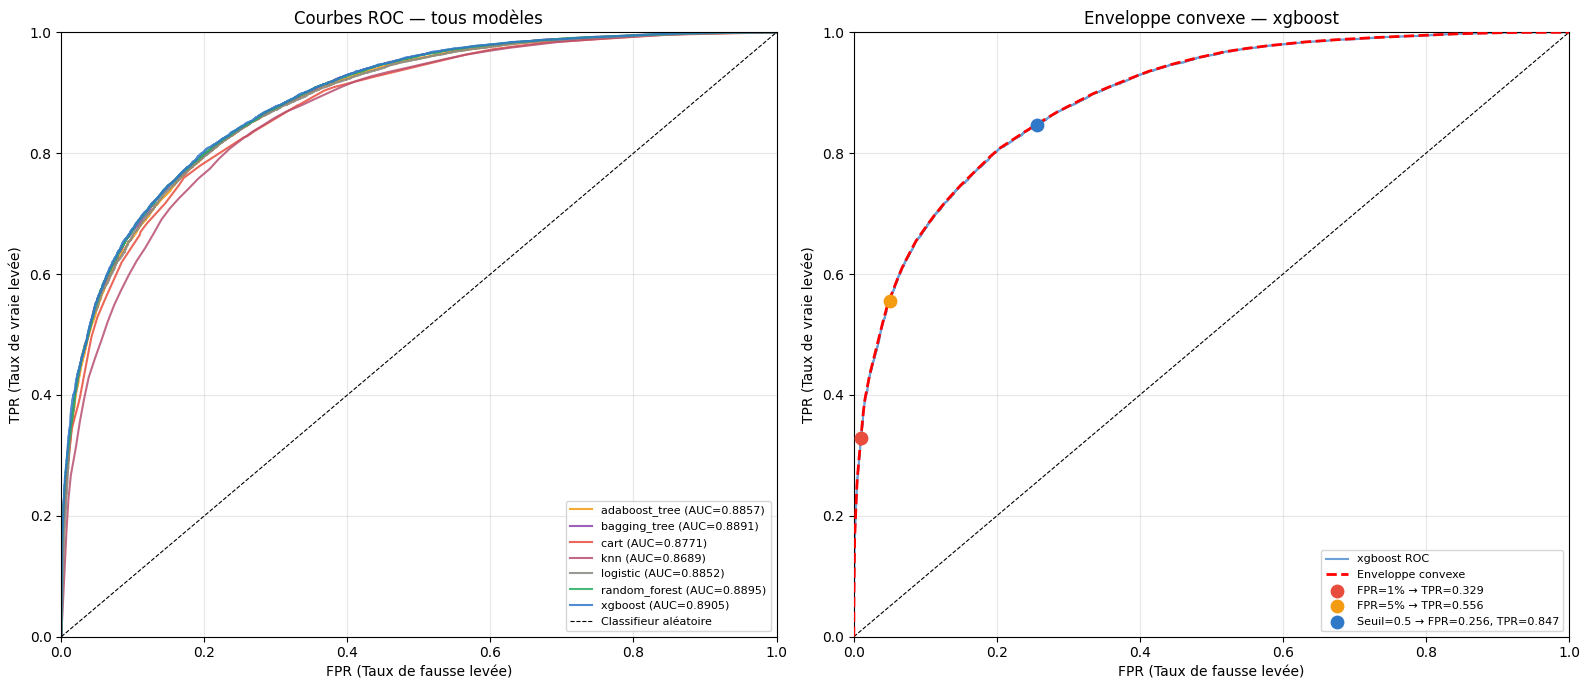

In [62]:
# %%
# Courbe ROC complète pour tous les modèles + enveloppe convexe

"""
ENVELOPPE CONVEXE DE LA COURBE ROC
-----------------------------------
Définition : c'est la plus petite surface convexe contenant la courbe ROC.
Elle représente l'ensemble des classifieurs atteignables par mélange aléatoire
(randomisation) entre deux points de la courbe.

Propriété clé (cours section 5.3) :
- Tout point SOUS l'enveloppe convexe est dominé : il existe une combinaison
  de deux classifieurs qui fait strictement mieux à FPR égal.
- Un classifieur optimal doit opérer SUR l'enveloppe convexe.
- La pente de l'enveloppe en un point = rapport des coûts C(FP)/C(FN).
  Pour choisir le seuil optimal selon la métrique métier, on cherche le point
  de l'enveloppe dont la pente correspond au rapport de coûts souhaité.

LECTURE DES 3 POINTS DE FONCTIONNEMENT (meilleur modèle = XGBoost, AUC=0.8905) :

Point rouge — FPR=1%, TPR=0.329 :
  Seuil de sécurité forte. On n'accepte qu'1% de fausses levées (lever l'alerte
  alors qu'un CG inner arrive encore). En contrepartie, on ne détecte que 33%
  des fins d'alerte réelles — très conservateur, adapté aux situations
  où une fausse levée est une erreur critique.

Point orange — FPR=5%, TPR=0.556 :
  Compromis opérationnel. 5% de fausses levées acceptées, on détecte 56%
  des fins d'alerte. Point de fonctionnement réaliste pour la production,
  à calibrer selon la métrique fournie par Météorage.

Point bleu — seuil=0.5, FPR=0.256, TPR=0.847 :
  Seuil par défaut sklearn. On lève correctement 85% des alertes terminées
  mais au prix de 26% de fausses levées — 1 levée sur 4 serait une erreur
  de sécurité. Ce seuil est inutilisable en production.

CONCLUSION :
  L'enveloppe convexe colle quasiment à la courbe ROC de XGBoost — la courbe
  est déjà quasi-convexe, il n'y a pas de zones creuses à corriger par
  randomisation. Le choix du seuil opérationnel dépendra du rapport de coûts
  C(FP)/C(FN) défini par la métrique Météorage.
  En contexte sécurité aéroportuaire, C(FP) >> C(FN) — une fausse levée
  est bien plus grave qu'une non-levée tardive — ce qui oriente vers
  un point de fonctionnement proche du point rouge (FPR faible).
"""

COLORS = {
    "xgboost": "#3078c8",
    "random_forest": "#27ae60",
    "bagging_tree": "#8e44ad",
    "adaboost_tree": "#f39c12",
    "logistic": "#888780",
    "cart": "#e74c3c",
    "knn": "#b85070",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Graphe gauche : toutes les courbes ROC ──────────────────────────
for model, g in roc_df.groupby("model"):
    g = g.sort_values("fpr")
    axes[0].plot(g["fpr"], g["tpr"],
                 label=f"{model} (AUC={metrics_df[metrics_df['model']==model]['auc'].values[0]:.4f})",
                 color=COLORS.get(model, "gray"), linewidth=1.5, alpha=0.85)

axes[0].plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Classifieur aléatoire")
axes[0].set_xlabel("FPR (Taux de fausse levée)")
axes[0].set_ylabel("TPR (Taux de vraie levée)")
axes[0].set_title("Courbes ROC — tous modèles")
axes[0].legend(fontsize=8, loc="lower right")
axes[0].grid(alpha=0.3)
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)

# ── Graphe droite : enveloppe convexe sur le meilleur modèle ────────
best_model = metrics_df.sort_values("auc", ascending=False).iloc[0]["model"]
g_best = roc_df[roc_df["model"] == best_model].sort_values("fpr").reset_index(drop=True)

axes[1].plot(g_best["fpr"], g_best["tpr"],
             color=COLORS.get(best_model, "blue"),
             linewidth=1.5, label=f"{best_model} ROC", alpha=0.7)

# Calcul enveloppe convexe
points = np.column_stack([g_best["fpr"].values, g_best["tpr"].values])
points = np.vstack([[0, 0], points, [1, 1]])
hull = ConvexHull(points)
hull_pts = points[hull.vertices]
hull_pts = hull_pts[hull_pts[:, 1] >= hull_pts[:, 0]]
hull_pts = hull_pts[hull_pts[:, 0].argsort()]

axes[1].plot(hull_pts[:, 0], hull_pts[:, 1],
             "r--", linewidth=2, label="Enveloppe convexe", zorder=5)

# Points de fonctionnement
row = metrics_df[metrics_df["model"] == best_model].iloc[0]
axes[1].scatter([0.01], [row["tpr_at_fpr_1pct"]],
                color="#e74c3c", s=80, zorder=6,
                label=f"FPR=1% → TPR={row['tpr_at_fpr_1pct']:.3f}")
axes[1].scatter([0.05], [row["tpr_at_fpr_5pct"]],
                color="#f39c12", s=80, zorder=6,
                label=f"FPR=5% → TPR={row['tpr_at_fpr_5pct']:.3f}")
axes[1].scatter([row["fpr_at_threshold_0.5"]], [row["tpr_at_threshold_0.5"]],
                color="#3078c8", s=80, zorder=6,
                label=f"Seuil=0.5 → FPR={row['fpr_at_threshold_0.5']:.3f}, "
                      f"TPR={row['tpr_at_threshold_0.5']:.3f}")

axes[1].plot([0, 1], [0, 1], "k--", linewidth=0.8)
axes[1].set_xlabel("FPR (Taux de fausse levée)")
axes[1].set_ylabel("TPR (Taux de vraie levée)")
axes[1].set_title(f"Enveloppe convexe — {best_model}")
axes[1].legend(fontsize=8, loc="lower right")
axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(f"{BASE}/output/roc_enveloppe_convexe.png", dpi=130, bbox_inches="tight")
plt.show()

In [63]:
# %%
# Interprétation test_metrics

print("=== INTERPRÉTATION TEST METRICS ===\n")
print(f"{'Modèle':<15} {'AUC':>6} {'TPR@FPR1%':>10} {'TPR@FPR5%':>10} {'FPR@seuil0.5':>13} {'TPR@seuil0.5':>13}")
print("-" * 72)

for _, row in metrics_df.sort_values("auc", ascending=False).iterrows():
    print(f"{row['model']:<15} {row['auc']:>6.4f} "
          f"{row['tpr_at_fpr_1pct']:>10.3f} "
          f"{row['tpr_at_fpr_5pct']:>10.3f} "
          f"{row['fpr_at_threshold_0.5']:>13.3f} "
          f"{row['tpr_at_threshold_0.5']:>13.3f}")

print("\n=== LECTURE DES MÉTRIQUES ===\n")
best = metrics_df.sort_values("auc", ascending=False).iloc[0]
print(f"Meilleur modèle : {best['model']} (AUC = {best['auc']:.4f})\n")

print(f"Au seuil 0.5 :")
print(f"  TPR = {best['tpr_at_threshold_0.5']:.3f} → "
      f"on lève correctement {best['tpr_at_threshold_0.5']*100:.1f}% des alertes terminées")
print(f"  FPR = {best['fpr_at_threshold_0.5']:.3f} → "
      f"on lève à tort {best['fpr_at_threshold_0.5']*100:.1f}% des alertes encore actives")
print(f"  TP={int(best['tp_at_0.5'])}, FP={int(best['fp_at_0.5'])}, "
      f"TN={int(best['tn_at_0.5'])}, FN={int(best['fn_at_0.5'])}\n")

print(f"À FPR contraint à 1% (seuil de sécurité forte) :")
print(f"  TPR = {best['tpr_at_fpr_1pct']:.3f} → "
      f"on détecte {best['tpr_at_fpr_1pct']*100:.1f}% des fins d'alerte")
print(f"  → On manque {(1-best['tpr_at_fpr_1pct'])*100:.1f}% des fins d'alerte réelles\n")

print(f"À FPR contraint à 5% (compromis opérationnel) :")
print(f"  TPR = {best['tpr_at_fpr_5pct']:.3f} → "
      f"on détecte {best['tpr_at_fpr_5pct']*100:.1f}% des fins d'alerte")

print("\n=== RAPPEL INTERPRÉTATION MÉTIER ===")
print("FPR = taux de fausse levée = lever l'alerte alors qu'un CG inner arrive encore")
print("      → erreur de SÉCURITÉ, la plus grave opérationnellement")
print("TPR = taux de vraie levée  = lever l'alerte quand c'est effectivement fini")
print("      → gain opérationnel, réduction du temps d'alerte inutile")
print("\nL'enveloppe convexe montre le front de Pareto de ce compromis :")
print("→ tout point sur l'enveloppe est optimal pour un certain rapport coût FP/FN")
print("→ tout point sous l'enveloppe est dominé et ne devrait pas être utilisé")

=== INTERPRÉTATION TEST METRICS ===

Modèle             AUC  TPR@FPR1%  TPR@FPR5%  FPR@seuil0.5  TPR@seuil0.5
------------------------------------------------------------------------
xgboost         0.8905      0.329      0.556         0.256         0.847
random_forest   0.8895      0.315      0.555         0.204         0.803
bagging_tree    0.8891      0.316      0.557         0.254         0.842
adaboost_tree   0.8857      0.294      0.543         0.249         0.839
logistic        0.8852      0.283      0.544         0.184         0.778
cart            0.8771      0.280      0.497         0.194         0.779
knn             0.8689      0.177      0.461         0.267         0.835

=== LECTURE DES MÉTRIQUES ===

Meilleur modèle : xgboost (AUC = 0.8905)

Au seuil 0.5 :
  TPR = 0.847 → on lève correctement 84.7% des alertes terminées
  FPR = 0.256 → on lève à tort 25.6% des alertes encore actives
  TP=13393, FP=3079, TN=8964, FN=2417

À FPR contraint à 1% (seuil de sécurité forte) :


In [64]:
"""
LECTURE DU GRAPHE DROITE
-------------------------
Une seule courbe ROC — XGBoost (AUC=0.8905) — avec trois éléments superposés :

1. COURBE BLEUE — courbe ROC de XGBoost
   Chaque point correspond à un seuil de décision différent.
   En faisant varier ce seuil de 1 à 0, on trace tous les couples
   (FPR, TPR) atteignables par le modèle.

2. COURBE ROUGE POINTILLÉE — enveloppe convexe
   Elle représente l'ensemble des classifieurs atteignables par mélange
   aléatoire entre deux seuils (cours section 5.3).
   Tout point sous l'enveloppe est dominé — on peut faire mieux.
   Ici elle colle à la courbe ROC : XGBoost est déjà bien calibré,
   sans zones non-convexes. C'est un bon signe.

3. TROIS POINTS DE FONCTIONNEMENT OPÉRATIONNELS :

   Point rouge  — FPR=1%, TPR=0.329 :
     Seuil de sécurité forte. On n'accepte qu'1% de fausses levées
     (lever l'alerte alors qu'un CG inner arrive encore).
     En contrepartie on ne détecte que 33% des fins d'alerte réelles.
     Très conservateur — adapté si une fausse levée est inacceptable.

   Point orange — FPR=5%, TPR=0.556 :
     Compromis opérationnel. 5% de fausses levées acceptées,
     on détecte 56% des fins d'alerte réelles.
     Point de fonctionnement réaliste pour la production.

   Point bleu   — seuil=0.5, FPR=0.256, TPR=0.847 :
     Seuil par défaut sklearn. On lève correctement 85% des alertes
     terminées mais au prix de 26% de fausses levées.
     1 levée sur 4 serait une erreur de sécurité — inutilisable
     en production aéroportuaire.

CONCLUSION :
   Le choix du point de fonctionnement dépend du rapport de coûts
   C(FP)/C(FN) défini par la métrique Météorage.
   En contexte sécurité, C(FP) >> C(FN) — une fausse levée est
   bien plus grave qu'une non-levée tardive — ce qui oriente vers
   un point proche du point rouge (FPR très faible).
"""

"\nLECTURE DU GRAPHE DROITE\n-------------------------\nUne seule courbe ROC — XGBoost (AUC=0.8905) — avec trois éléments superposés :\n\n1. COURBE BLEUE — courbe ROC de XGBoost\n   Chaque point correspond à un seuil de décision différent.\n   En faisant varier ce seuil de 1 à 0, on trace tous les couples\n   (FPR, TPR) atteignables par le modèle.\n\n2. COURBE ROUGE POINTILLÉE — enveloppe convexe\n   Elle représente l'ensemble des classifieurs atteignables par mélange\n   aléatoire entre deux seuils (cours section 5.3).\n   Tout point sous l'enveloppe est dominé — on peut faire mieux.\n   Ici elle colle à la courbe ROC : XGBoost est déjà bien calibré,\n   sans zones non-convexes. C'est un bon signe.\n\n3. TROIS POINTS DE FONCTIONNEMENT OPÉRATIONNELS :\n\n   Point rouge  — FPR=1%, TPR=0.329 :\n     Seuil de sécurité forte. On n'accepte qu'1% de fausses levées\n     (lever l'alerte alors qu'un CG inner arrive encore).\n     En contrepartie on ne détecte que 33% des fins d'alerte réelles.

In [65]:
# %%
# Analyse LRE — éclairs à moins de 3km (tous types)
# Question : après une accalmie, est-ce que les LRE peuvent revenir ?
# Si oui → seuil theta plus élevé justifié pour ces alertes

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SILENCE_PATH = "/home/onyxia/work/Dataverse/Dataverse/output/silence_dataset.csv"
RAW_PATH = "/home/onyxia/work/Dataverse/Dataverse/data/segment_alerts_all_airports_train.csv"

df = pd.read_csv(SILENCE_PATH)
df_raw = pd.read_csv(RAW_PATH)
df_raw["date"] = pd.to_datetime(df_raw["date"], utc=True)
df_raw["type"] = np.where(df_raw["icloud"].fillna(False), "IC", "CG")
df_raw["zone"] = np.where(df_raw["dist"] < 20, "inner", "outer")

print(f"Silence dataset : {df.shape}")
print(f"Dataset brut    : {df_raw.shape}")

Silence dataset : (139226, 63)
Dataset brut    : (507071, 15)


In [66]:
# %%
# Chunk 1 — Combien d'alertes ont des LRE (éclairs < 3km) ?
# Et combien en ont plusieurs ?

LRE_DIST = 3.0

lre_per_alert = (
    df_raw[df_raw["airport_alert_id"].notna()]
    .assign(is_lre=lambda x: x["dist"] < LRE_DIST)
    .groupby(["airport", "airport_alert_id"])["is_lre"]
    .agg(["sum", "max"])
    .reset_index()
    .rename(columns={"sum": "n_lre", "max": "has_lre"})
)

print("=== Distribution du nombre de LRE par alerte ===\n")
print(lre_per_alert["n_lre"].describe().round(2))
print(f"\nAlertes sans LRE         : {(lre_per_alert['n_lre']==0).sum()}")
print(f"Alertes avec 1 LRE       : {(lre_per_alert['n_lre']==1).sum()}")
print(f"Alertes avec 2-5 LRE     : {((lre_per_alert['n_lre']>=2) & (lre_per_alert['n_lre']<=5)).sum()}")
print(f"Alertes avec > 5 LRE     : {(lre_per_alert['n_lre']>5).sum()}")
print(f"\nTotal alertes avec LRE   : {lre_per_alert['has_lre'].sum()} "
      f"({100*lre_per_alert['has_lre'].mean():.1f}%)")

=== Distribution du nombre de LRE par alerte ===

count    2627.00
mean        0.48
std         2.43
min         0.00
25%         0.00
50%         0.00
75%         0.00
max        64.00
Name: n_lre, dtype: float64

Alertes sans LRE         : 2268
Alertes avec 1 LRE       : 188
Alertes avec 2-5 LRE     : 112
Alertes avec > 5 LRE     : 59

Total alertes avec LRE   : 359 (13.7%)


In [67]:
# %%
# Chunk 2 — Est-ce que les LRE peuvent survenir APRÈS une accalmie ?
# On cherche les alertes où il y a eu un silence > X minutes
# puis un LRE est apparu ensuite (rebond dangereux)

SILENCE_THRESHOLD_MIN = 5  # silence de X minutes avant un LRE

alerts_with_lre = df_raw[
    df_raw["airport_alert_id"].notna() &
    (df_raw["dist"] < LRE_DIST)
][["airport", "airport_alert_id", "date"]].copy()

rebonds = []

for (airport, alert_id), group in df_raw[
    df_raw["airport_alert_id"].notna()
].groupby(["airport", "airport_alert_id"]):

    group = group.sort_values("date").reset_index(drop=True)
    lre_in_alert = group[group["dist"] < LRE_DIST]

    if len(lre_in_alert) == 0:
        continue

    for _, lre_row in lre_in_alert.iterrows():
        t_lre = lre_row["date"]

        # Éclairs dans les X minutes avant ce LRE
        window_start = t_lre - pd.Timedelta(minutes=SILENCE_THRESHOLD_MIN)
        events_before = group[
            (group["date"] > window_start) &
            (group["date"] < t_lre)
        ]

        # Si aucun événement dans la fenêtre → c'est un rebond après silence
        if len(events_before) == 0:
            rebonds.append({
                "airport": airport,
                "airport_alert_id": alert_id,
                "lre_date": t_lre,
                "lre_dist": lre_row["dist"],
                "lre_type": lre_row["type"],
                "silence_before_min": SILENCE_THRESHOLD_MIN,
            })

rebonds_df = pd.DataFrame(rebonds)
print(f"=== LRE apparus après {SILENCE_THRESHOLD_MIN} min de silence ===\n")
print(f"Nombre de rebonds détectés : {len(rebonds_df)}")
if len(rebonds_df) > 0:
    print(f"Alertes concernées         : {rebonds_df['airport_alert_id'].nunique()}")
    print(f"Par aéroport :")
    print(rebonds_df.groupby("airport").size().to_string())
    print(f"\nType des LRE rebonds :")
    print(rebonds_df["lre_type"].value_counts().to_string())

=== LRE apparus après 5 min de silence ===

Nombre de rebonds détectés : 97
Alertes concernées         : 85
Par aéroport :
airport
Ajaccio     21
Bastia      16
Biarritz    16
Nantes      11
Pise        33

Type des LRE rebonds :
lre_type
CG    97


In [68]:
# %%
# Chunk 3 — Pour différents seuils de silence, combien de rebonds ?
# On teste 1, 3, 5, 10 minutes de silence avant un LRE

print("=== Rebonds LRE selon le seuil de silence ===\n")
print(f"{'Silence min':>12} | {'Nb rebonds':>10} | {'Alertes':>8} | {'% alertes LRE':>14}")
print("-" * 50)

for seuil in [1, 2, 3, 5, 7, 10, 15, 20]:
    n_rebonds = 0
    alertes_rebond = set()

    for (airport, alert_id), group in df_raw[
        df_raw["airport_alert_id"].notna()
    ].groupby(["airport", "airport_alert_id"]):
        group = group.sort_values("date").reset_index(drop=True)
        lre_in_alert = group[group["dist"] < LRE_DIST]
        if len(lre_in_alert) == 0:
            continue
        for _, lre_row in lre_in_alert.iterrows():
            t_lre = lre_row["date"]
            window_start = t_lre - pd.Timedelta(minutes=seuil)
            events_before = group[
                (group["date"] > window_start) &
                (group["date"] < t_lre)
            ]
            if len(events_before) == 0:
                n_rebonds += 1
                alertes_rebond.add(alert_id)

    n_alertes_lre = lre_per_alert["has_lre"].sum()
    pct = 100 * len(alertes_rebond) / n_alertes_lre if n_alertes_lre > 0 else 0
    print(f"{seuil:>12} | {n_rebonds:>10} | {len(alertes_rebond):>8} | {pct:>13.1f}%")

=== Rebonds LRE selon le seuil de silence ===

 Silence min | Nb rebonds |  Alertes |  % alertes LRE
--------------------------------------------------
           1 |        384 |      212 |          59.1%
           2 |        220 |      163 |          45.4%
           3 |        148 |      121 |          33.7%
           5 |         97 |       85 |          23.7%
           7 |         82 |       75 |          20.9%
          10 |         65 |       60 |          16.7%
          15 |         51 |       49 |          13.6%
          20 |         38 |       37 |          10.3%


=== Impact LRE sur le silence dataset ===

P(y=1) selon présence de LRE :
          mean   count
has_lre               
False    0.649  104825
True     0.313   34401

=== Seuils opérationnels selon présence LRE ===

Sans LRE — P(y=1) > 0.5 atteint à : 6 min
Sans LRE — P(y=1) > 0.8 atteint à : 15 min

Avec LRE — P(y=1) > 0.5 atteint à : 12 min
Avec LRE — P(y=1) > 0.8 atteint à : 23 min



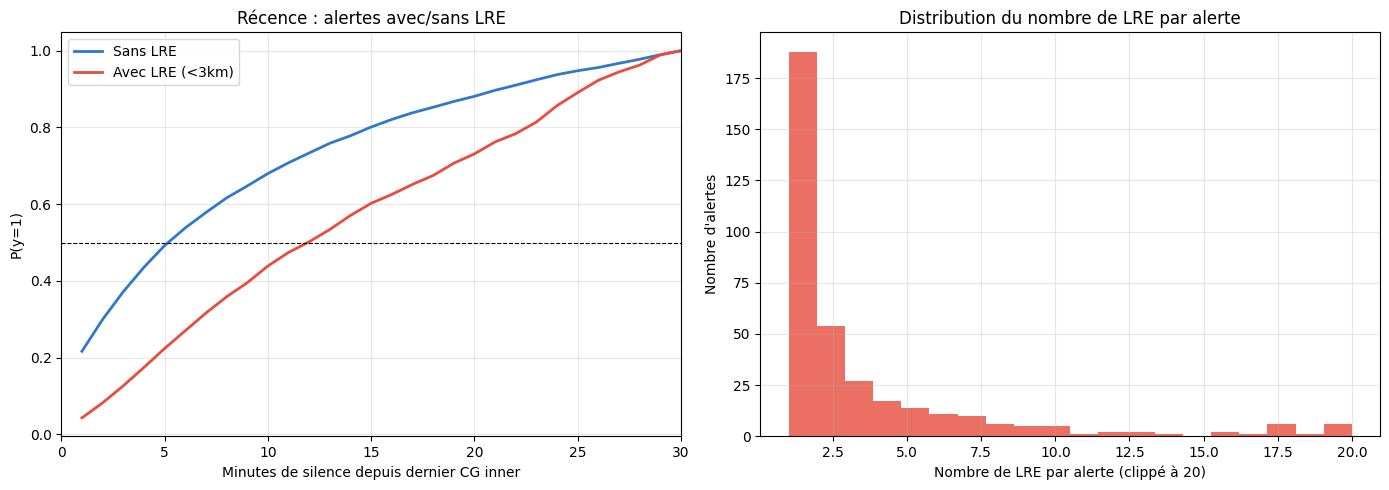

In [69]:
# %%
# Chunk 4 — Impact sur le silence dataset
# Parmi les instants y=0 dans le silence dataset,
# quelle proportion correspond à des cas où un LRE va survenir après ?

df["decision_time"] = pd.to_datetime(df["decision_time"], utc=True)

# Joindre les infos LRE au silence dataset
df = df.merge(
    lre_per_alert[["airport", "airport_alert_id", "n_lre", "has_lre"]],
    on=["airport", "airport_alert_id"],
    how="left"
)
df["has_lre"] = df["has_lre"].fillna(False)

print("=== Impact LRE sur le silence dataset ===\n")

# P(y=1) selon présence de LRE dans l'alerte
print("P(y=1) selon présence de LRE :")
print(df.groupby("has_lre")["y"].agg(["mean", "count"]).round(3))

# Courbe P(y=1) vs silence selon LRE
df["min_since_cg"] = df["minutes_since_reference_cg"].round(0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for has_lre, label, color in [
    (False, "Sans LRE", "#3078c8"),
    (True,  "Avec LRE (<3km)", "#e74c3c"),
]:
    sub = df[df["has_lre"] == has_lre]
    curve = (
        sub.groupby("min_since_cg")["y"]
        .agg(["mean", "count"])
        .reset_index()
        .rename(columns={"mean": "p_y1", "count": "n"})
    )
    curve = curve[curve["n"] >= 30]
    axes[0].plot(curve["min_since_cg"], curve["p_y1"],
                 label=label, color=color, linewidth=2)

axes[0].axhline(0.5, color="black", linestyle="--", linewidth=0.8)
axes[0].set_xlim(0, 30)
axes[0].set_xlabel("Minutes de silence depuis dernier CG inner")
axes[0].set_ylabel("P(y=1)")
axes[0].set_title("Récence : alertes avec/sans LRE")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Seuils opérationnels
print("\n=== Seuils opérationnels selon présence LRE ===\n")
for has_lre, label in [(False, "Sans LRE"), (True, "Avec LRE")]:
    sub = df[df["has_lre"] == has_lre]
    curve = (
        sub.groupby("min_since_cg")["y"]
        .agg(["mean", "count"])
        .reset_index()
        .rename(columns={"mean": "p_y1", "count": "n"})
    )
    curve = curve[curve["n"] >= 30]
    for seuil in [0.5, 0.8]:
        above = curve[curve["p_y1"] >= seuil]
        if len(above) > 0:
            t = above["min_since_cg"].iloc[0]
            print(f"{label} — P(y=1) > {seuil} atteint à : {t} min")
    print()

# Distribution n_lre
axes[1].hist(
    lre_per_alert[lre_per_alert["n_lre"] > 0]["n_lre"].clip(upper=20),
    bins=20, color="#e74c3c", alpha=0.8
)
axes[1].set_xlabel("Nombre de LRE par alerte (clippé à 20)")
axes[1].set_ylabel("Nombre d'alertes")
axes[1].set_title("Distribution du nombre de LRE par alerte")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "/home/onyxia/work/Dataverse/Dataverse/output/lre_analysis.png",
    dpi=130, bbox_inches="tight"
)
plt.show()

In [70]:
# %%
# Quand survient le premier LRE dans une alerte ?
# Début, milieu ou fin ?

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RAW_PATH = "/home/onyxia/work/Dataverse/Dataverse/data/segment_alerts_all_airports_train.csv"
df_raw = pd.read_csv(RAW_PATH)
df_raw["date"] = pd.to_datetime(df_raw["date"], utc=True)
df_raw["type"] = np.where(df_raw["icloud"].fillna(False), "IC", "CG")
df_raw["zone"] = np.where(df_raw["dist"] < 20, "inner", "outer")

LRE_DIST = 3.0

# Pour chaque alerte avec LRE, calculer la position relative du premier LRE
# position = (t_premier_LRE - t_debut_alerte) / duree_alerte
# 0 = début, 0.5 = milieu, 1 = fin

alerts = df_raw[df_raw["airport_alert_id"].notna()].copy()

timing_rows = []

for (airport, alert_id), group in alerts.groupby(["airport", "airport_alert_id"]):
    group = group.sort_values("date").reset_index(drop=True)

    lre = group[group["dist"] < LRE_DIST]
    if len(lre) == 0:
        continue

    t_debut = group["date"].iloc[0]
    t_fin = group["date"].iloc[-1]
    duree = (t_fin - t_debut).total_seconds() / 60.0

    if duree == 0:
        continue

    t_premier_lre = lre["date"].iloc[0]
    t_dernier_lre = lre["date"].iloc[-1]

    # Position relative entre 0 et 1
    pos_premier = (t_premier_lre - t_debut).total_seconds() / 60.0 / duree
    pos_dernier = (t_dernier_lre - t_debut).total_seconds() / 60.0 / duree

    # Temps avant le premier LRE depuis le début (en minutes)
    delai_premier_lre = (t_premier_lre - t_debut).total_seconds() / 60.0

    # Temps restant après le dernier LRE jusqu'à la fin (en minutes)
    temps_apres_dernier_lre = (t_fin - t_dernier_lre).total_seconds() / 60.0

    timing_rows.append({
        "airport": airport,
        "airport_alert_id": alert_id,
        "duree_alerte_min": duree,
        "n_lre": len(lre),
        "pos_premier_lre": pos_premier,
        "pos_dernier_lre": pos_dernier,
        "delai_premier_lre_min": delai_premier_lre,
        "temps_apres_dernier_lre_min": temps_apres_dernier_lre,
    })

timing_df = pd.DataFrame(timing_rows)
print(f"Alertes avec LRE analysées : {len(timing_df)}")

Alertes avec LRE analysées : 343


In [71]:
# %%
# Stats sur la position du premier LRE

print("=== Position relative du premier LRE (0=début, 1=fin) ===\n")
print(timing_df["pos_premier_lre"].describe().round(3))

print("\n=== Délai avant le premier LRE depuis le début de l'alerte ===\n")
print(timing_df["delai_premier_lre_min"].describe().round(2))

print("\n=== Temps restant après le DERNIER LRE ===\n")
print(timing_df["temps_apres_dernier_lre_min"].describe().round(2))

# Catégoriser : début / milieu / fin
timing_df["phase_premier_lre"] = pd.cut(
    timing_df["pos_premier_lre"],
    bins=[0, 0.33, 0.66, 1.0],
    labels=["début (0-33%)", "milieu (33-66%)", "fin (66-100%)"],
    include_lowest=True
)

print("\n=== Dans quelle phase survient le premier LRE ? ===\n")
counts = timing_df["phase_premier_lre"].value_counts().sort_index()
for phase, n in counts.items():
    print(f"  {phase} : {n} alertes ({100*n/len(timing_df):.1f}%)")

=== Position relative du premier LRE (0=début, 1=fin) ===

count    343.000
mean       0.435
std        0.278
min        0.000
25%        0.223
50%        0.389
75%        0.633
max        1.000
Name: pos_premier_lre, dtype: float64

=== Délai avant le premier LRE depuis le début de l'alerte ===

count    343.00
mean      41.06
std       36.62
min        0.00
25%       15.44
50%       33.25
75%       54.33
max      278.02
Name: delai_premier_lre_min, dtype: float64

=== Temps restant après le DERNIER LRE ===

count    343.00
mean      44.74
std       45.31
min        0.00
25%       14.18
50%       31.80
75%       60.38
max      265.47
Name: temps_apres_dernier_lre_min, dtype: float64

=== Dans quelle phase survient le premier LRE ? ===

  début (0-33%) : 136 alertes (39.7%)
  milieu (33-66%) : 130 alertes (37.9%)
  fin (66-100%) : 77 alertes (22.4%)


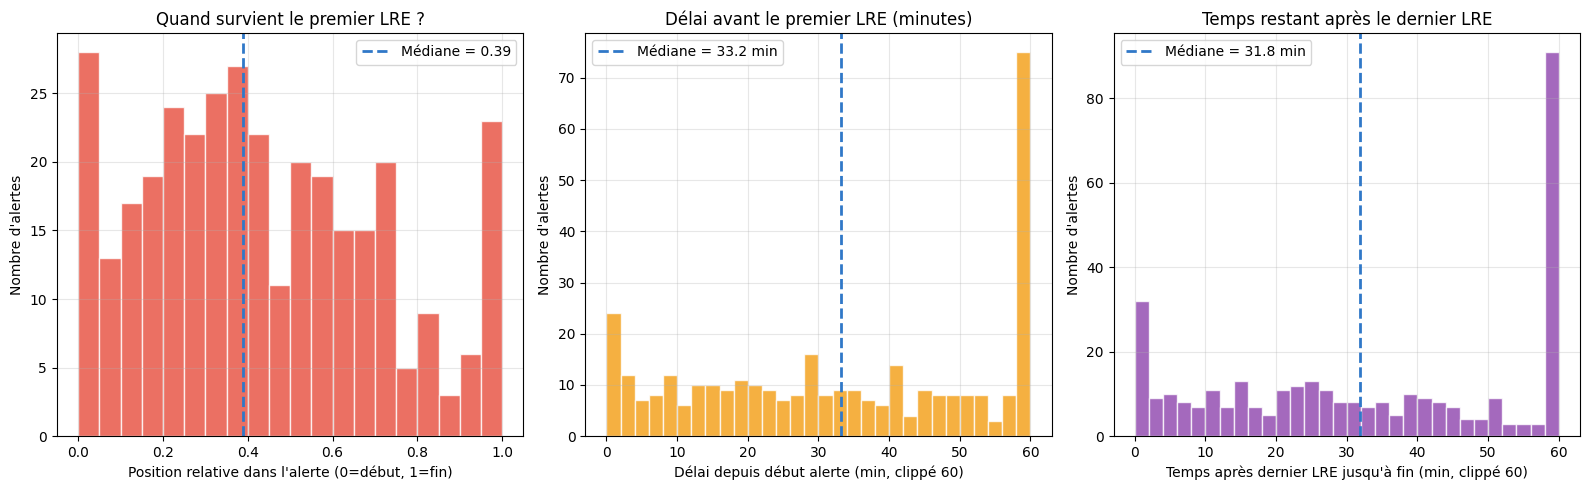

In [72]:
# %%
# Visualisation

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribution position relative du premier LRE
axes[0].hist(timing_df["pos_premier_lre"], bins=20,
             color="#e74c3c", alpha=0.8, edgecolor="white")
axes[0].axvline(timing_df["pos_premier_lre"].median(),
                color="#3078c8", linestyle="--", linewidth=2,
                label=f"Médiane = {timing_df['pos_premier_lre'].median():.2f}")
axes[0].set_xlabel("Position relative dans l'alerte (0=début, 1=fin)")
axes[0].set_ylabel("Nombre d'alertes")
axes[0].set_title("Quand survient le premier LRE ?")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Délai en minutes avant le premier LRE
axes[1].hist(timing_df["delai_premier_lre_min"].clip(upper=60),
             bins=30, color="#f39c12", alpha=0.8, edgecolor="white")
axes[1].axvline(timing_df["delai_premier_lre_min"].median(),
                color="#3078c8", linestyle="--", linewidth=2,
                label=f"Médiane = {timing_df['delai_premier_lre_min'].median():.1f} min")
axes[1].set_xlabel("Délai depuis début alerte (min, clippé 60)")
axes[1].set_ylabel("Nombre d'alertes")
axes[1].set_title("Délai avant le premier LRE (minutes)")
axes[1].legend()
axes[1].grid(alpha=0.3)

# Temps restant après le dernier LRE
axes[2].hist(timing_df["temps_apres_dernier_lre_min"].clip(upper=60),
             bins=30, color="#8e44ad", alpha=0.8, edgecolor="white")
axes[2].axvline(timing_df["temps_apres_dernier_lre_min"].median(),
                color="#3078c8", linestyle="--", linewidth=2,
                label=f"Médiane = {timing_df['temps_apres_dernier_lre_min'].median():.1f} min")
axes[2].set_xlabel("Temps après dernier LRE jusqu'à fin (min, clippé 60)")
axes[2].set_ylabel("Nombre d'alertes")
axes[2].set_title("Temps restant après le dernier LRE")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "/home/onyxia/work/Dataverse/Dataverse/output/lre_timing.png",
    dpi=130, bbox_inches="tight"
)
plt.show()

In [73]:
# %%
# Pour les LRE qui surviennent dans la 2ème moitié de l'alerte,
# combien sont précédés d'un autre LRE ?
# = est-ce qu'un LRE tardif est souvent un rebond isolé ou fait partie d'une série ?

import pandas as pd
import numpy as np

RAW_PATH = "/home/onyxia/work/Dataverse/Dataverse/data/segment_alerts_all_airports_train.csv"
df_raw = pd.read_csv(RAW_PATH)
df_raw["date"] = pd.to_datetime(df_raw["date"], utc=True)
df_raw["type"] = np.where(df_raw["icloud"].fillna(False), "IC", "CG")

LRE_DIST = 3.0

rows = []

for (airport, alert_id), group in df_raw[
    df_raw["airport_alert_id"].notna()
].groupby(["airport", "airport_alert_id"]):

    group = group.sort_values("date").reset_index(drop=True)
    lre = group[group["dist"] < LRE_DIST].reset_index(drop=True)

    if len(lre) == 0:
        continue

    t_debut = group["date"].iloc[0]
    t_fin = group["date"].iloc[-1]
    duree = (t_fin - t_debut).total_seconds() / 60.0

    if duree == 0:
        continue

    # Pour chaque LRE de l'alerte
    for i, lre_row in lre.iterrows():
        t_lre = lre_row["date"]
        pos = (t_lre - t_debut).total_seconds() / 60.0 / duree

        # Est-il dans la 2ème moitié ?
        in_second_half = pos >= 0.5

        # Y a-t-il un LRE précédent dans l'alerte ?
        has_previous_lre = i > 0

        # Si oui, quel est le délai depuis le LRE précédent ?
        if has_previous_lre:
            t_prev_lre = lre.iloc[i - 1]["date"]
            gap_since_prev_lre = (t_lre - t_prev_lre).total_seconds() / 60.0
        else:
            gap_since_prev_lre = np.nan

        rows.append({
            "airport": airport,
            "alert_id": alert_id,
            "pos_relative": round(pos, 3),
            "in_second_half": in_second_half,
            "has_previous_lre": has_previous_lre,
            "gap_since_prev_lre_min": gap_since_prev_lre,
            "lre_type": lre_row["type"],
            "lre_dist": lre_row["dist"],
        })

lre_df = pd.DataFrame(rows)

print(f"Total LRE analysés : {len(lre_df)}")
print(f"LRE en 2ème moitié : {lre_df['in_second_half'].sum()} "
      f"({100*lre_df['in_second_half'].mean():.1f}%)")

Total LRE analysés : 1237
LRE en 2ème moitié : 567 (45.8%)


In [74]:
# %%
# Résultats : LRE tardifs précédés ou non d'un autre LRE

lre_2nd = lre_df[lre_df["in_second_half"]].copy()

print("=== LRE dans la 2ème moitié de l'alerte ===\n")
print(f"Total                          : {len(lre_2nd)}")
print(f"Précédés d'un autre LRE        : {lre_2nd['has_previous_lre'].sum()} "
      f"({100*lre_2nd['has_previous_lre'].mean():.1f}%)")
print(f"Sans LRE précédent (rebond pur): {(~lre_2nd['has_previous_lre']).sum()} "
      f"({100*(~lre_2nd['has_previous_lre']).mean():.1f}%)")

print("\n=== Délai depuis le LRE précédent (pour ceux qui en ont un) ===\n")
print(lre_2nd[lre_2nd["has_previous_lre"]]["gap_since_prev_lre_min"].describe().round(2))

print("\n=== Délai par catégorie ===")
gaps = lre_2nd[lre_2nd["has_previous_lre"]]["gap_since_prev_lre_min"]
print(f"  < 5 min  (série continue)   : {(gaps < 5).sum()} ({100*(gaps<5).mean():.1f}%)")
print(f"  5-15 min (court délai)       : {((gaps>=5)&(gaps<15)).sum()} "
      f"({100*((gaps>=5)&(gaps<15)).mean():.1f}%)")
print(f"  15-30 min (délai moyen)      : {((gaps>=15)&(gaps<30)).sum()} "
      f"({100*((gaps>=15)&(gaps<30)).mean():.1f}%)")
print(f"  > 30 min (vrai rebond tardif): {(gaps>=30).sum()} "
      f"({100*(gaps>=30).mean():.1f}%)")

=== LRE dans la 2ème moitié de l'alerte ===

Total                          : 567
Précédés d'un autre LRE        : 432 (76.2%)
Sans LRE précédent (rebond pur): 135 (23.8%)

=== Délai depuis le LRE précédent (pour ceux qui en ont un) ===

count    432.00
mean       8.42
std       17.84
min        0.00
25%        0.82
50%        2.39
75%        7.70
max      202.02
Name: gap_since_prev_lre_min, dtype: float64

=== Délai par catégorie ===
  < 5 min  (série continue)   : 290 (67.1%)
  5-15 min (court délai)       : 77 (17.8%)
  15-30 min (délai moyen)      : 35 (8.1%)
  > 30 min (vrai rebond tardif): 30 (6.9%)


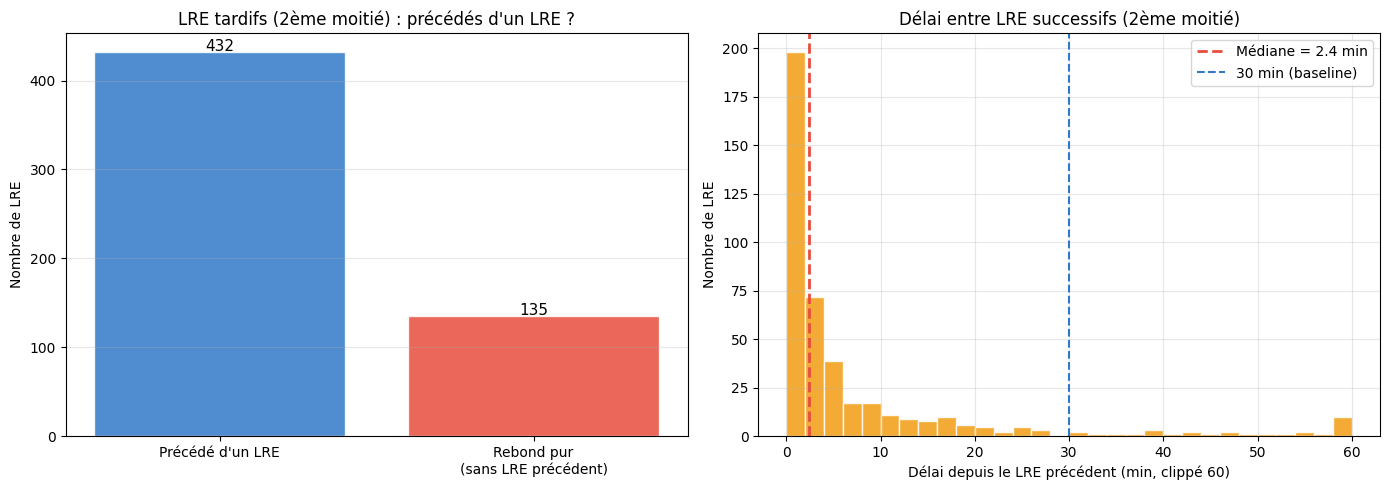

In [75]:
# %%
# Visualisation

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Proportion précédé/non précédé
labels = ["Précédé d'un LRE", "Rebond pur\n(sans LRE précédent)"]
vals = [
    lre_2nd["has_previous_lre"].sum(),
    (~lre_2nd["has_previous_lre"]).sum()
]
axes[0].bar(labels, vals, color=["#3078c8", "#e74c3c"], alpha=0.85,
            edgecolor="white")
for i, v in enumerate(vals):
    axes[0].text(i, v + 1, str(v), ha="center", fontsize=11, fontweight="500")
axes[0].set_title("LRE tardifs (2ème moitié) : précédés d'un LRE ?")
axes[0].set_ylabel("Nombre de LRE")
axes[0].grid(alpha=0.3, axis="y")

# Distribution du délai depuis le LRE précédent
gaps = lre_2nd[lre_2nd["has_previous_lre"]]["gap_since_prev_lre_min"].clip(upper=60)
axes[1].hist(gaps, bins=30, color="#f39c12", alpha=0.85, edgecolor="white")
axes[1].axvline(gaps.median(), color="#e74c3c", linestyle="--", linewidth=2,
                label=f"Médiane = {gaps.median():.1f} min")
axes[1].axvline(30, color="#3078c8", linestyle="--", linewidth=1.5,
                label="30 min (baseline)")
axes[1].set_xlabel("Délai depuis le LRE précédent (min, clippé 60)")
axes[1].set_ylabel("Nombre de LRE")
axes[1].set_title("Délai entre LRE successifs (2ème moitié)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "/home/onyxia/work/Dataverse/Dataverse/output/lre_rebonds_tardifs.png",
    dpi=130, bbox_inches="tight"
)
plt.show()

In [76]:
# %%
# Tout en un — caractérisation rebonds purs

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RAW_PATH = "/home/onyxia/work/Dataverse/Dataverse/data/segment_alerts_all_airports_train.csv"
LRE_DIST = 3.0

df_raw = pd.read_csv(RAW_PATH)
df_raw["date"] = pd.to_datetime(df_raw["date"], utc=True)
df_raw["type"] = np.where(df_raw["icloud"].fillna(False), "IC", "CG")
df_raw["zone"] = np.where(df_raw["dist"] < 20, "inner", "outer")

# Étape 1 : identifier les alertes avec rebond pur
rebond_pur_alerts = set()
for (airport, alert_id), group in df_raw[
    df_raw["airport_alert_id"].notna()
].groupby(["airport", "airport_alert_id"]):
    group = group.sort_values("date").reset_index(drop=True)
    lre = group[group["dist"] < LRE_DIST].reset_index(drop=True)
    if len(lre) == 0:
        continue
    t_debut = group["date"].iloc[0]
    t_fin = group["date"].iloc[-1]
    duree = (t_fin - t_debut).total_seconds() / 60.0
    if duree == 0:
        continue
    for i, lre_row in lre.iterrows():
        t_lre = lre_row["date"]
        pos = (t_lre - t_debut).total_seconds() / 60.0 / duree
        if pos >= 0.5 and i == 0:
            rebond_pur_alerts.add((airport, alert_id))
            break

print(f"Alertes avec rebond pur : {len(rebond_pur_alerts)}")

# Étape 2 : construire stats_df
alert_stats = []
for (airport, alert_id), group in df_raw[
    df_raw["airport_alert_id"].notna()
].groupby(["airport", "airport_alert_id"]):
    group = group.sort_values("date").reset_index(drop=True)
    cg_inner = group[(group["type"] == "CG") & (group["zone"] == "inner")]
    lre = group[group["dist"] < LRE_DIST]
    t_debut = group["date"].iloc[0]
    t_fin = group["date"].iloc[-1]
    duree = (t_fin - t_debut).total_seconds() / 60.0

    if (airport, alert_id) in rebond_pur_alerts:
        categorie = "rebond pur"
    elif len(lre) > 0:
        categorie = "LRE normal"
    else:
        categorie = "sans LRE"

    alert_stats.append({
        "airport": airport,
        "alert_id": alert_id,
        "categorie": categorie,
        "duree_min": duree,
        "n_cg_inner": len(cg_inner),
        "n_lre": len(lre),
        "dist_min": group["dist"].min(),
        "n_total": len(group),
        "mois": group["date"].iloc[0].month,
        "heure": group["date"].iloc[0].hour,
    })

stats_df = pd.DataFrame(alert_stats)

# Étape 3 : afficher les résultats
print("\n=== Profil des alertes selon catégorie ===\n")
print(stats_df.groupby("categorie")[
    ["duree_min", "n_cg_inner", "dist_min", "n_total"]
].agg(["mean", "median"]).round(2).to_string())

print("\n=== Mois des alertes avec rebond pur ===\n")
mois_labels = {1:"Jan",2:"Fév",3:"Mar",4:"Avr",5:"Mai",6:"Jun",
               7:"Jul",8:"Aoû",9:"Sep",10:"Oct",11:"Nov",12:"Déc"}
for cat in ["rebond pur", "LRE normal", "sans LRE"]:
    sub = stats_df[stats_df["categorie"] == cat]
    mois_dist = sub["mois"].value_counts().sort_index()
    top3 = mois_dist.nlargest(3).index.map(mois_labels).tolist()
    print(f"{cat:15} → top 3 mois : {top3}")

print("\n=== Heure de début ===\n")
for cat in ["rebond pur", "LRE normal", "sans LRE"]:
    sub = stats_df[stats_df["categorie"] == cat]
    heure_med = sub["heure"].median()
    print(f"{cat:15} → heure médiane : {heure_med:.0f}h UTC")

Alertes avec rebond pur : 135

=== Profil des alertes selon catégorie ===

           duree_min        n_cg_inner        dist_min        n_total       
                mean median       mean median     mean median    mean median
categorie                                                                   
LRE normal    105.04  85.33     140.27   60.0     1.55   1.46  140.27   60.0
rebond pur     88.24  73.80      65.96   37.0     1.72   1.69   65.96   37.0
sans LRE       19.01   4.57       7.18    2.0    12.35  12.90    7.18    2.0

=== Mois des alertes avec rebond pur ===

rebond pur      → top 3 mois : ['Aoû', 'Jun', 'Mai']
LRE normal      → top 3 mois : ['Aoû', 'Sep', 'Jul']
sans LRE        → top 3 mois : ['Sep', 'Nov', 'Aoû']

=== Heure de début ===

rebond pur      → heure médiane : 12h UTC
LRE normal      → heure médiane : 11h UTC
sans LRE        → heure médiane : 12h UTC


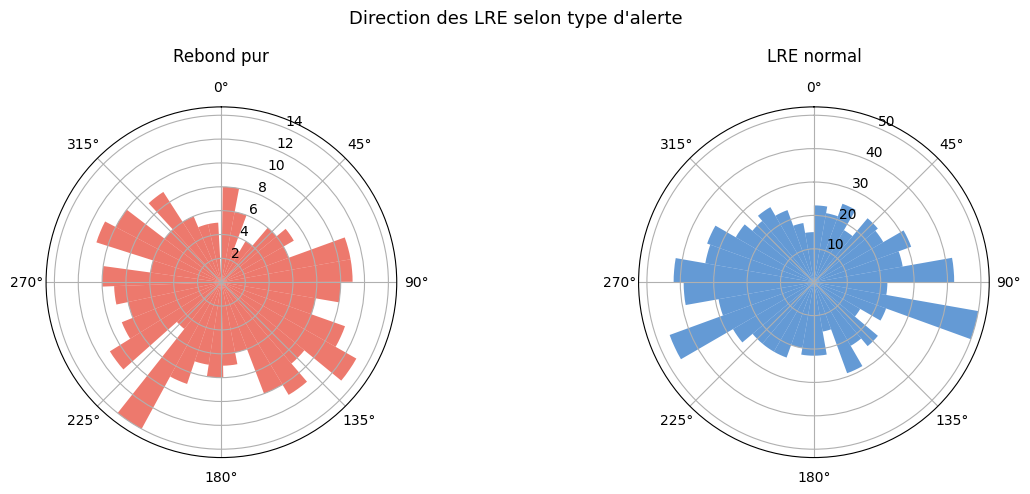

In [77]:
# %%
# Direction (azimuth) des rebonds purs
# Est-ce que les LRE très proches viennent d'un secteur particulier ?

import numpy as np
import matplotlib.pyplot as plt

rebond_azimuths = []
normal_azimuths = []

for (airport, alert_id), group in df_raw[
    df_raw["airport_alert_id"].notna()
].groupby(["airport", "airport_alert_id"]):
    lre = group[group["dist"] < LRE_DIST]
    if len(lre) == 0:
        continue
    if (airport, alert_id) in rebond_pur_alerts:
        rebond_azimuths.extend(lre["azimuth"].dropna().tolist())
    else:
        normal_azimuths.extend(lre["azimuth"].dropna().tolist())

fig, axes = plt.subplots(1, 2, figsize=(12, 5),
                         subplot_kw=dict(projection="polar"))

for ax, azimuths, label, color in [
    (axes[0], rebond_azimuths, "Rebond pur", "#e74c3c"),
    (axes[1], normal_azimuths, "LRE normal", "#3078c8"),
]:
    rad = np.radians(azimuths)
    ax.hist(rad, bins=36, color=color, alpha=0.75)
    ax.set_title(label, pad=14)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

plt.suptitle("Direction des LRE selon type d'alerte", fontsize=13)
plt.tight_layout()
plt.show()

In [78]:
# %%
# Est-ce que les rebonds purs sont précédés d'éclairs qui s'approchent ?
# On regarde la tendance de dist dans les 10 et 20 minutes avant le rebond pur

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

RAW_PATH = "/home/onyxia/work/Dataverse/Dataverse/data/segment_alerts_all_airports_train.csv"
LRE_DIST = 3.0

df_raw = pd.read_csv(RAW_PATH)
df_raw["date"] = pd.to_datetime(df_raw["date"], utc=True)
df_raw["type"] = np.where(df_raw["icloud"].fillna(False), "IC", "CG")
df_raw["zone"] = np.where(df_raw["dist"] < 20, "inner", "outer")

# Reconstruire rebond_pur_alerts si pas en mémoire
rebond_pur_alerts = set()
for (airport, alert_id), group in df_raw[
    df_raw["airport_alert_id"].notna()
].groupby(["airport", "airport_alert_id"]):
    group = group.sort_values("date").reset_index(drop=True)
    lre = group[group["dist"] < LRE_DIST].reset_index(drop=True)
    if len(lre) == 0:
        continue
    t_debut = group["date"].iloc[0]
    t_fin = group["date"].iloc[-1]
    duree = (t_fin - t_debut).total_seconds() / 60.0
    if duree == 0:
        continue
    for i, lre_row in lre.iterrows():
        t_lre = lre_row["date"]
        pos = (t_lre - t_debut).total_seconds() / 60.0 / duree
        if pos >= 0.5 and i == 0:
            rebond_pur_alerts.add((airport, alert_id))
            break

print(f"Rebond pur alerts : {len(rebond_pur_alerts)}")

Rebond pur alerts : 135


In [79]:
# %%
# Pour chaque rebond pur, calculer la tendance de dist
# dans les 10 et 20 minutes qui précèdent

from scipy import stats

approach_rows = []

for (airport, alert_id), group in df_raw[
    df_raw["airport_alert_id"].notna()
].groupby(["airport", "airport_alert_id"]):

    if (airport, alert_id) not in rebond_pur_alerts:
        continue

    group = group.sort_values("date").reset_index(drop=True)
    lre = group[group["dist"] < LRE_DIST].reset_index(drop=True)

    t_debut = group["date"].iloc[0]
    t_fin = group["date"].iloc[-1]
    duree = (t_fin - t_debut).total_seconds() / 60.0

    for i, lre_row in lre.iterrows():
        t_lre = lre_row["date"]
        pos = (t_lre - t_debut).total_seconds() / 60.0 / duree
        if pos >= 0.5 and i == 0:

            for window_min in [5, 10, 20]:
                w_start = t_lre - pd.Timedelta(minutes=window_min)
                before = group[
                    (group["date"] >= w_start) &
                    (group["date"] < t_lre)
                ].copy()

                if len(before) < 3:
                    approach_rows.append({
                        "airport": airport,
                        "alert_id": alert_id,
                        "window_min": window_min,
                        "n_events": len(before),
                        "slope_dist": np.nan,
                        "dist_min_before": np.nan,
                        "dist_mean_before": np.nan,
                        "pct_ic": np.nan,
                    })
                    continue

                t_seconds = (
                    before["date"] - before["date"].iloc[0]
                ).dt.total_seconds()

                # Cas où tous les timestamps sont identiques
                if t_seconds.nunique() < 2:
                    approach_rows.append({
                        "airport": airport,
                        "alert_id": alert_id,
                        "window_min": window_min,
                        "n_events": len(before),
                        "slope_dist": np.nan,
                        "dist_min_before": before["dist"].min(),
                        "dist_mean_before": before["dist"].mean(),
                        "pct_ic": (before["type"] == "IC").mean(),
                    })
                    continue

                slope, intercept, r, p, se = stats.linregress(
                    t_seconds, before["dist"]
                )

                approach_rows.append({
                    "airport": airport,
                    "alert_id": alert_id,
                    "window_min": window_min,
                    "n_events": len(before),
                    "slope_dist": slope,
                    "dist_min_before": before["dist"].min(),
                    "dist_mean_before": before["dist"].mean(),
                    "pct_ic": (before["type"] == "IC").mean(),
                })
            break

approach_df = pd.DataFrame(approach_rows)
print(f"Rebonds analysés : {approach_df['alert_id'].nunique()}")

Rebonds analysés : 124


In [80]:
# %%
# Résultats : tendance de dist avant le rebond

print("=== Tendance de la distance avant le rebond pur ===\n")

for w in [5, 10, 20]:
    sub = approach_df[
        (approach_df["window_min"] == w) &
        approach_df["slope_dist"].notna()
    ]
    if len(sub) == 0:
        print(f"Fenêtre {w:2d} min : pas assez de données\n")
        continue

    n_approach = (sub["slope_dist"] < 0).sum()
    n_recul    = (sub["slope_dist"] > 0).sum()
    print(f"Fenêtre {w:2d} min ({len(sub)} rebonds) :")
    print(f"  Éclairs qui s'approchent (slope < 0) : "
          f"{n_approach} ({100*n_approach/len(sub):.1f}%)")
    print(f"  Éclairs qui s'éloignent  (slope > 0) : "
          f"{n_recul} ({100*n_recul/len(sub):.1f}%)")
    print(f"  Slope médiane            : {sub['slope_dist'].median():.5f} km/s")
    print(f"  dist_min médiane avant   : {sub['dist_min_before'].median():.2f} km")
    print(f"  % IC avant rebond        : {sub['pct_ic'].median()*100:.1f}%")
    print()

=== Tendance de la distance avant le rebond pur ===

Fenêtre  5 min (62 rebonds) :
  Éclairs qui s'approchent (slope < 0) : 28 (45.2%)
  Éclairs qui s'éloignent  (slope > 0) : 34 (54.8%)
  Slope médiane            : 0.00103 km/s
  dist_min médiane avant   : 6.05 km
  % IC avant rebond        : 0.0%

Fenêtre 10 min (88 rebonds) :
  Éclairs qui s'approchent (slope < 0) : 53 (60.2%)
  Éclairs qui s'éloignent  (slope > 0) : 35 (39.8%)
  Slope médiane            : -0.00193 km/s
  dist_min médiane avant   : 5.52 km
  % IC avant rebond        : 0.0%

Fenêtre 20 min (109 rebonds) :
  Éclairs qui s'approchent (slope < 0) : 73 (67.0%)
  Éclairs qui s'éloignent  (slope > 0) : 36 (33.0%)
  Slope médiane            : -0.00269 km/s
  dist_min médiane avant   : 5.21 km
  % IC avant rebond        : 0.0%



In [81]:
# %%
# Les 33% qui s'éloignent avant le rebond — passage brusque ou lointain ?
# On regarde la dist_min et dist_mean juste avant le rebond
# pour ces cas "slope > 0" sur 20 min

sub_20 = approach_df[
    (approach_df["window_min"] == 20) &
    approach_df["slope_dist"].notna()
].copy()

sub_eloigne = sub_20[sub_20["slope_dist"] > 0]
sub_approche = sub_20[sub_20["slope_dist"] < 0]

print("=== Profil des rebonds selon la tendance (fenêtre 20 min) ===\n")
print(f"{'':30} {'S approche':>12} {'S éloigne':>12}")
print("-" * 56)

for col, label in [
    ("dist_min_before",  "dist_min avant (km)"),
    ("dist_mean_before", "dist_mean avant (km)"),
    ("n_events",         "nb éclairs avant"),
]:
    v1 = sub_approche[col].median()
    v2 = sub_eloigne[col].median()
    print(f"{label:30} {v1:>12.2f} {v2:>12.2f}")

print()
print("=== dist_min avant le rebond — s'éloigne ===\n")
print(sub_eloigne["dist_min_before"].describe().round(2))

print("\n=== Interprétation ===")
pct_loin = (sub_eloigne["dist_min_before"] > 10).sum()
pct_proche = (sub_eloigne["dist_min_before"] <= 10).sum()
print(f"dist_min > 10 km (loin)    : {pct_loin} ({100*pct_loin/len(sub_eloigne):.1f}%)")
print(f"dist_min <= 10 km (proche) : {pct_proche} ({100*pct_proche/len(sub_eloigne):.1f}%)")
print(f"\n→ Si dist_min > 10 km ET slope > 0 : rebond vraiment brusque depuis loin")
print(f"→ Si dist_min <= 10 km ET slope > 0 : oscillation locale autour de 5-10 km")

=== Profil des rebonds selon la tendance (fenêtre 20 min) ===

                                 S approche    S éloigne
--------------------------------------------------------
dist_min avant (km)                    4.91         6.16
dist_mean avant (km)                  11.50        13.26
nb éclairs avant                      11.00        11.00

=== dist_min avant le rebond — s'éloigne ===

count    36.00
mean      7.08
std       3.35
min       3.00
25%       4.59
50%       6.16
75%       9.43
max      15.59
Name: dist_min_before, dtype: float64

=== Interprétation ===
dist_min > 10 km (loin)    : 5 (13.9%)
dist_min <= 10 km (proche) : 31 (86.1%)

→ Si dist_min > 10 km ET slope > 0 : rebond vraiment brusque depuis loin
→ Si dist_min <= 10 km ET slope > 0 : oscillation locale autour de 5-10 km


In [82]:
# %%
# Intensité des orages avec rebonds purs
# On regarde l'amplitude des éclairs avant le rebond
# et compare avec les autres catégories

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=== Intensité des orages selon catégorie ===\n")

intensity_rows = []

for (airport, alert_id), group in df_raw[
    df_raw["airport_alert_id"].notna()
].groupby(["airport", "airport_alert_id"]):

    group = group.sort_values("date").reset_index(drop=True)
    lre = group[group["dist"] < LRE_DIST]
    cg_inner = group[
        (group["type"] == "CG") & (group["zone"] == "inner")
    ]

    if (airport, alert_id) in rebond_pur_alerts:
        categorie = "rebond pur"
    elif len(lre) > 0:
        categorie = "LRE normal"
    else:
        categorie = "sans LRE"

    intensity_rows.append({
        "airport": airport,
        "alert_id": alert_id,
        "categorie": categorie,
        # Amplitude absolue moyenne de tous les éclairs
        "amp_abs_mean": group["amplitude"].abs().mean(),
        # Amplitude absolue max
        "amp_abs_max": group["amplitude"].abs().max(),
        # Amplitude des CG inner uniquement
        "amp_cg_inner_mean": cg_inner["amplitude"].abs().mean()
            if len(cg_inner) > 0 else np.nan,
        # maxis moyen (indicateur d'intensité Meteorage)
        "maxis_mean": group["maxis"].mean(),
        "maxis_max": group["maxis"].max(),
        # Nombre de CG inner
        "n_cg_inner": len(cg_inner),
        # Durée
        "duree_min": (group["date"].iloc[-1] - group["date"].iloc[0]
                      ).total_seconds() / 60.0,
    })

intensity_df = pd.DataFrame(intensity_rows)

print(intensity_df.groupby("categorie")[
    ["amp_abs_mean", "amp_abs_max", "amp_cg_inner_mean",
     "maxis_mean", "maxis_max", "n_cg_inner"]
].agg(["mean", "median"]).round(2).to_string())

=== Intensité des orages selon catégorie ===

           amp_abs_mean        amp_abs_max        amp_cg_inner_mean        maxis_mean        maxis_max        n_cg_inner       
                   mean median        mean median              mean median       mean median      mean median       mean median
categorie                                                                                                                      
LRE normal        26.42  19.14      111.30  92.01             26.42  19.14       0.60   0.43      3.28   4.11     140.27   60.0
rebond pur        26.44  19.10      104.63  86.74             26.44  19.10       0.57   0.38      3.13   3.57      65.96   37.0
sans LRE          32.27  19.92       56.03  30.76             32.27  19.92       0.64   0.19      1.28   0.36       7.18    2.0


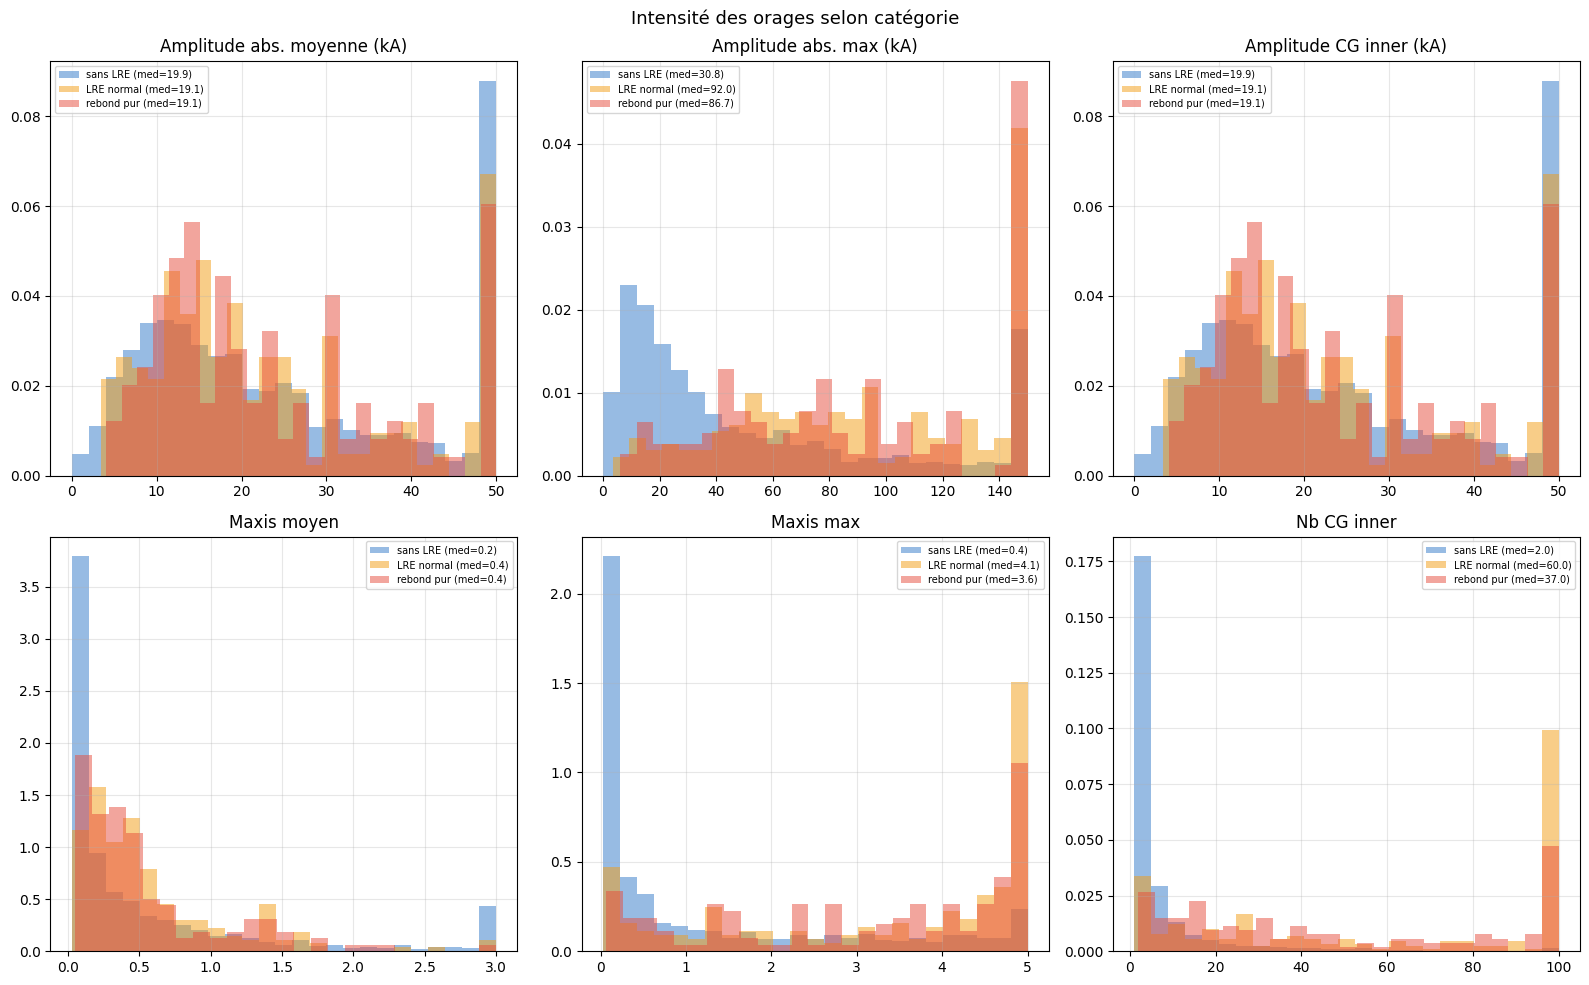

In [83]:
# %%
# Visualisation intensité

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

cats = ["sans LRE", "LRE normal", "rebond pur"]
colors = ["#3078c8", "#f39c12", "#e74c3c"]

variables = [
    ("amp_abs_mean",      "Amplitude abs. moyenne (kA)", 50),
    ("amp_abs_max",       "Amplitude abs. max (kA)",     150),
    ("amp_cg_inner_mean", "Amplitude CG inner (kA)",     50),
    ("maxis_mean",        "Maxis moyen",                 3),
    ("maxis_max",         "Maxis max",                   5),
    ("n_cg_inner",        "Nb CG inner",                 100),
]

for idx, (var, label, clip_val) in enumerate(variables):
    row, col = idx // 3, idx % 3
    for cat, color in zip(cats, colors):
        data = intensity_df[
            intensity_df["categorie"] == cat
        ][var].dropna().clip(upper=clip_val)
        axes[row][col].hist(
            data, bins=25, alpha=0.5,
            label=f"{cat} (med={data.median():.1f})",
            color=color, density=True
        )
    axes[row][col].set_title(label)
    axes[row][col].legend(fontsize=7)
    axes[row][col].grid(alpha=0.3)

plt.suptitle("Intensité des orages selon catégorie", fontsize=13)
plt.tight_layout()
plt.savefig(
    "/home/onyxia/work/Dataverse/Dataverse/output/lre_intensite.png",
    dpi=130, bbox_inches="tight"
)
plt.show()

In [84]:
# %%
# Conclusion intensité

print("=== Résumé intensité — médiane par catégorie ===\n")
print(f"{'':25} {'sans LRE':>10} {'LRE normal':>12} {'rebond pur':>12}")
print("-" * 62)

for var, label in [
    ("amp_abs_mean",      "Amplitude moy (kA)"),
    ("amp_abs_max",       "Amplitude max (kA)"),
    ("maxis_mean",        "Maxis moyen"),
    ("n_cg_inner",        "Nb CG inner"),
    ("duree_min",         "Durée (min)"),
]:
    vals = []
    for cat in ["sans LRE", "LRE normal", "rebond pur"]:
        v = intensity_df[intensity_df["categorie"]==cat][var].median()
        vals.append(v)
    print(f"{label:25} {vals[0]:>10.1f} {vals[1]:>12.1f} {vals[2]:>12.1f}")

=== Résumé intensité — médiane par catégorie ===

                            sans LRE   LRE normal   rebond pur
--------------------------------------------------------------
Amplitude moy (kA)              19.9         19.1         19.1
Amplitude max (kA)              30.8         92.0         86.7
Maxis moyen                      0.2          0.4          0.4
Nb CG inner                      2.0         60.0         37.0
Durée (min)                      4.6         85.3         73.8


In [85]:
# %%
# Est-ce que les rebonds purs pourraient être un 2ème orage distinct ?
# Critère : gap temporel entre le dernier éclair avant le rebond
# et le rebond lui-même — si gap > 30 min, probablement un 2ème orage

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

gap_rows = []

for (airport, alert_id), group in df_raw[
    df_raw["airport_alert_id"].notna()
].groupby(["airport", "airport_alert_id"]):

    if (airport, alert_id) not in rebond_pur_alerts:
        continue

    group = group.sort_values("date").reset_index(drop=True)
    lre = group[group["dist"] < LRE_DIST].reset_index(drop=True)

    t_debut = group["date"].iloc[0]
    t_fin = group["date"].iloc[-1]
    duree = (t_fin - t_debut).total_seconds() / 60.0
    if duree == 0:
        continue

    for i, lre_row in lre.iterrows():
        t_lre = lre_row["date"]
        pos = (t_lre - t_debut).total_seconds() / 60.0 / duree
        if pos >= 0.5 and i == 0:
            # Dernier éclair avant ce LRE (tous types)
            before_all = group[group["date"] < t_lre]
            if len(before_all) == 0:
                break

            t_last_before = before_all["date"].iloc[-1]
            gap_min = (t_lre - t_last_before).total_seconds() / 60.0

            # Dernier CG inner avant ce LRE
            cg_inner_before = group[
                (group["date"] < t_lre) &
                (group["type"] == "CG") &
                (group["zone"] == "inner")
            ]
            gap_cg_inner = (
                (t_lre - cg_inner_before["date"].iloc[-1]
                 ).total_seconds() / 60.0
                if len(cg_inner_before) > 0 else np.nan
            )

            gap_rows.append({
                "airport": airport,
                "alert_id": alert_id,
                "duree_alerte_min": duree,
                "t_lre": t_lre,
                "gap_depuis_dernier_eclair_min": gap_min,
                "gap_depuis_dernier_cg_inner_min": gap_cg_inner,
                "lre_dist": lre_row["dist"],
            })
            break

gap_df = pd.DataFrame(gap_rows)

print("=== Gap depuis le dernier éclair avant le rebond pur ===\n")
print(gap_df["gap_depuis_dernier_eclair_min"].describe().round(2))

print("\n=== Gap depuis le dernier CG inner avant le rebond pur ===\n")
print(gap_df["gap_depuis_dernier_cg_inner_min"].describe().round(2))

print("\n=== Peut-être un 2ème orage ? (gap > 30 min) ===")
seuils = [10, 20, 30, 45, 60]
for s in seuils:
    n = (gap_df["gap_depuis_dernier_eclair_min"] > s).sum()
    print(f"  Gap > {s:2d} min : {n} rebonds ({100*n/len(gap_df):.1f}%)")

=== Gap depuis le dernier éclair avant le rebond pur ===

count    135.00
mean       4.04
std        5.67
min        0.02
25%        0.57
50%        1.55
75%        4.59
max       26.48
Name: gap_depuis_dernier_eclair_min, dtype: float64

=== Gap depuis le dernier CG inner avant le rebond pur ===

count    135.00
mean       4.04
std        5.67
min        0.02
25%        0.57
50%        1.55
75%        4.59
max       26.48
Name: gap_depuis_dernier_cg_inner_min, dtype: float64

=== Peut-être un 2ème orage ? (gap > 30 min) ===
  Gap > 10 min : 18 rebonds (13.3%)
  Gap > 20 min : 2 rebonds (1.5%)
  Gap > 30 min : 0 rebonds (0.0%)
  Gap > 45 min : 0 rebonds (0.0%)
  Gap > 60 min : 0 rebonds (0.0%)


In [86]:
# %%
# Visualiser ces alertes — timeline des éclairs pour les cas
# avec grand gap (probable 2ème orage)

GRAND_GAP = 30  # minutes

cas_2eme_orage = gap_df[
    gap_df["gap_depuis_dernier_eclair_min"] > GRAND_GAP
]["alert_id"].values

print(f"Alertes avec probable 2ème orage (gap > {GRAND_GAP} min) : "
      f"{len(cas_2eme_orage)}")

# Visualiser les 6 premiers
n_plot = min(6, len(cas_2eme_orage))
fig, axes = plt.subplots(n_plot, 1, figsize=(14, 3 * n_plot))
if n_plot == 1:
    axes = [axes]

for ax, alert_id in zip(axes, cas_2eme_orage[:n_plot]):
    # Trouver l'aéroport
    airport = gap_df[gap_df["alert_id"] == alert_id]["airport"].iloc[0]
    group = df_raw[
        (df_raw["airport_alert_id"] == alert_id) &
        (df_raw["airport"] == airport)
    ].sort_values("date")

    # Timeline : scatter dist vs time, coloré par type
    t0 = group["date"].iloc[0]
    t_min = (group["date"] - t0).dt.total_seconds() / 60.0

    cg = group[group["type"] == "CG"]
    ic = group[group["type"] == "IC"]
    lre = group[group["dist"] < LRE_DIST]

    t_cg = (cg["date"] - t0).dt.total_seconds() / 60.0
    t_ic = (ic["date"] - t0).dt.total_seconds() / 60.0
    t_lre = (lre["date"] - t0).dt.total_seconds() / 60.0

    ax.scatter(t_cg, cg["dist"], color="#3078c8", s=15,
               alpha=0.6, label="CG")
    ax.scatter(t_ic, ic["dist"], color="#888780", s=8,
               alpha=0.4, label="IC")
    ax.scatter(t_lre, lre["dist"], color="#e74c3c", s=60,
               zorder=5, label="LRE (<3km)", marker="*")

    ax.axhline(3, color="#e74c3c", linestyle="--",
               linewidth=0.8, alpha=0.5)
    ax.axhline(20, color="#f39c12", linestyle="--",
               linewidth=0.8, alpha=0.5)
    ax.set_ylabel("Distance (km)")
    ax.set_xlabel("Minutes depuis début alerte")
    ax.set_title(f"Alerte {alert_id} — {airport} "
                 f"(durée {gap_df[gap_df['alert_id']==alert_id]['duree_alerte_min'].values[0]:.0f} min)")
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 31)

plt.suptitle(f"Alertes avec probable 2ème orage (gap > {GRAND_GAP} min)",
             fontsize=13)
plt.tight_layout()
plt.savefig(
    "/home/onyxia/work/Dataverse/Dataverse/output/lre_2eme_orage.png",
    dpi=130, bbox_inches="tight"
)
plt.show()

Alertes avec probable 2ème orage (gap > 30 min) : 0


ValueError: Number of rows must be a positive integer, not 0

<Figure size 1400x0 with 0 Axes>

In [87]:
# %%
# Rebonds purs avec le plus grand gap — les plus "surprenants"

print("=== Top 10 rebonds purs avec le plus grand gap ===\n")
print(gap_df.sort_values("gap_depuis_dernier_eclair_min", ascending=False).head(10)[
    ["airport", "alert_id", "duree_alerte_min",
     "gap_depuis_dernier_eclair_min",
     "gap_depuis_dernier_cg_inner_min",
     "lre_dist"]
].to_string())

=== Top 10 rebonds purs avec le plus grand gap ===

      airport  alert_id  duree_alerte_min  gap_depuis_dernier_eclair_min  gap_depuis_dernier_cg_inner_min  lre_dist
91     Nantes     130.0         48.116667                      26.483333                        26.483333  2.328878
73   Biarritz     320.0         41.833333                      22.983333                        22.983333  1.207946
2     Ajaccio      98.0         26.333333                      19.616667                        19.616667  2.092269
105      Pise     319.0         64.716667                      19.500000                        19.500000  1.188552
20    Ajaccio     359.0         50.966667                      18.666667                        18.666667  2.026701
47     Bastia     456.0         22.100000                      18.300000                        18.300000  1.508028
64   Biarritz     193.0         24.650000                      17.616667                        17.616667  1.343044
56   Biarritz      9

In [88]:
# %%
# Caractérisation des rebonds purs avec grand gap vs petit gap

GRAND_GAP = 10  # seuil pour séparer surprenant vs normal

gap_df["categorie_gap"] = np.where(
    gap_df["gap_depuis_dernier_eclair_min"] > GRAND_GAP,
    "grand gap (>10 min)",
    "petit gap (<= 10 min)"
)

print(f"Grand gap (> {GRAND_GAP} min) : {(gap_df['gap_depuis_dernier_eclair_min'] > GRAND_GAP).sum()}")
print(f"Petit gap (<= {GRAND_GAP} min) : {(gap_df['gap_depuis_dernier_eclair_min'] <= GRAND_GAP).sum()}")

# Joindre avec les stats d'intensité
merged = gap_df.merge(
    intensity_df[["airport", "alert_id",
                  "amp_abs_mean", "amp_abs_max",
                  "maxis_mean", "maxis_max",
                  "n_cg_inner", "duree_min"]],
    on=["airport", "alert_id"], how="left"
)

print("\n=== Profil grand gap vs petit gap ===\n")
print(merged.groupby("categorie_gap")[
    ["duree_alerte_min", "n_cg_inner",
     "amp_abs_mean", "amp_abs_max",
     "maxis_max"]
].agg(["mean", "median"]).round(2).to_string())

Grand gap (> 10 min) : 18
Petit gap (<= 10 min) : 117

=== Profil grand gap vs petit gap ===

                      duree_alerte_min        n_cg_inner        amp_abs_mean        amp_abs_max        maxis_max       
                                  mean median       mean median         mean median        mean median      mean median
categorie_gap                                                                                                          
grand gap (>10 min)              67.34  49.54      22.83   10.5        23.17  17.44       78.69  53.04      2.60   2.78
petit gap (<= 10 min)            91.45  75.57      72.59   40.0        26.94  19.40      108.62  93.18      3.21   3.63


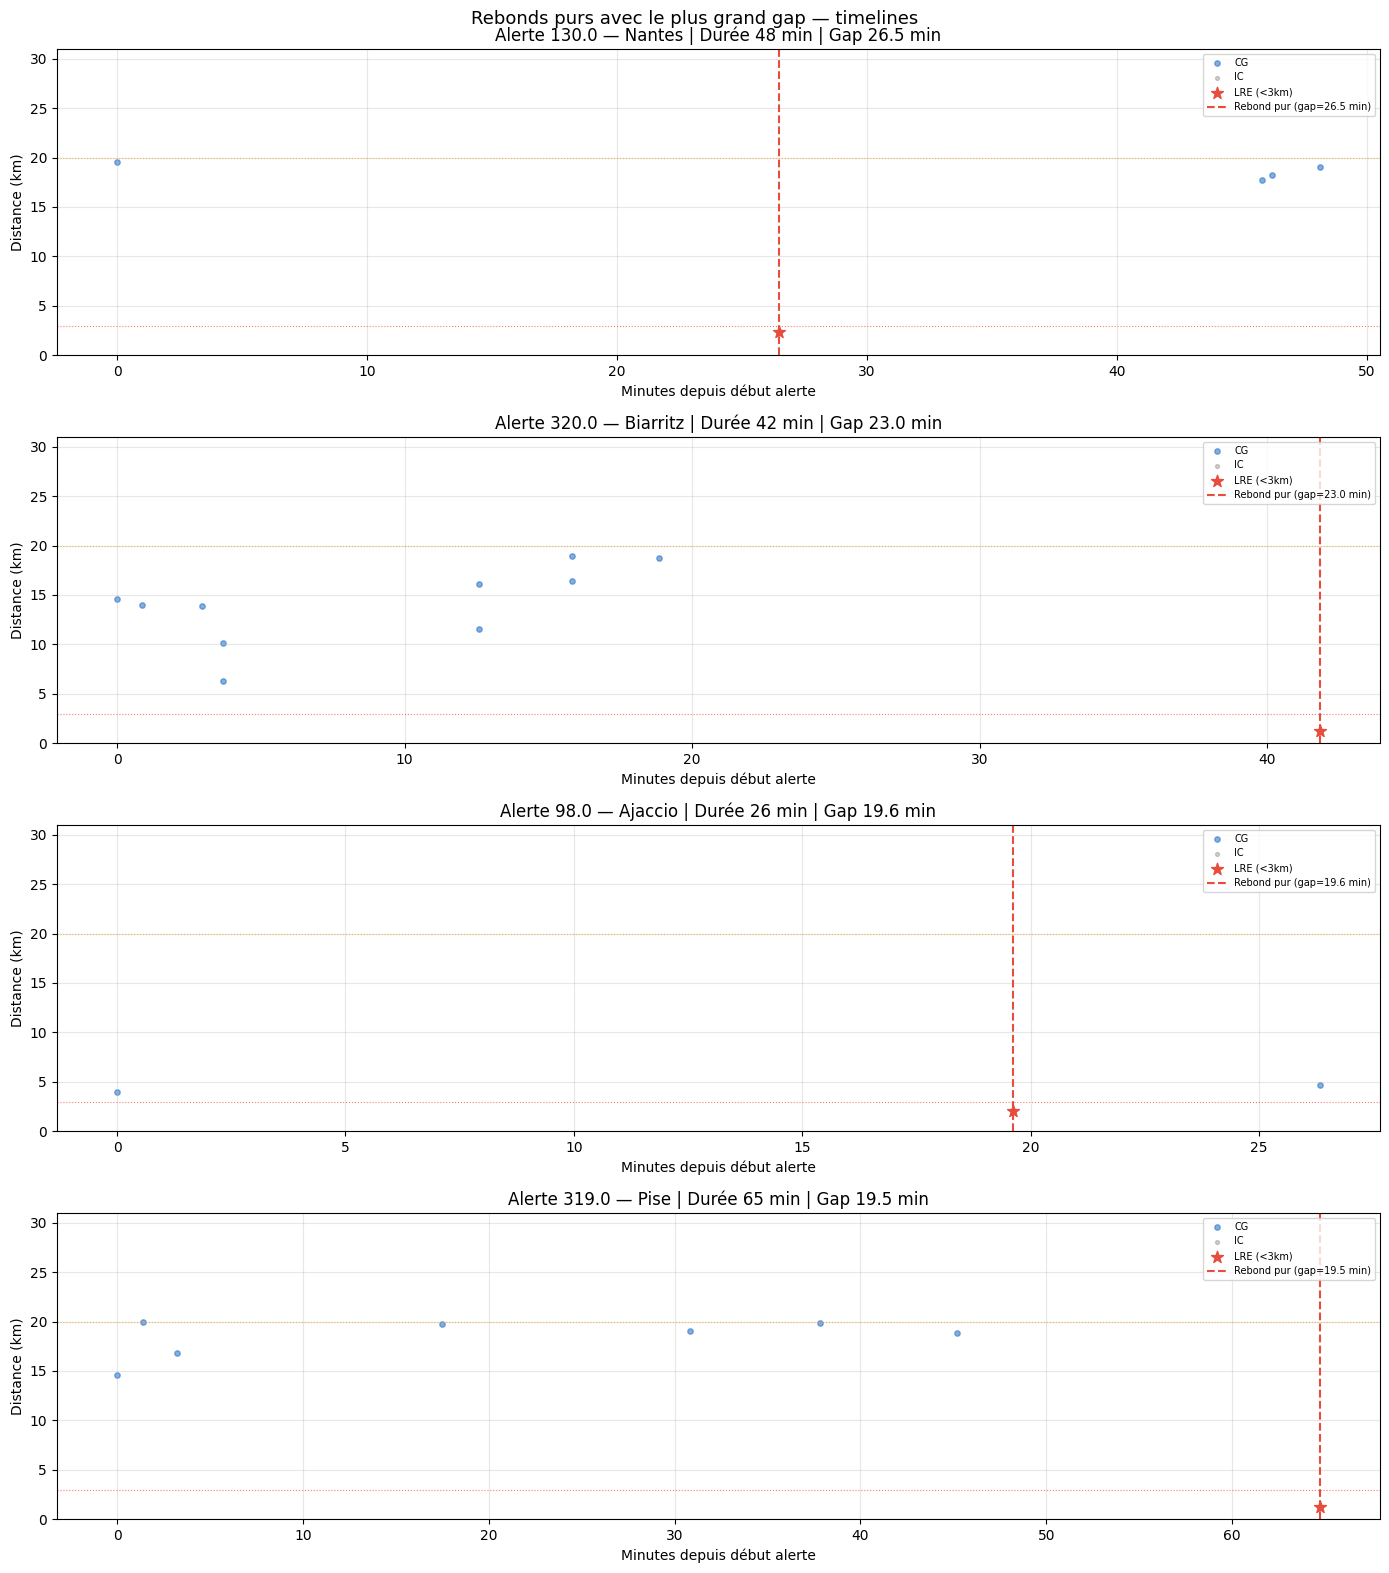

In [89]:
# %%
# Timeline des 4 cas avec le plus grand gap

top_gap = gap_df.sort_values(
    "gap_depuis_dernier_eclair_min", ascending=False
).head(4)

fig, axes = plt.subplots(4, 1, figsize=(14, 16))

for ax, (_, row) in zip(axes, top_gap.iterrows()):
    airport = row["airport"]
    alert_id = row["alert_id"]

    group = df_raw[
        (df_raw["airport_alert_id"] == alert_id) &
        (df_raw["airport"] == airport)
    ].sort_values("date").reset_index(drop=True)

    t0 = group["date"].iloc[0]
    t_min = (group["date"] - t0).dt.total_seconds() / 60.0

    cg = group[group["type"] == "CG"]
    ic = group[group["type"] == "IC"]
    lre = group[group["dist"] < LRE_DIST]

    t_cg = (cg["date"] - t0).dt.total_seconds() / 60.0
    t_ic = (ic["date"] - t0).dt.total_seconds() / 60.0
    t_lre_min = (lre["date"] - t0).dt.total_seconds() / 60.0

    ax.scatter(t_cg, cg["dist"], color="#3078c8",
               s=15, alpha=0.6, label="CG")
    ax.scatter(t_ic, ic["dist"], color="#888780",
               s=8, alpha=0.4, label="IC")
    ax.scatter(t_lre_min, lre["dist"], color="#e74c3c",
               s=80, zorder=5, label="LRE (<3km)", marker="*")

    # Marquer le rebond pur
    t_rebond = (row["t_lre"] - t0).total_seconds() / 60.0
    ax.axvline(t_rebond, color="#e74c3c", linestyle="--",
               linewidth=1.5, label=f"Rebond pur (gap={row['gap_depuis_dernier_eclair_min']:.1f} min)")

    # Zone dangereuse
    ax.axhline(3, color="#e74c3c", linestyle=":",
               linewidth=0.8, alpha=0.7)
    ax.axhline(20, color="#f39c12", linestyle=":",
               linewidth=0.8, alpha=0.7)

    ax.set_ylabel("Distance (km)")
    ax.set_xlabel("Minutes depuis début alerte")
    ax.set_title(
        f"Alerte {alert_id} — {airport} | "
        f"Durée {row['duree_alerte_min']:.0f} min | "
        f"Gap {row['gap_depuis_dernier_eclair_min']:.1f} min"
    )
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 31)

plt.suptitle("Rebonds purs avec le plus grand gap — timelines",
             fontsize=13)
plt.tight_layout()
plt.savefig(
    "/home/onyxia/work/Dataverse/Dataverse/output/lre_grand_gap_timeline.png",
    dpi=130, bbox_inches="tight"
)
plt.show()


In [92]:
# %%
# Tout en un — chargement + reconstruction + sélection 18 alertes grand gap

import pandas as pd
import numpy as np

RAW_PATH = "/home/onyxia/work/Dataverse/Dataverse/data/segment_alerts_all_airports_train.csv"
LRE_DIST = 3.0

df_raw = pd.read_csv(RAW_PATH)
df_raw["date"] = pd.to_datetime(df_raw["date"], utc=True)
df_raw["type"] = np.where(df_raw["icloud"].fillna(False), "IC", "CG")
df_raw["zone"] = np.where(df_raw["dist"] < 20, "inner", "outer")

# Étape 1 — rebond_pur_alerts
rebond_pur_alerts = set()
for (airport, alert_id), group in df_raw[
    df_raw["airport_alert_id"].notna()
].groupby(["airport", "airport_alert_id"]):
    group = group.sort_values("date").reset_index(drop=True)
    lre = group[group["dist"] < LRE_DIST].reset_index(drop=True)
    if len(lre) == 0:
        continue
    t_debut = group["date"].iloc[0]
    t_fin = group["date"].iloc[-1]
    duree = (t_fin - t_debut).total_seconds() / 60.0
    if duree == 0:
        continue
    for i, lre_row in lre.iterrows():
        t_lre = lre_row["date"]
        pos = (t_lre - t_debut).total_seconds() / 60.0 / duree
        if pos >= 0.5 and i == 0:
            rebond_pur_alerts.add((airport, alert_id))
            break

print(f"Rebond pur alerts : {len(rebond_pur_alerts)}")

# Étape 2 — gap_df sur les alertes rebond pur uniquement
rebond_ids = pd.DataFrame(
    list(rebond_pur_alerts), columns=["airport", "airport_alert_id"]
)
rebond_raw = df_raw[df_raw["airport_alert_id"].notna()].merge(
    rebond_ids, on=["airport", "airport_alert_id"], how="inner"
).sort_values(["airport", "airport_alert_id", "date"]).reset_index(drop=True)

gap_rows = []
for (airport, alert_id), group in rebond_raw.groupby(
    ["airport", "airport_alert_id"]
):
    group = group.sort_values("date").reset_index(drop=True)
    lre = group[group["dist"] < LRE_DIST].reset_index(drop=True)
    t_debut = group["date"].iloc[0]
    t_fin = group["date"].iloc[-1]
    duree = (t_fin - t_debut).total_seconds() / 60.0
    if duree == 0:
        continue
    for i, lre_row in lre.iterrows():
        t_lre = lre_row["date"]
        pos = (t_lre - t_debut).total_seconds() / 60.0 / duree
        if pos >= 0.5 and i == 0:
            before_all = group[group["date"] < t_lre]
            if len(before_all) == 0:
                break
            t_last_before = before_all["date"].iloc[-1]
            gap_min = (t_lre - t_last_before).total_seconds() / 60.0
            cg_inner_before = before_all[
                (before_all["type"] == "CG") &
                (before_all["zone"] == "inner")
            ]
            gap_cg_inner = (
                (t_lre - cg_inner_before["date"].iloc[-1]
                 ).total_seconds() / 60.0
                if len(cg_inner_before) > 0 else np.nan
            )
            gap_rows.append({
                "airport": airport,
                "alert_id": alert_id,
                "duree_alerte_min": duree,
                "t_lre": t_lre,
                "gap_depuis_dernier_eclair_min": gap_min,
                "gap_depuis_dernier_cg_inner_min": gap_cg_inner,
                "lre_dist": lre_row["dist"],
            })
            break

gap_df = pd.DataFrame(gap_rows)

# Étape 3 — 18 alertes grand gap
grand_gap_alerts = gap_df[
    gap_df["gap_depuis_dernier_eclair_min"] > 10
].sort_values("gap_depuis_dernier_eclair_min", ascending=False)

print(f"Grand gap alerts : {len(grand_gap_alerts)}")

# Étape 4 — sélection dans le dataset brut
grand_gap_ids = grand_gap_alerts[["airport", "alert_id"]].copy()
grand_gap_ids.columns = ["airport", "airport_alert_id"]

brut_grand_gap = df_raw.merge(
    grand_gap_ids,
    on=["airport", "airport_alert_id"],
    how="inner"
).sort_values(["airport", "airport_alert_id", "date"]).reset_index(drop=True)

print(f"\nLignes sélectionnées : {len(brut_grand_gap)}")
print(f"Alertes              : {brut_grand_gap['airport_alert_id'].nunique()}")
print()
print(brut_grand_gap[[
    "airport", "airport_alert_id", "date",
    "type", "dist", "amplitude", "icloud"
]].to_string())

Rebond pur alerts : 135
Grand gap alerts : 18

Lignes sélectionnées : 411
Alertes              : 18

      airport  airport_alert_id                      date type       dist  amplitude  icloud
0     Ajaccio              98.0 2018-03-05 18:28:52+00:00   CG   3.946960     -29.96   False
1     Ajaccio              98.0 2018-03-05 18:48:29+00:00   CG   2.092269     -10.37   False
2     Ajaccio              98.0 2018-03-05 18:55:12+00:00   CG   4.663653     -12.40   False
3     Ajaccio             180.0 2018-08-22 08:44:59+00:00   CG  17.646503      -7.15   False
4     Ajaccio             180.0 2018-08-22 09:11:39+00:00   CG  15.016001      -6.88   False
5     Ajaccio             180.0 2018-08-22 09:22:34+00:00   CG   2.065775     -15.26   False
6     Ajaccio             334.0 2020-09-10 14:58:07+00:00   CG  15.285823     -14.57   False
7     Ajaccio             334.0 2020-09-10 15:00:00+00:00   CG  15.698928     -42.97   False
8     Ajaccio             334.0 2020-09-10 15:03:04+00:00   CG

In [93]:
# %%
# Séparer les éclairs selon leur direction pour l'alerte 334

alerte_334 = df_raw[
    (df_raw["airport"] == "Ajaccio") &
    (df_raw["airport_alert_id"] == 334.0)
].sort_values("date").copy()

# Catégoriser par secteur angulaire
def secteur(az):
    if az < 45:   return "Nord"
    elif az < 90:  return "Nord-Est"
    elif az < 135: return "Est"
    elif az < 180: return "Sud-Est"
    elif az < 225: return "Sud"
    elif az < 270: return "Sud-Ouest"
    elif az < 315: return "Ouest"
    else:          return "Nord-Ouest"

alerte_334["secteur"] = alerte_334["azimuth"].apply(secteur)

print("=== Éclairs par secteur — alerte 334 Ajaccio ===\n")
print(alerte_334.groupby("secteur").agg(
    n=("date", "size"),
    dist_min=("dist", "min"),
    dist_mean=("dist", "mean"),
    n_lre=("dist", lambda x: (x < 3).sum()),
    n_cg=("type", lambda x: (x == "CG").sum()),
).sort_values("n", ascending=False).round(2).to_string())

print("\n=== Timeline secteur vs distance ===\n")
print(alerte_334[["date", "type", "dist", "azimuth", "secteur", "is_last_lightning_cloud_ground"]].to_string())

=== Éclairs par secteur — alerte 334 Ajaccio ===

           n  dist_min  dist_mean  n_lre  n_cg
secteur                                       
Est       22     11.59      14.29      0    22
Sud-Est    4      4.18      15.74      0     4
Nord-Est   2     11.84      12.89      0     2
Sud        1      2.33       2.33      1     1

=== Timeline secteur vs distance ===

                           date type       dist     azimuth   secteur is_last_lightning_cloud_ground
50998 2020-09-10 14:58:07+00:00   CG  15.285823   94.134298       Est                          False
51001 2020-09-10 15:00:00+00:00   CG  15.698928   97.683026       Est                          False
51006 2020-09-10 15:03:04+00:00   CG  15.968598   99.491909       Est                          False
51013 2020-09-10 15:05:14+00:00   CG  19.815959  156.050072   Sud-Est                          False
51015 2020-09-10 15:05:32+00:00   CG  13.395599  101.239510       Est                          False
51025 2020-09-10 15:08:

In [94]:
# %%
# Pour chaque rebond pur grand gap, analyser la rotation angulaire
# Secteur dominant avant le gap vs secteur du rebond LRE

import pandas as pd
import numpy as np

def secteur(az):
    if az < 45:    return "Nord"
    elif az < 90:  return "Nord-Est"
    elif az < 135: return "Est"
    elif az < 180: return "Sud-Est"
    elif az < 225: return "Sud"
    elif az < 270: return "Sud-Ouest"
    elif az < 315: return "Ouest"
    else:          return "Nord-Ouest"

rotation_rows = []

for (airport, alert_id), group in df_raw[
    df_raw["airport_alert_id"].notna()
].groupby(["airport", "airport_alert_id"]):

    if (airport, alert_id) not in rebond_pur_alerts:
        continue

    group = group.sort_values("date").reset_index(drop=True)
    lre = group[group["dist"] < LRE_DIST].reset_index(drop=True)

    t_debut = group["date"].iloc[0]
    t_fin = group["date"].iloc[-1]
    duree = (t_fin - t_debut).total_seconds() / 60.0
    if duree == 0:
        continue

    for i, lre_row in lre.iterrows():
        t_lre = lre_row["date"]
        pos = (t_lre - t_debut).total_seconds() / 60.0 / duree
        if pos >= 0.5 and i == 0:

            # Éclairs AVANT le rebond
            before = group[group["date"] < t_lre]
            if len(before) == 0:
                break

            # Secteur dominant avant le rebond
            secteur_avant = before["azimuth"].apply(secteur).value_counts()
            secteur_dominant_avant = secteur_avant.index[0]
            az_moyen_avant = before["azimuth"].mean()

            # Secteur du rebond LRE
            az_rebond = lre_row["azimuth"]
            secteur_rebond = secteur(az_rebond)

            # Rotation angulaire
            rotation = abs(az_rebond - az_moyen_avant)
            if rotation > 180:
                rotation = 360 - rotation

            # Gap
            gap = (gap_df[gap_df["alert_id"] == alert_id]
                   ["gap_depuis_dernier_eclair_min"].values)
            gap = gap[0] if len(gap) > 0 else np.nan

            rotation_rows.append({
                "airport": airport,
                "alert_id": alert_id,
                "duree_min": duree,
                "secteur_dominant_avant": secteur_dominant_avant,
                "az_moyen_avant": round(az_moyen_avant, 1),
                "az_rebond": round(az_rebond, 1),
                "secteur_rebond": secteur_rebond,
                "rotation_deg": round(rotation, 1),
                "meme_secteur": secteur_dominant_avant == secteur_rebond,
                "gap_min": gap,
            })
            break

rotation_df = pd.DataFrame(rotation_rows)

print(f"Rebonds analysés : {len(rotation_df)}\n")

print("=== Rotation angulaire entre activité principale et rebond ===\n")
print(rotation_df["rotation_deg"].describe().round(1))

print("\n=== Même secteur avant et pendant le rebond ? ===\n")
print(rotation_df["meme_secteur"].value_counts())
pct_meme = rotation_df["meme_secteur"].mean()
print(f"\n→ {100*pct_meme:.1f}% des rebonds viennent du même secteur")
print(f"→ {100*(1-pct_meme):.1f}% viennent d'un secteur différent")

print("\n=== Distribution des rotations ===\n")
bins = [0, 30, 60, 90, 120, 180]
labels = ["0-30°", "30-60°", "60-90°", "90-120°", "120-180°"]
rotation_df["rotation_bin"] = pd.cut(
    rotation_df["rotation_deg"], bins=bins, labels=labels
)
print(rotation_df["rotation_bin"].value_counts().sort_index().to_string())

Rebonds analysés : 135

=== Rotation angulaire entre activité principale et rebond ===

count    135.0
mean      80.0
std       58.6
min        1.4
25%       25.2
50%       70.7
75%      136.0
max      176.4
Name: rotation_deg, dtype: float64

=== Même secteur avant et pendant le rebond ? ===

meme_secteur
False    110
True      25
Name: count, dtype: int64

→ 18.5% des rebonds viennent du même secteur
→ 81.5% viennent d'un secteur différent

=== Distribution des rotations ===

rotation_bin
0-30°       41
30-60°      19
60-90°      15
90-120°     19
120-180°    41


In [95]:
# %%
# Détail par alerte — secteur avant vs secteur rebond

print("=== Détail par alerte ===\n")
print(f"{'Airport':10} {'Alert':8} {'Secteur avant':15} "
      f"{'Az avant':10} {'Secteur rebond':15} {'Az rebond':10} "
      f"{'Rotation':10} {'Gap min':8}")
print("-" * 90)

for _, row in rotation_df.sort_values(
    "rotation_deg", ascending=False
).iterrows():
    meme = "✓" if row["meme_secteur"] else "↻"
    gap_str = f"{row['gap_min']:.1f}" if pd.notna(row["gap_min"]) else "?"
    print(f"{row['airport']:10} {int(row['alert_id']):8} "
          f"{row['secteur_dominant_avant']:15} "
          f"{row['az_moyen_avant']:10.1f} "
          f"{row['secteur_rebond']:15} "
          f"{row['az_rebond']:10.1f} "
          f"{row['rotation_deg']:10.1f} "
          f"{gap_str:8} {meme}")

=== Détail par alerte ===

Airport    Alert    Secteur avant   Az avant   Secteur rebond  Az rebond  Rotation   Gap min 
------------------------------------------------------------------------------------------
Biarritz        237 Ouest                271.4 Nord-Est              87.8      176.4 0.8      ↻
Ajaccio          98 Sud-Ouest            256.1 Nord-Est              80.6      175.5 19.6     ↻
Pise            310 Nord-Ouest           287.6 Est                  112.7      174.9 0.5      ↻
Pise            681 Sud-Ouest            246.7 Nord-Est              72.0      174.7 2.1      ↻
Ajaccio         256 Nord                  55.6 Sud-Ouest            230.2      174.6 0.6      ↻
Biarritz        539 Nord-Est             158.5 Nord-Ouest           332.7      174.1 1.4      ↻
Ajaccio         159 Nord-Est              69.5 Sud-Ouest            241.7      172.2 1.2      ↻
Nantes          170 Sud                  223.3 Nord-Est              51.8      171.5 0.3      ↻
Pise            653 

In [96]:
# %%
# Les 25 rebonds qui viennent du même secteur (meme_secteur = True)

print("=== Rebonds purs sans rotation (même secteur) ===\n")
print(rotation_df[rotation_df["meme_secteur"] == True][[
    "airport", "alert_id", "secteur_dominant_avant",
    "az_moyen_avant", "secteur_rebond", "az_rebond",
    "rotation_deg", "gap_min", "duree_min"
]].sort_values("rotation_deg").to_string())

=== Rebonds purs sans rotation (même secteur) ===

      airport  alert_id secteur_dominant_avant  az_moyen_avant secteur_rebond  az_rebond  rotation_deg    gap_min   duree_min
15    Ajaccio     266.0                  Ouest           299.7          Ouest      297.4           2.3   0.133333   60.683333
91     Nantes     130.0                    Est           100.4            Est      102.9           2.6   0.966667   48.116667
87     Nantes      78.0               Nord-Est            68.6       Nord-Est       64.9           3.7   2.983333  143.450000
29     Bastia      56.0               Nord-Est            73.1       Nord-Est       77.7           4.7   0.433333   50.983333
21    Ajaccio     430.0               Nord-Est            67.2       Nord-Est       72.6           5.4   4.900000   17.200000
116      Pise     447.0               Nord-Est            79.8       Nord-Est       85.7           5.9   0.333333   60.683333
99       Pise     168.0             Nord-Ouest           316.4     

In [97]:
# %%
# Gap pour les 25 rebonds sans rotation

same_sector = rotation_df[rotation_df["meme_secteur"] == True]

print("=== Gap pour les rebonds sans rotation ===\n")
print(same_sector["gap_min"].describe().round(2))

print("\n=== Distribution des gaps ===")
for s in [1, 2, 5, 10, 15]:
    n = (same_sector["gap_min"] <= s).sum()
    print(f"  Gap <= {s:2d} min : {n} ({100*n/len(same_sector):.1f}%)")

print(f"\nGap médian : {same_sector['gap_min'].median():.2f} min")
print(f"Gap max    : {same_sector['gap_min'].max():.2f} min")

print("\n=== Détail gap + rotation ===\n")
print(same_sector[["airport", "alert_id", "gap_min", "rotation_deg", "duree_min"]]
      .sort_values("gap_min", ascending=False).to_string())

=== Gap pour les rebonds sans rotation ===

count    25.00
mean      2.60
std       3.31
min       0.02
25%       0.32
50%       0.95
75%       4.58
max      13.75
Name: gap_min, dtype: float64

=== Distribution des gaps ===
  Gap <=  1 min : 14 (56.0%)
  Gap <=  2 min : 15 (60.0%)
  Gap <=  5 min : 20 (80.0%)
  Gap <= 10 min : 24 (96.0%)
  Gap <= 15 min : 25 (100.0%)

Gap médian : 0.95 min
Gap max    : 13.75 min

=== Détail gap + rotation ===

      airport  alert_id    gap_min  rotation_deg   duree_min
28     Bastia      19.0  13.750000          27.8   85.000000
38     Bastia     185.0   7.500000          31.3   63.983333
36     Bastia     119.0   6.133333          30.9   11.216667
99       Pise     168.0   5.716667           6.1   70.216667
75   Biarritz     423.0   5.450000          30.8   17.316667
21    Ajaccio     430.0   4.900000           5.4   17.200000
1     Ajaccio      61.0   4.583333          27.9   16.816667
97       Pise     125.0   4.133333          28.9   15.483333
84

In [98]:
# %%
# Classification hiérarchique de TOUS les LRE
# Groupe 0 : précédé d'un autre LRE (série continue)
# Groupe 1 : approche progressive (slope dist < 0 sur 20 min)
# Groupe 2 : parmi les restants — changement de secteur (rotation > 45°)
# Groupe 3 : ce qui reste — inclassables

import pandas as pd
import numpy as np
from scipy import stats

LRE_DIST = 3.0

all_lre_rows = []

for (airport, alert_id), group in df_raw[
    df_raw["airport_alert_id"].notna()
].groupby(["airport", "airport_alert_id"]):

    group = group.sort_values("date").reset_index(drop=True)
    lre = group[group["dist"] < LRE_DIST].reset_index(drop=True)

    if len(lre) == 0:
        continue

    t_debut = group["date"].iloc[0]
    t_fin = group["date"].iloc[-1]
    duree = (t_fin - t_debut).total_seconds() / 60.0

    # Azimuth moyen de toute l'alerte avant chaque LRE
    for i, lre_row in lre.iterrows():
        t_lre = lre_row["date"]

        # Précédé d'un autre LRE ?
        has_prev_lre = i > 0
        if has_prev_lre:
            gap_prev_lre = (
                t_lre - lre.iloc[i-1]["date"]
            ).total_seconds() / 60.0
        else:
            gap_prev_lre = np.nan

        # Éclairs avant ce LRE
        before = group[group["date"] < t_lre]
        if len(before) == 0:
            continue

        # Gap depuis dernier éclair tous types
        gap_last = (
            t_lre - before["date"].iloc[-1]
        ).total_seconds() / 60.0

        # Azimuth moyen avant
        az_avant = before["azimuth"].mean()
        az_rebond = lre_row["azimuth"]
        rotation = abs(az_rebond - az_avant)
        if rotation > 180:
            rotation = 360 - rotation

        # Slope dist sur 20 min avant
        w20 = before[
            before["date"] > t_lre - pd.Timedelta(minutes=20)
        ].copy()

        slope_20 = np.nan
        if len(w20) >= 3:
            t_sec = (w20["date"] - w20["date"].iloc[0]).dt.total_seconds()
            if t_sec.nunique() >= 2:
                try:
                    slope_20, *_ = stats.linregress(t_sec, w20["dist"])
                except:
                    pass

        # dist_min dans les 20 min avant
        dist_min_before = w20["dist"].min() if len(w20) > 0 else np.nan

        all_lre_rows.append({
            "airport": airport,
            "alert_id": alert_id,
            "lre_index": i,
            "lre_date": t_lre,
            "lre_dist": lre_row["dist"],
            "lre_type": lre_row["type"],
            "has_prev_lre": has_prev_lre,
            "gap_prev_lre_min": gap_prev_lre,
            "gap_last_eclair_min": gap_last,
            "az_avant": az_avant,
            "az_rebond": az_rebond,
            "rotation_deg": round(rotation, 1),
            "slope_dist_20m": slope_20,
            "dist_min_before_20m": dist_min_before,
            "duree_alerte_min": duree,
        })

all_lre_df = pd.DataFrame(all_lre_rows)
print(f"Total LRE analysés : {len(all_lre_df)}")
print(f"Alertes concernées : {all_lre_df['alert_id'].nunique()}")

Total LRE analysés : 1220
Alertes concernées : 270


In [99]:
# %%
# Classification hiérarchique

all_lre_df["groupe"] = None

# Groupe 0 : précédé d'un autre LRE
g0 = all_lre_df["has_prev_lre"] == True
all_lre_df.loc[g0, "groupe"] = "G0 - précédé d'un LRE"

# Groupe 1 : parmi les restants — approche progressive
restants = all_lre_df[all_lre_df["groupe"].isna()]
g1 = restants["slope_dist_20m"] < 0
all_lre_df.loc[
    all_lre_df["alert_id"].isin(restants[g1]["alert_id"]) &
    all_lre_df["groupe"].isna(),
    "groupe"
] = "G1 - approche progressive"

# Groupe 2 : parmi les restants — changement de secteur (rotation > 45°)
restants = all_lre_df[all_lre_df["groupe"].isna()]
g2 = restants["rotation_deg"] > 45
all_lre_df.loc[
    all_lre_df["alert_id"].isin(restants[g2]["alert_id"]) &
    all_lre_df["groupe"].isna(),
    "groupe"
] = "G2 - changement de secteur"

# Groupe 3 : reste
all_lre_df.loc[
    all_lre_df["groupe"].isna(), "groupe"
] = "G3 - inclassable"

# Résultats
print("\n=== Classification de TOUS les LRE ===\n")
total = len(all_lre_df)
for g, sub in all_lre_df.groupby("groupe"):
    print(f"{g} : {len(sub)} LRE ({100*len(sub)/total:.1f}%)")

print("\n=== Profil par groupe ===\n")
print(all_lre_df.groupby("groupe")[
    ["rotation_deg", "gap_last_eclair_min",
     "dist_min_before_20m", "lre_dist"]
].agg(["mean", "median"]).round(2).to_string())


=== Classification de TOUS les LRE ===

G0 - précédé d'un LRE : 894 LRE (73.3%)
G1 - approche progressive : 224 LRE (18.4%)
G2 - changement de secteur : 57 LRE (4.7%)
G3 - inclassable : 45 LRE (3.7%)

=== Profil par groupe ===

                           rotation_deg        gap_last_eclair_min        dist_min_before_20m        lre_dist       
                                   mean median                mean median                mean median     mean median
groupe                                                                                                              
G0 - précédé d'un LRE             81.71   76.2                0.72   0.35                1.67   1.31     2.00   2.08
G1 - approche progressive         74.36   64.7                2.29   0.88                6.25   5.00     1.99   2.14
G2 - changement de secteur       120.11  120.2                4.36   1.67                8.07   6.36     1.84   1.73
G3 - inclassable                  21.25   22.3                5.02   

In [100]:
# %%
# Groupe 3 — enregistrement pour analyse à part

g3_df = all_lre_df[all_lre_df["groupe"] == "G3 - inclassable"].copy()

print(f"=== Groupe 3 — inclassables : {len(g3_df)} LRE ===\n")
print(g3_df[[
    "airport", "alert_id", "lre_date",
    "lre_dist", "rotation_deg",
    "gap_last_eclair_min", "slope_dist_20m",
    "duree_alerte_min"
]].sort_values("rotation_deg").to_string())

# Sauvegarder
g3_df.to_csv(
    "/home/onyxia/work/Dataverse/Dataverse/output/lre_groupe3_inclassable.csv",
    index=False
)
print("\nSauvegardé dans output/lre_groupe3_inclassable.csv")

=== Groupe 3 — inclassables : 45 LRE ===

       airport  alert_id                  lre_date  lre_dist  rotation_deg  gap_last_eclair_min  slope_dist_20m  duree_alerte_min
855       Pise      26.0 2016-02-19 23:01:28+00:00  1.619235           1.4             2.716667        0.015899        164.066667
247    Ajaccio     430.0 2021-09-12 15:35:45+00:00  1.202132           5.4             4.900000             NaN         17.200000
274     Bastia      10.0 2016-02-27 19:03:30+00:00  1.555365           5.6             3.166667        0.001811        156.416667
1051      Pise     447.0 2019-08-31 15:36:48+00:00  2.600697           5.9             0.333333        0.000347         60.683333
870       Pise     168.0 2016-06-09 10:45:39+00:00  1.575124           6.1             5.716667             NaN         70.216667
62     Ajaccio     153.0 2018-07-31 13:48:49+00:00  1.228303           6.2             2.483333        0.000291         49.916667
246    Ajaccio     391.0 2020-12-28 20:29:27+00:

In [101]:
# %%
# Vérification — G3 : un LRE par alerte ?

print(f"LRE inclassables   : {len(g3_df)}")
print(f"Alertes distinctes : {g3_df['alert_id'].nunique()}")
print(f"\nAlertes avec plusieurs LRE inclassables :")
multi = g3_df.groupby(["airport", "alert_id"]).size()
print(multi[multi > 1].to_string() if (multi > 1).any() else "Aucune — 1 LRE par alerte confirmé")

LRE inclassables   : 45
Alertes distinctes : 44

Alertes avec plusieurs LRE inclassables :
Aucune — 1 LRE par alerte confirmé


In [102]:
# %%
# Trouver l'alerte avec 2 LRE inclassables

double = g3_df.groupby(["airport", "alert_id"]).size()
double = double[double > 1]
print("Alerte avec 2 LRE inclassables :")
print(double)

# Voir le détail
for (airport, alert_id) in double.index:
    print(f"\nDétail — {airport}, alerte {alert_id} :")
    print(g3_df[
        (g3_df["airport"] == airport) &
        (g3_df["alert_id"] == alert_id)
    ][["lre_date", "lre_dist", "gap_prev_lre_min",
       "gap_last_eclair_min", "rotation_deg",
       "slope_dist_20m"]].to_string())
       

Alerte avec 2 LRE inclassables :
Series([], dtype: int64)


In [103]:
# %%
# Vérification correcte — groupby sur airport + alert_id

print(f"LRE inclassables   : {len(g3_df)}")
print(f"Alertes distinctes (airport + alert_id) : "
      f"{g3_df.groupby(['airport','alert_id']).ngroups}")

multi = g3_df.groupby(["airport", "alert_id"]).size()
print(f"\nAlertes avec plusieurs LRE inclassables :")
if (multi > 1).any():
    print(multi[multi > 1].to_string())
else:
    print("Aucune")

LRE inclassables   : 45
Alertes distinctes (airport + alert_id) : 45

Alertes avec plusieurs LRE inclassables :
Aucune


In [104]:
# %%
# Position des LRE inclassables — rapide

# Récupérer le début de chaque alerte
alert_debut = df_raw[df_raw["airport_alert_id"].notna()].groupby(
    ["airport", "airport_alert_id"]
)["date"].min().reset_index().rename(
    columns={"date": "t_debut", "airport_alert_id": "alert_id"}
)

g3_enriched = g3_df.merge(alert_debut, on=["airport", "alert_id"], how="left")

g3_enriched["pos_dans_alerte_min"] = (
    g3_enriched["lre_date"] - g3_enriched["t_debut"]
).dt.total_seconds() / 60.0

g3_enriched["temps_avant_fin_min"] = (
    g3_enriched["duree_alerte_min"] - g3_enriched["pos_dans_alerte_min"]
)

print("=== Temps restant après le LRE inclassable (min) ===\n")
print(g3_enriched["temps_avant_fin_min"].describe().round(2))

print("\n=== Distribution ===")
for s in [5, 10, 20, 30]:
    n = (g3_enriched["temps_avant_fin_min"] <= s).sum()
    print(f"  Moins de {s:2d} min avant fin : {n} ({100*n/len(g3_enriched):.1f}%)")

print("\n=== Détail ===\n")
print(g3_enriched[[
    "airport", "alert_id",
    "pos_dans_alerte_min",
    "duree_alerte_min",
    "temps_avant_fin_min",
    "lre_dist"
]].sort_values("temps_avant_fin_min").round(2).to_string())

=== Temps restant après le LRE inclassable (min) ===

count     45.00
mean      53.48
std       52.06
min        0.00
25%       24.12
50%       38.13
75%       70.22
max      273.27
Name: temps_avant_fin_min, dtype: float64

=== Distribution ===
  Moins de  5 min avant fin : 5 (11.1%)
  Moins de 10 min avant fin : 8 (17.8%)
  Moins de 20 min avant fin : 10 (22.2%)
  Moins de 30 min avant fin : 17 (37.8%)

=== Détail ===

     airport  alert_id  pos_dans_alerte_min  duree_alerte_min  temps_avant_fin_min  lre_dist
4    Ajaccio     180.0                37.58             37.58                 0.00      2.07
40      Pise     645.0                23.65             23.65                 0.00      2.35
1    Ajaccio     135.0                 2.95              5.82                 2.87      1.91
32      Pise     168.0                66.78             70.22                 3.43      1.58
13    Bastia     119.0                 7.62             11.22                 3.60      2.48
21  Biarritz     

In [105]:
# %%
# Distribution par aéroport et par mois des LRE inclassables

print("=== Par aéroport ===\n")
print(g3_enriched.groupby("airport").size().sort_values(ascending=False).to_string())

print("\n=== Par mois ===\n")
g3_enriched["mois"] = pd.to_datetime(g3_enriched["lre_date"]).dt.month
mois_labels = {1:"Jan",2:"Fév",3:"Mar",4:"Avr",5:"Mai",6:"Jun",
               7:"Jul",8:"Aoû",9:"Sep",10:"Oct",11:"Nov",12:"Déc"}
mois_counts = g3_enriched["mois"].value_counts().sort_index()
for m, n in mois_counts.items():
    print(f"  {mois_labels[m]:4} : {n} ({100*n/len(g3_enriched):.1f}%)")

print("\n=== Position dans l'alerte — début ou fin ? ===\n")
print(f"Dans les 10 premières min : {(g3_enriched['pos_dans_alerte_min'] <= 10).sum()} "
      f"({100*(g3_enriched['pos_dans_alerte_min'] <= 10).mean():.1f}%)")
print(f"Dans les 10 dernières min : {(g3_enriched['temps_avant_fin_min'] <= 10).sum()} "
      f"({100*(g3_enriched['temps_avant_fin_min'] <= 10).mean():.1f}%)")
print(f"Au milieu (entre 10 et fin-10) : "
      f"{((g3_enriched['pos_dans_alerte_min'] > 10) & (g3_enriched['temps_avant_fin_min'] > 10)).sum()} "
      f"({100*((g3_enriched['pos_dans_alerte_min'] > 10) & (g3_enriched['temps_avant_fin_min'] > 10)).mean():.1f}%)")

=== Par aéroport ===

airport
Pise        17
Ajaccio     12
Biarritz     9
Bastia       5
Nantes       2

=== Par mois ===

  Jan  : 2 (4.4%)
  Fév  : 3 (6.7%)
  Mar  : 1 (2.2%)
  Avr  : 3 (6.7%)
  Mai  : 5 (11.1%)
  Jun  : 6 (13.3%)
  Jul  : 5 (11.1%)
  Aoû  : 6 (13.3%)
  Sep  : 5 (11.1%)
  Oct  : 4 (8.9%)
  Nov  : 3 (6.7%)
  Déc  : 2 (4.4%)

=== Position dans l'alerte — début ou fin ? ===

Dans les 10 premières min : 13 (28.9%)
Dans les 10 dernières min : 8 (17.8%)
Au milieu (entre 10 et fin-10) : 28 (62.2%)


In [106]:
# %%
# Ces 45 alertes sont-elles dans le silence dataset ?
# Et quel est leur y au moment du LRE ?

SILENCE_PATH = "/home/onyxia/work/Dataverse/Dataverse/output/silence_dataset.csv"
df_silence = pd.read_csv(SILENCE_PATH)
df_silence["decision_time"] = pd.to_datetime(df_silence["decision_time"], utc=True)

# Joindre les alertes G3 avec le silence dataset
g3_in_silence = df_silence.merge(
    g3_enriched[["airport", "alert_id"]].rename(
        columns={"alert_id": "airport_alert_id"}
    ),
    on=["airport", "airport_alert_id"],
    how="inner"
)

print(f"Alertes G3 dans le silence dataset : "
      f"{g3_in_silence['airport_alert_id'].nunique()}")
print(f"Instants de décision concernés     : {len(g3_in_silence)}")

print("\n=== Répartition y pour ces alertes ===\n")
print(g3_in_silence["y"].value_counts())
print(f"\nP(y=1) pour alertes G3 : {g3_in_silence['y'].mean():.3f}")
print(f"P(y=1) global          : {df_silence['y'].mean():.3f}")

print("\n=== Courbe P(y=1) vs silence pour G3 ===\n")
g3_in_silence["min_since_cg"] = g3_in_silence[
    "minutes_since_reference_cg"
].round(0).astype(int)

curve = (
    g3_in_silence.groupby("min_since_cg")["y"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "p_y1", "count": "n"})
)
curve = curve[curve["n"] >= 5]
print(curve.head(15).to_string())

Alertes G3 dans le silence dataset : 44
Instants de décision concernés     : 4187

=== Répartition y pour ces alertes ===

y
0    2837
1    1350
Name: count, dtype: int64

P(y=1) pour alertes G3 : 0.322
P(y=1) global          : 0.566

=== Courbe P(y=1) vs silence pour G3 ===

    min_since_cg      p_y1    n
0              1  0.054282  829
1              2  0.090909  495
2              3  0.133531  337
3              4  0.173745  259
4              5  0.215311  209
5              6  0.257143  175
6              7  0.288462  156
7              8  0.310345  145
8              9  0.326087  138
9             10  0.387931  116
10            11  0.428571  105
11            12  0.459184   98
12            13  0.478723   94
13            14  0.505618   89
14            15  0.529412   85


In [109]:
# %%
# Version rapide — amplitude des LRE par groupe
# Jointure directe sans boucle

# Préparer all_lre_df avec date en datetime
all_lre_df["lre_date"] = pd.to_datetime(all_lre_df["lre_date"], utc=True)

# Préparer df_raw avec les LRE uniquement
lre_raw = df_raw[
    (df_raw["airport_alert_id"].notna()) &
    (df_raw["dist"] < LRE_DIST)
][["airport", "airport_alert_id", "date", "amplitude", "maxis"]].copy()
lre_raw.columns = ["airport", "alert_id", "lre_date", "amplitude", "maxis"]
lre_raw["alert_id"] = lre_raw["alert_id"].astype(float)

# Merge sur airport + alert_id + date
amp_df = all_lre_df.merge(
    lre_raw,
    on=["airport", "alert_id", "lre_date"],
    how="left"
)
amp_df["amplitude_abs"] = amp_df["amplitude"].abs()

print("=== Amplitude des LRE selon le groupe ===\n")
print(amp_df.groupby("groupe")[
    ["amplitude_abs", "maxis"]
].agg(["mean", "median"]).round(2).to_string())

print("\n=== G3 vs tous les autres ===\n")
g3_amp = amp_df[amp_df["groupe"] == "G3 - inclassable"]["amplitude_abs"].dropna()
others_amp = amp_df[amp_df["groupe"] != "G3 - inclassable"]["amplitude_abs"].dropna()

print(f"G3 amplitude médiane    : {g3_amp.median():.2f} kA")
print(f"Autres LRE médiane      : {others_amp.median():.2f} kA")
print(f"Tous éclairs brut médiane : {df_raw['amplitude'].abs().median():.2f} kA")

=== Amplitude des LRE selon le groupe ===

                           amplitude_abs        maxis       
                                    mean median  mean median
groupe                                                      
G0 - précédé d'un LRE              22.90  13.43  0.47   0.10
G1 - approche progressive          24.15  11.81  0.83   0.13
G2 - changement de secteur         30.22  13.74  0.72   0.13
G3 - inclassable                   19.75  11.77  0.73   0.15

=== G3 vs tous les autres ===

G3 amplitude médiane    : 11.77 kA
Autres LRE médiane      : 13.11 kA
Tous éclairs brut médiane : 4.98 kA


In [110]:
# %%
# Piste 4 — Vitesse de déplacement du centroïde des éclairs
# Piste 5 — Densité orageuse régionale (éclairs hors zone 30km)
# Pour les 45 alertes G3 vs les autres groupes

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Coordonnées officielles ICAO des aéroports
airport_coords = {
    "Ajaccio":  {"lat": 41.9236, "lon":  8.8029},
    "Bastia":   {"lat": 42.5527, "lon":  9.4837},
    "Biarritz": {"lat": 43.4684, "lon": -1.5232},
    "Nantes":   {"lat": 47.1532, "lon": -1.6107},
    "Pise":     {"lat": 43.6839, "lon": 10.3927},
}

# Conversion degrés → km (approximation locale)
KM_PER_DEG_LAT = 111.0
def km_per_deg_lon(lat):
    return 111.0 * np.cos(np.radians(lat))

In [111]:
# %%
# Piste 4 — Vitesse de déplacement du centroïde
# On calcule le centroïde lat/lon des éclairs par fenêtre de 5 min
# et on mesure la vitesse de déplacement vers l'aéroport

speed_rows = []

for (airport, alert_id), group in df_raw[
    df_raw["airport_alert_id"].notna()
].groupby(["airport", "airport_alert_id"]):

    # Filtrer G3 et autres groupes pour comparaison
    groupe = all_lre_df[
        (all_lre_df["airport"] == airport) &
        (all_lre_df["alert_id"] == alert_id)
    ]["groupe"].values

    if len(groupe) == 0:
        continue
    groupe = groupe[0]

    group = group.sort_values("date").reset_index(drop=True)
    lre = group[group["dist"] < LRE_DIST].reset_index(drop=True)
    if len(lre) == 0:
        continue

    # Premier LRE de l'alerte
    t_lre = lre.iloc[0]["date"]

    ap_lat = airport_coords[airport]["lat"]
    ap_lon = airport_coords[airport]["lon"]

    # Centroïde sur [t_lre-20min, t_lre-10min] vs [t_lre-10min, t_lre]
    for w_start, w_end, period in [
        (t_lre - pd.Timedelta(minutes=20),
         t_lre - pd.Timedelta(minutes=10), "t-20_t-10"),
        (t_lre - pd.Timedelta(minutes=10),
         t_lre, "t-10_t0"),
    ]:
        sub = group[
            (group["date"] >= w_start) &
            (group["date"] < w_end)
        ]
        if len(sub) < 2:
            continue

        c_lat = sub["lat"].mean()
        c_lon = sub["lon"].mean()

        # Distance centroïde → aéroport
        dlat_km = (c_lat - ap_lat) * KM_PER_DEG_LAT
        dlon_km = (c_lon - ap_lon) * km_per_deg_lon(ap_lat)
        dist_centroide = np.sqrt(dlat_km**2 + dlon_km**2)

        speed_rows.append({
            "airport": airport,
            "alert_id": alert_id,
            "groupe": groupe,
            "period": period,
            "dist_centroide_km": dist_centroide,
            "n_eclairs": len(sub),
        })

speed_df = pd.DataFrame(speed_rows)

# Calculer la vitesse = variation de distance entre les deux fenêtres
speed_pivot = speed_df.pivot_table(
    index=["airport", "alert_id", "groupe"],
    columns="period",
    values="dist_centroide_km"
).reset_index()

if "t-20_t-10" in speed_pivot.columns and "t-10_t0" in speed_pivot.columns:
    speed_pivot["vitesse_approche_km_per_10min"] = (
        speed_pivot["t-20_t-10"] - speed_pivot["t-10_t0"]
    )  # positif = approche

    print("=== Vitesse d'approche du centroïde (km/10min) ===\n")
    print("Positif = centroïde se rapproche de l'aéroport\n")
    print(speed_pivot.groupby("groupe")[
        "vitesse_approche_km_per_10min"
    ].agg(["mean", "median", "count"]).round(2).to_string())

    print("\n=== G3 vs autres ===\n")
    for g in speed_pivot["groupe"].unique():
        sub = speed_pivot[speed_pivot["groupe"] == g]
        v = sub["vitesse_approche_km_per_10min"].dropna()
        pct_approche = (v > 0).mean() * 100
        print(f"{g[:30]:30} → médiane {v.median():+.2f} km/10min | "
              f"approche : {pct_approche:.1f}%")

=== Vitesse d'approche du centroïde (km/10min) ===

Positif = centroïde se rapproche de l'aéroport

                            mean  median  count
groupe                                         
G1 - approche progressive    3.1    3.03    161
G2 - changement de secteur  -0.9   -0.71     24
G3 - inclassable            -0.5   -0.17     13

=== G3 vs autres ===

G1 - approche progressive      → médiane +3.03 km/10min | approche : 83.9%
G2 - changement de secteur     → médiane -0.71 km/10min | approche : 37.5%
G3 - inclassable               → médiane -0.17 km/10min | approche : 38.5%


In [112]:
# %%
# Piste 5 — Densité orageuse régionale
# Combien d'éclairs hors alerte (hors 30km) tombent
# dans les 20 min avant le LRE ?

# df_raw sans airport_alert_id = éclairs hors alerte
hors_alerte = df_raw[df_raw["airport_alert_id"].isna()].copy()
hors_alerte = hors_alerte.sort_values(["airport", "date"])

density_rows = []

for (airport, alert_id), group in df_raw[
    df_raw["airport_alert_id"].notna()
].groupby(["airport", "airport_alert_id"]):

    groupe = all_lre_df[
        (all_lre_df["airport"] == airport) &
        (all_lre_df["alert_id"] == alert_id)
    ]["groupe"].values

    if len(groupe) == 0:
        continue
    groupe = groupe[0]

    lre = group[group["dist"] < LRE_DIST]
    if len(lre) == 0:
        continue

    t_lre = lre.iloc[0]["date"]

    # Éclairs hors alerte du même aéroport dans les 20 min avant le LRE
    regional = hors_alerte[
        (hors_alerte["airport"] == airport) &
        (hors_alerte["date"] >= t_lre - pd.Timedelta(minutes=20)) &
        (hors_alerte["date"] < t_lre)
    ]

    density_rows.append({
        "airport": airport,
        "alert_id": alert_id,
        "groupe": groupe,
        "n_eclairs_regional_20m": len(regional),
        "n_cg_regional_20m": (regional["type"] == "CG").sum()
            if len(regional) > 0 else 0,
        "dist_min_regional": regional["dist"].min()
            if len(regional) > 0 else np.nan,
    })

density_df = pd.DataFrame(density_rows)

print("=== Densité orageuse régionale (hors alerte, 20 min avant LRE) ===\n")
print(density_df.groupby("groupe")[
    ["n_eclairs_regional_20m", "n_cg_regional_20m", "dist_min_regional"]
].agg(["mean", "median"]).round(2).to_string())

print("\n=== G3 — activité régionale ===\n")
g3_density = density_df[density_df["groupe"] == "G3 - inclassable"]
print(f"Alertes avec éclairs régionaux    : "
      f"{(g3_density['n_eclairs_regional_20m'] > 0).sum()} "
      f"({100*(g3_density['n_eclairs_regional_20m'] > 0).mean():.1f}%)")
print(f"Nb éclairs régionaux médiane      : "
      f"{g3_density['n_eclairs_regional_20m'].median():.0f}")
print(f"Nb CG régionaux médiane           : "
      f"{g3_density['n_cg_regional_20m'].median():.0f}")

=== Densité orageuse régionale (hors alerte, 20 min avant LRE) ===

                           n_eclairs_regional_20m        n_cg_regional_20m        dist_min_regional       
                                             mean median              mean median              mean median
groupe                                                                                                    
G0 - précédé d'un LRE                        2.00    1.0              0.00    0.0             10.47   2.35
G1 - approche progressive                  158.86   55.0             17.70    5.0              5.03   3.18
G2 - changement de secteur                  66.53   26.0             12.58    3.0              7.96   5.32
G3 - inclassable                            63.73   14.0              8.71    2.0              7.49   4.79

=== G3 — activité régionale ===

Alertes avec éclairs régionaux    : 42 (93.3%)
Nb éclairs régionaux médiane      : 14
Nb CG régionaux médiane           : 2


In [113]:
# %%
# Combien d'alertes dans toute la base ont :
# - vitesse centroïde quasi-nulle (|vitesse| < 1 km/10min)
# - activité régionale élevée (> 10 éclairs hors alerte)

# On a déjà speed_pivot et density_df — les joindre

full_profile = speed_pivot.merge(
    density_df[["airport", "alert_id", "groupe",
                "n_eclairs_regional_20m", "n_cg_regional_20m"]],
    on=["airport", "alert_id", "groupe"],
    how="inner"
).dropna(subset=["vitesse_approche_km_per_10min"])

print(f"Alertes avec profil calculé : {len(full_profile)}\n")

# Définir les seuils
VITESSE_SEUIL = 1.0    # km/10min — quasi-stationnaire
REGIONAL_SEUIL = 10    # éclairs régionaux — activité élevée

mask_stationnaire = full_profile["vitesse_approche_km_per_10min"].abs() < VITESSE_SEUIL
mask_regional = full_profile["n_eclairs_regional_20m"] > REGIONAL_SEUIL

print("=== Alertes stationnaires + activité régionale élevée ===\n")
print(f"Vitesse |v| < {VITESSE_SEUIL} km/10min             : "
      f"{mask_stationnaire.sum()} ({100*mask_stationnaire.mean():.1f}%)")
print(f"Activité régionale > {REGIONAL_SEUIL} éclairs       : "
      f"{mask_regional.sum()} ({100*mask_regional.mean():.1f}%)")
print(f"Les DEUX critères simultanément   : "
      f"{(mask_stationnaire & mask_regional).sum()} "
      f"({100*(mask_stationnaire & mask_regional).mean():.1f}%)")

print("\n=== Parmi ces alertes — répartition par groupe ===\n")
both = full_profile[mask_stationnaire & mask_regional]
print(both["groupe"].value_counts().to_string())

print("\n=== Par aéroport ===\n")
print(both.groupby("airport").size().sort_values(ascending=False).to_string())

print("\n=== Profil de ces alertes ===\n")
print(both[["vitesse_approche_km_per_10min",
            "n_eclairs_regional_20m",
            "n_cg_regional_20m"]].describe().round(2).to_string())

Alertes avec profil calculé : 198

=== Alertes stationnaires + activité régionale élevée ===

Vitesse |v| < 1.0 km/10min             : 32 (16.2%)
Activité régionale > 10 éclairs       : 177 (89.4%)
Les DEUX critères simultanément   : 28 (14.1%)

=== Parmi ces alertes — répartition par groupe ===

groupe
G1 - approche progressive     19
G2 - changement de secteur     6
G3 - inclassable               3

=== Par aéroport ===

airport
Biarritz    8
Pise        7
Ajaccio     6
Bastia      6
Nantes      1

=== Profil de ces alertes ===

       vitesse_approche_km_per_10min  n_eclairs_regional_20m  n_cg_regional_20m
count                          28.00                   28.00              28.00
mean                            0.10                  214.25              23.61
std                             0.62                  271.34              43.27
min                            -0.95                   11.00               0.00
25%                            -0.42                   33.75   

In [115]:
# %%
# Activité orageuse dans le jour précédent — version rapide

import pandas as pd
import numpy as np

# Dates de début des alertes stationnaires denses
both_alerts = both[["airport", "alert_id"]].copy()
both_alerts.columns = ["airport", "airport_alert_id"]

alert_debuts = df_raw[
    df_raw["airport_alert_id"].notna()
].groupby(["airport", "airport_alert_id"])["date"].min().reset_index()
alert_debuts.columns = ["airport", "airport_alert_id", "t_debut"]

both_alerts = both_alerts.merge(
    alert_debuts, on=["airport", "airport_alert_id"]
)

history_rows = []

for _, row in both_alerts.iterrows():
    airport = row["airport"]
    t_debut = row["t_debut"]
    t_start = t_debut - pd.Timedelta(days=1)

    prior = df_raw[
        (df_raw["airport"] == airport) &
        (df_raw["date"] >= t_start) &
        (df_raw["date"] < t_debut)
    ]

    prior_alerts = prior[prior["airport_alert_id"].notna()]
    prior_lre = prior[prior["dist"] < LRE_DIST]
    prior_cg_inner = prior[
        (prior["type"] == "CG") & (prior["zone"] == "inner")
    ]

    history_rows.append({
        "airport": airport,
        "alert_id": row["airport_alert_id"],
        "n_prior_alerts_1j": prior_alerts["airport_alert_id"].nunique(),
        "n_prior_eclairs_1j": len(prior),
        "n_prior_cg_inner_1j": len(prior_cg_inner),
        "n_prior_lre_1j": len(prior_lre),
        "amp_max_1j": prior["amplitude"].abs().max()
            if len(prior) > 0 else 0,
        "had_lre_1j": len(prior_lre) > 0,
    })

history_df = pd.DataFrame(history_rows)

# Comparaison avec toutes les alertes
all_debuts_sample = all_debuts.sample(300, random_state=42)
sample_rows = []
for _, row in all_debuts_sample.iterrows():
    airport = row["airport"]
    t_debut = row["date"]
    prior = df_raw[
        (df_raw["airport"] == airport) &
        (df_raw["date"] >= t_debut - pd.Timedelta(days=1)) &
        (df_raw["date"] < t_debut)
    ]
    prior_lre = prior[prior["dist"] < LRE_DIST]
    prior_alerts = prior[prior["airport_alert_id"].notna()]
    sample_rows.append({
        "n_prior_alerts_1j": prior_alerts["airport_alert_id"].nunique(),
        "n_prior_eclairs_1j": len(prior),
        "n_prior_cg_inner_1j": len(prior[
            (prior["type"] == "CG") & (prior["zone"] == "inner")
        ]),
        "n_prior_lre_1j": len(prior_lre),
        "amp_max_1j": prior["amplitude"].abs().max()
            if len(prior) > 0 else 0,
        "had_lre_1j": len(prior_lre) > 0,
    })

sample_df = pd.DataFrame(sample_rows)

print("=== Activité dans les 24h précédentes ===\n")
print(f"{'':35} {'Stationnaires denses':>22} {'Toutes alertes':>16}")
print("-" * 76)

for col, label in [
    ("n_prior_alerts_1j",   "Nb alertes précédentes"),
    ("n_prior_eclairs_1j",  "Nb éclairs totaux"),
    ("n_prior_cg_inner_1j", "Nb CG inner"),
    ("n_prior_lre_1j",      "Nb LRE"),
    ("amp_max_1j",          "Amplitude max (kA)"),
]:
    v1 = history_df[col].median()
    v2 = sample_df[col].median()
    print(f"{label:35} {v1:>22.1f} {v2:>16.1f}")

print(f"\n{'Avaient un LRE la veille':35} "
      f"{100*history_df['had_lre_1j'].mean():>21.1f}% "
      f"{100*sample_df['had_lre_1j'].mean():>15.1f}%")

NameError: name 'all_debuts' is not defined

In [116]:
# %%
# Activité orageuse dans le jour précédent — version complète autonome

import pandas as pd
import numpy as np

RAW_PATH = "/home/onyxia/work/Dataverse/Dataverse/data/segment_alerts_all_airports_train.csv"
LRE_DIST = 3.0

df_raw = pd.read_csv(RAW_PATH)
df_raw["date"] = pd.to_datetime(df_raw["date"], utc=True)
df_raw["type"] = np.where(df_raw["icloud"].fillna(False), "IC", "CG")
df_raw["zone"] = np.where(df_raw["dist"] < 20, "inner", "outer")

# Dates de début de toutes les alertes
all_debuts = df_raw[
    df_raw["airport_alert_id"].notna()
].groupby(["airport", "airport_alert_id"])["date"].min().reset_index()
all_debuts.columns = ["airport", "airport_alert_id", "t_debut"]

# Reconstruire rebond_pur_alerts et all_lre_df depuis le csv sauvegardé
g3_df = pd.read_csv(
    "/home/onyxia/work/Dataverse/Dataverse/output/lre_groupe3_inclassable.csv"
)
g3_df["lre_date"] = pd.to_datetime(g3_df["lre_date"], utc=True)

# Alertes G3
g3_alerts = g3_df[["airport", "alert_id"]].drop_duplicates().copy()
g3_alerts.columns = ["airport", "airport_alert_id"]
g3_alerts = g3_alerts.merge(all_debuts, on=["airport", "airport_alert_id"])

print(f"Alertes G3 : {len(g3_alerts)}")

def compute_prior_stats(airport, t_debut, df_raw, lre_dist, days=1):
    t_start = t_debut - pd.Timedelta(days=days)
    prior = df_raw[
        (df_raw["airport"] == airport) &
        (df_raw["date"] >= t_start) &
        (df_raw["date"] < t_debut)
    ]
    prior_alerts = prior[prior["airport_alert_id"].notna()]
    prior_lre = prior[prior["dist"] < lre_dist]
    prior_cg_inner = prior[
        (prior["type"] == "CG") & (prior["zone"] == "inner")
    ]
    return {
        "n_prior_alerts": prior_alerts["airport_alert_id"].nunique(),
        "n_prior_eclairs": len(prior),
        "n_prior_cg_inner": len(prior_cg_inner),
        "n_prior_lre": len(prior_lre),
        "amp_max": prior["amplitude"].abs().max()
            if len(prior) > 0 else 0,
        "had_lre": len(prior_lre) > 0,
    }

# G3
g3_history = []
for _, row in g3_alerts.iterrows():
    stats = compute_prior_stats(
        row["airport"], row["t_debut"], df_raw, LRE_DIST, days=1
    )
    stats["airport"] = row["airport"]
    stats["alert_id"] = row["airport_alert_id"]
    g3_history.append(stats)
g3_hist_df = pd.DataFrame(g3_history)

# Toutes alertes — échantillon 300
all_debuts_sample = all_debuts.sample(300, random_state=42)
all_history = []
for _, row in all_debuts_sample.iterrows():
    stats = compute_prior_stats(
        row["airport"], row["t_debut"], df_raw, LRE_DIST, days=1
    )
    all_history.append(stats)
all_hist_df = pd.DataFrame(all_history)

# Résultats
print("\n=== Activité dans les 24h précédentes ===\n")
print(f"{'':35} {'G3 stationnaires':>18} {'Toutes alertes':>16}")
print("-" * 72)

for col, label in [
    ("n_prior_alerts",   "Nb alertes précédentes"),
    ("n_prior_eclairs",  "Nb éclairs totaux"),
    ("n_prior_cg_inner", "Nb CG inner"),
    ("n_prior_lre",      "Nb LRE (<3km)"),
    ("amp_max",          "Amplitude max (kA)"),
]:
    v1 = g3_hist_df[col].median()
    v2 = all_hist_df[col].median()
    print(f"{label:35} {v1:>18.1f} {v2:>16.1f}")

print(f"\n{'Avaient un LRE la veille':35} "
      f"{100*g3_hist_df['had_lre'].mean():>17.1f}% "
      f"{100*all_hist_df['had_lre'].mean():>15.1f}%")

Alertes G3 : 45

=== Activité dans les 24h précédentes ===

                                      G3 stationnaires   Toutes alertes
------------------------------------------------------------------------
Nb alertes précédentes                             1.0              1.0
Nb éclairs totaux                                 37.0             25.0
Nb CG inner                                        3.0              1.5
Nb LRE (<3km)                                      0.0              0.0
Amplitude max (kA)                                53.7             59.4

Avaient un LRE la veille                         24.4%            23.0%


In [117]:
# %%
# Même analyse sur 7 jours précédents

g3_history_7j = []
for _, row in g3_alerts.iterrows():
    stats = compute_prior_stats(
        row["airport"], row["t_debut"], df_raw, LRE_DIST, days=7
    )
    stats["airport"] = row["airport"]
    stats["alert_id"] = row["airport_alert_id"]
    g3_history_7j.append(stats)
g3_hist_7j = pd.DataFrame(g3_history_7j)

all_history_7j = []
for _, row in all_debuts_sample.iterrows():
    stats = compute_prior_stats(
        row["airport"], row["t_debut"], df_raw, LRE_DIST, days=7
    )
    all_history_7j.append(stats)
all_hist_7j = pd.DataFrame(all_history_7j)

print("=== Activité dans les 7 jours précédents ===\n")
print(f"{'':35} {'G3 stationnaires':>18} {'Toutes alertes':>16}")
print("-" * 72)

for col, label in [
    ("n_prior_alerts",   "Nb alertes précédentes"),
    ("n_prior_eclairs",  "Nb éclairs totaux"),
    ("n_prior_cg_inner", "Nb CG inner"),
    ("n_prior_lre",      "Nb LRE (<3km)"),
    ("amp_max",          "Amplitude max (kA)"),
]:
    v1 = g3_hist_7j[col].median()
    v2 = all_hist_7j[col].median()
    print(f"{label:35} {v1:>18.1f} {v2:>16.1f}")

print(f"\n{'Avaient un LRE la veille':35} "
      f"{100*g3_hist_7j['had_lre'].mean():>17.1f}% "
      f"{100*all_hist_7j['had_lre'].mean():>15.1f}%")

=== Activité dans les 7 jours précédents ===

                                      G3 stationnaires   Toutes alertes
------------------------------------------------------------------------
Nb alertes précédentes                             3.0              3.0
Nb éclairs totaux                                232.0            117.0
Nb CG inner                                       40.0             14.5
Nb LRE (<3km)                                      1.0              0.0
Amplitude max (kA)                               120.9            119.2

Avaient un LRE la veille                         55.6%            46.0%


In [119]:
# %%
# Correction — ajouter alert_id à g3_hist_7j avant le filtre

g3_hist_7j["airport"] = g3_alerts["airport"].values
g3_hist_7j["alert_id"] = g3_alerts["airport_alert_id"].values

calme_mask = (
    (g3_hist_7j["n_prior_lre"] == 0) &
    (g3_hist_7j["n_prior_eclairs"] <= 50) &
    (g3_hist_7j["n_prior_cg_inner"] <= 10)
)

calme_df = g3_hist_7j[calme_mask]

print(f"=== LRE G3 sans LRE + semaine tranquille ===\n")
print(f"Critères : n_prior_lre=0, éclairs<=50, CG inner<=10\n")
print(f"Nombre   : {len(calme_df)} sur 45 ({100*len(calme_df)/45:.1f}%)")

print("\n=== Détail ===\n")
print(calme_df[[
    "airport", "alert_id",
    "n_prior_eclairs", "n_prior_cg_inner",
    "n_prior_lre", "amp_max"
]].to_string())

=== LRE G3 sans LRE + semaine tranquille ===

Critères : n_prior_lre=0, éclairs<=50, CG inner<=10

Nombre   : 13 sur 45 (28.9%)

=== Détail ===

     airport  alert_id  n_prior_eclairs  n_prior_cg_inner  n_prior_lre  amp_max
0    Ajaccio      61.0                5                 0            0    11.60
1    Ajaccio     135.0               44                 7            0    37.47
5    Ajaccio     198.0               27                 0            0    37.55
7    Ajaccio     391.0               43                 5            0   195.51
11   Ajaccio     519.0                6                 0            0    70.69
13    Bastia     119.0               28                 7            0    86.44
16    Bastia     425.0               23                 8            0    45.93
19  Biarritz      92.0                5                 0            0    45.41
20  Biarritz     104.0               14                 1            0    11.89
24  Biarritz     294.0               13                

In [121]:
# %%
# Pour chaque semaine dans le dataset, est-ce qu'une semaine intense
# est suivie d'un LRE la semaine suivante ?

import pandas as pd
import numpy as np

# Construire des fenêtres hebdomadaires par aéroport
# Pour chaque alerte, regarder si la semaine précédente était intense
# ET si cette alerte a produit un LRE

# On a besoin de toutes les alertes avec leur statut LRE
all_alerts_lre = df_raw[
    df_raw["airport_alert_id"].notna()
].groupby(["airport", "airport_alert_id"]).agg(
    t_debut=("date", "min"),
    n_lre=("dist", lambda x: (x < LRE_DIST).sum())
).reset_index()
all_alerts_lre["had_lre"] = all_alerts_lre["n_lre"] > 0

print(f"Total alertes : {len(all_alerts_lre)}")
print(f"Alertes avec LRE : {all_alerts_lre['had_lre'].sum()} "
      f"({100*all_alerts_lre['had_lre'].mean():.1f}%)")

# Pour chaque alerte calculer l'activité 7j avant
precision_rows = []

for _, row in all_alerts_lre.iterrows():
    airport = row["airport"]
    t_debut = row["t_debut"]

    prior = df_raw[
        (df_raw["airport"] == airport) &
        (df_raw["date"] >= t_debut - pd.Timedelta(days=7)) &
        (df_raw["date"] < t_debut)
    ]

    prior_lre = prior[prior["dist"] < LRE_DIST]
    n_prior_eclairs = len(prior)
    n_prior_cg_inner = len(prior[
        (prior["type"] == "CG") & (prior["zone"] == "inner")
    ])

    # Semaine intense = top 33% des alertes
    precision_rows.append({
        "airport": airport,
        "alert_id": row["airport_alert_id"],
        "had_lre": row["had_lre"],
        "n_prior_eclairs_7j": n_prior_eclairs,
        "n_prior_cg_inner_7j": n_prior_cg_inner,
        "had_lre_7j": len(prior_lre) > 0,
    })

precision_df = pd.DataFrame(precision_rows)

# Définir "semaine intense" = top 33% en éclairs
seuil_intense = precision_df["n_prior_eclairs_7j"].quantile(0.67)
seuil_cg = precision_df["n_prior_cg_inner_7j"].quantile(0.67)

precision_df["semaine_intense"] = (
    (precision_df["n_prior_eclairs_7j"] >= seuil_intense) &
    (precision_df["n_prior_cg_inner_7j"] >= seuil_cg)
)

print(f"\nSeuil semaine intense : >= {seuil_intense:.0f} éclairs "
      f"ET >= {seuil_cg:.0f} CG inner sur 7j")
print(f"Alertes avec semaine intense : "
      f"{precision_df['semaine_intense'].sum()} "
      f"({100*precision_df['semaine_intense'].mean():.1f}%)\n")

# Table de contingence
print("=== Semaine intense → LRE ? ===\n")
ct = pd.crosstab(
    precision_df["semaine_intense"],
    precision_df["had_lre"],
    margins=True
)
ct.index = ["Semaine calme", "Semaine intense", "Total"]
ct.columns = ["Sans LRE", "Avec LRE", "Total"]
print(ct)

print("\n=== Précision et rappel ===\n")
tp = precision_df[precision_df["semaine_intense"] & precision_df["had_lre"]].shape[0]
fp = precision_df[precision_df["semaine_intense"] & ~precision_df["had_lre"]].shape[0]
fn = precision_df[~precision_df["semaine_intense"] & precision_df["had_lre"]].shape[0]
tn = precision_df[~precision_df["semaine_intense"] & ~precision_df["had_lre"]].shape[0]

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0

print(f"Précision (semaine intense → LRE) : {100*precision:.1f}%")
print(f"Rappel    (LRE précédé semaine intense) : {100*recall:.1f}%")
print(f"\n→ Si précision ~ taux de base LRE ({100*all_alerts_lre['had_lre'].mean():.1f}%)")
print(f"  → semaine intense n'apporte pas d'info")
print(f"→ Si précision >> taux de base → signal utile")

Total alertes : 2627
Alertes avec LRE : 359 (13.7%)

Seuil semaine intense : >= 349 éclairs ET >= 45 CG inner sur 7j
Alertes avec semaine intense : 711 (27.1%)

=== Semaine intense → LRE ? ===

                 Sans LRE  Avec LRE  Total
Semaine calme        1682       234   1916
Semaine intense       586       125    711
Total                2268       359   2627

=== Précision et rappel ===

Précision (semaine intense → LRE) : 17.6%
Rappel    (LRE précédé semaine intense) : 34.8%

→ Si précision ~ taux de base LRE (13.7%)
  → semaine intense n'apporte pas d'info
→ Si précision >> taux de base → signal utile


In [122]:
# %%
# Précision inverse : parmi les semaines intenses,
# combien sont SUIVIES d'un LRE la semaine suivante ?

# Pour chaque semaine calendaire par aéroport :
# - calculer l'intensité de la semaine (nb éclairs, CG inner, LRE)
# - regarder si la semaine suivante contient un LRE

import pandas as pd
import numpy as np

# Créer des fenêtres hebdomadaires
df_raw["semaine"] = df_raw["date"].dt.isocalendar().week.astype(int)
df_raw["annee"] = df_raw["date"].dt.year
df_raw["lre"] = df_raw["dist"] < LRE_DIST
df_raw["cg_inner"] = (df_raw["type"] == "CG") & (df_raw["zone"] == "inner")

# Agréger par aéroport + année + semaine
weekly = df_raw.groupby(["airport", "annee", "semaine"]).agg(
    n_eclairs=("date", "size"),
    n_cg_inner=("cg_inner", "sum"),
    n_lre=("lre", "sum"),
    had_lre=("lre", "max"),
).reset_index()

weekly = weekly.sort_values(["airport", "annee", "semaine"]).reset_index(drop=True)

# Pour chaque semaine, regarder si la semaine SUIVANTE a un LRE
weekly["had_lre_next_week"] = False

for airport, group in weekly.groupby("airport"):
    idx = group.index.tolist()
    for i in range(len(idx) - 1):
        curr_idx = idx[i]
        next_idx = idx[i + 1]

        curr = weekly.loc[curr_idx]
        nxt = weekly.loc[next_idx]

        # Vérifier que c'est bien la semaine suivante
        semaine_suivante = (
            (curr["annee"] == nxt["annee"] and nxt["semaine"] == curr["semaine"] + 1) or
            (curr["semaine"] == 52 and nxt["annee"] == curr["annee"] + 1 and nxt["semaine"] == 1)
        )

        if semaine_suivante and nxt["had_lre"]:
            weekly.loc[curr_idx, "had_lre_next_week"] = True

print(f"Total semaines : {len(weekly)}")
print(f"Semaines avec LRE : {weekly['had_lre'].sum()} "
      f"({100*weekly['had_lre'].mean():.1f}%)")
print(f"Semaines suivies d'un LRE : {weekly['had_lre_next_week'].sum()} "
      f"({100*weekly['had_lre_next_week'].mean():.1f}%)\n")

# Définir semaine intense
seuil_eclairs = weekly["n_eclairs"].quantile(0.67)
seuil_cg = weekly["n_cg_inner"].quantile(0.67)

weekly["semaine_intense"] = (
    (weekly["n_eclairs"] >= seuil_eclairs) &
    (weekly["n_cg_inner"] >= seuil_cg)
)

print(f"Seuil semaine intense : >= {seuil_eclairs:.0f} éclairs "
      f"ET >= {seuil_cg:.0f} CG inner\n")

# Table de contingence
print("=== Semaine intense → LRE semaine suivante ? ===\n")
ct = pd.crosstab(
    weekly["semaine_intense"],
    weekly["had_lre_next_week"],
    margins=True
)
ct.index = ["Semaine calme", "Semaine intense", "Total"]
ct.columns = ["Pas de LRE semaine suivante", "LRE semaine suivante", "Total"]
print(ct)

# Précision
tp = weekly[weekly["semaine_intense"] & weekly["had_lre_next_week"]].shape[0]
fp = weekly[weekly["semaine_intense"] & ~weekly["had_lre_next_week"]].shape[0]
fn = weekly[~weekly["semaine_intense"] & weekly["had_lre_next_week"]].shape[0]
tn = weekly[~weekly["semaine_intense"] & ~weekly["had_lre_next_week"]].shape[0]

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
taux_base = weekly["had_lre_next_week"].mean()

print(f"\nTaux de base LRE semaine suivante : {100*taux_base:.1f}%")
print(f"Précision semaine intense → LRE  : {100*precision:.1f}%")
print(f"Rappel                           : {100*recall:.1f}%")
print(f"\nLift : {precision/taux_base:.2f}x")
print(f"→ Si lift >> 1 : semaine intense prédit le LRE semaine suivante")
print(f"→ Si lift ≈ 1  : pas de signal prédictif")

Total semaines : 1042
Semaines avec LRE : 336 (32.2%)
Semaines suivies d'un LRE : 243 (23.3%)

Seuil semaine intense : >= 149 éclairs ET >= 22 CG inner

=== Semaine intense → LRE semaine suivante ? ===

                 Pas de LRE semaine suivante  LRE semaine suivante  Total
Semaine calme                            606                   144    750
Semaine intense                          193                    99    292
Total                                    799                   243   1042

Taux de base LRE semaine suivante : 23.3%
Précision semaine intense → LRE  : 33.9%
Rappel                           : 40.7%

Lift : 1.45x
→ Si lift >> 1 : semaine intense prédit le LRE semaine suivante
→ Si lift ≈ 1  : pas de signal prédictif
